In [195]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import SplineTransformer
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [196]:
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. Company

In [197]:
df = pd.read_csv('D:/Development/Data Source/dataset/dataset company.csv')
df = df.drop(columns=['Unnamed: 0'])

In [198]:
df['Golongan Debitur'].unique()

array(['BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN JASA KONSTRUKSI',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN TEKSTIL',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN AGROBUSINESS',
       'LEMBAGA KEUANGAN NON BANK-SWASTA-PERUSAHAAN PEMBIAYAAN',
       'BPR KONVENSIONAL',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN PROPERTI DAN REAL ESTATE',
       'NOT USED',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN INDUSTRI MAKANAN',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-LAINNYA',
       'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN OTOMOTIF',
       'LEMBAGA KEUANGAN NON BANK-SWASTA-KOPERASI PRIMER'], dtype=object)

In [199]:
df_train = df[(df['TglMulai'] >= '2022-01-01') & (df['TglMulai'] <= '2024-06-30')].reset_index()
df_test = df[df['TglMulai'] >= '2024-07-01'].reset_index()

In [200]:
df_train.shape

(607, 17)

In [201]:
df_test.shape

(238, 17)

In [202]:
df_train['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.9819
1   0.0181
Name: proportion, dtype: float64

In [203]:
df_test['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.9790
1   0.0210
Name: proportion, dtype: float64

In [204]:
cols_cat = ['provinsi_domisili', 'SektorEkonomi_Kategori',
            'badan_hukum', 'range_revenue', 'Golongan Debitur']
df_train[cols_cat] = df_train[cols_cat].astype('category')
df_test[cols_cat] = df_test[cols_cat].astype('category')

## SektorEkonomi_Kategori

In [205]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('SektorEkonomi_Kategori', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,SektorEkonomi_Kategori,total,bad_ratio,portion
3,Industri Pengolahan,83,4.8200,13.6700
13,Perdagangan Besar dan Eceran,43,4.6500,7.0800
6,Keuangan dan Asuransi,66,3.0300,10.8700
4,Informasi dan Komunikasi,36,2.7800,5.9300
10,Pengangkutan dan Pergudangan,130,1.5400,21.4200
1,"Aktivitas Profesional, Ilmiah, dan Teknis",43,0.0000,7.0800
2,Bukan Lapangan Usaha Lainnya,6,0.0000,0.9900
0,Akomodasi dan Penyediaan Makan Minum,30,0.0000,4.9400
7,Konstruksi,1,0.0000,0.1600
5,"Kesenian, Hiburan, dan Rekreasi",15,0.0000,2.4700


In [206]:
sector_to_group = {
    'Perdagangan Besar dan Eceran': 'S1',
    'Keuangan dan Asuransi': 'S2',
    'Industri Pengolahan': 'S3',
    'Pengangkutan dan Pergudangan': 'S3',
    'Aktivitas Profesional, Ilmiah, dan Teknis': 'S4',
    'Akomodasi dan Penyediaan Makan Minum': 'S4',
    'Kesenian, Hiburan, dan Rekreasi': 'S4',
    'Informasi dan Komunikasi': 'S4',
    'Bukan Lapangan Usaha Lainnya': 'S4',
    'Lainnya': 'S5',
    'LAINNYA': 'S5',
    'Pendidikan': 'S4',
    'Pengelolaan Air, Air Limbah, Daur Ulang': 'S4',
    'Penyewaan dan Sewa Guna Usaha': 'S4',
    'Pertanian, Kehutanan, dan Perikanan': 'S4'
}

df_train['sector_group'] = df_train['SektorEkonomi_Kategori'].map(sector_to_group)
df_train['sector_group'] = df_train['sector_group'].replace(np.nan, 'S5')

df_test['sector_group'] = df_test['SektorEkonomi_Kategori'].map(sector_to_group)
df_test['sector_group'] = df_test['sector_group'].replace(np.nan, 'S5')

In [207]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('sector_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,sector_group,total,bad_ratio,portion
0,S1,43,4.6500,7.0800
1,S2,66,3.0300,10.8700
2,S3,213,2.8200,35.0900
3,S4,139,0.7200,22.9000
4,S5,146,0.0000,24.0500


## badan_hukum

In [208]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('badan_hukum', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,badan_hukum,total,bad_ratio,portion
0,CV,84,0.0000,13.8400
1,LAINNYA,1,0.0000,0.1600
2,PERORANGAN,9,0.0000,1.4800
3,PERSERO / PT,513,2.1400,84.5100


In [209]:
badanhukum_to_group = {
    'PERSERO / PT': 'B1',
    'CV': 'B2',
    'KOPERASI': 'B2',
    'LAINNYA': 'B2',
    'PERORANGAN': 'B2',
    'PERUSAHAAN': 'B2'
}

df_train['badanhukum_group'] = df_train['badan_hukum'].map(badanhukum_to_group)

df_test['badanhukum_group'] = df_test['badan_hukum'].map(badanhukum_to_group)

In [210]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('badanhukum_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,badanhukum_group,total,bad_ratio,portion
0,B1,513,2.1400,84.5100
1,B2,94,0.0000,15.4900


## provinsi_domisili

In [211]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_domisili', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_domisili,total,bad_ratio,portion
0,Bali,11,0.0000,1.8100
1,Banten,68,2.9400,11.2000
2,Bengkulu,1,0.0000,0.1600
3,D.I. Jogjakarta,2,0.0000,0.3300
4,DKI Jakarta,284,2.1100,46.7900
5,Gorontalo,4,0.0000,0.6600
6,Jambi,1,0.0000,0.1600
7,Jawa Barat,72,1.3900,11.8600
8,Jawa Tengah,12,0.0000,1.9800
9,Jawa Timur,92,0.0000,15.1600


In [212]:
provinsi_to_group = {
    'DKI Jakarta': 'P2',
    'Jawa Barat': 'P2',
    'Jawa Timur': 'P2',
    'Banten': 'P2',

    'Jawa Tengah': 'P1',
    'D.I. Jogjakarta': 'P1',
    'Sumatera Utara': 'P1',
    'Sumatera Selatan': 'P1',
    'Riau': 'P1',
    'Jambi': 'P1',
    'Lampung': 'P1',
    'Bengkulu': 'P1',
    'Bali': 'P1',
    'Sulawesi Selatan': 'P1',
    
    'Sulawesi Tenggara': 'P3',
    'Kalimantan Barat': 'P3',
    'Kalimantan Timur': 'P3',
    'Kalimantan Selatan': 'P3',
    'Nusa Tenggara Barat': 'P3',
    'Nusa Tenggara Timur': 'P3',
    'Maluku': 'P3',
    'Gorontalo': 'P3'
}

df_train['provinsi_group'] = df_train['provinsi_domisili'].map(provinsi_to_group)

df_test['provinsi_group'] = df_test['provinsi_domisili'].map(provinsi_to_group)

In [213]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_group,total,bad_ratio,portion
0,P1,67,2.9900,11.0400
1,P2,516,1.7400,85.0100
2,P3,24,0.0000,3.9500


## range_revenue

In [214]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('range_revenue', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,range_revenue,total,bad_ratio,portion
1,> 12 MILIAR s/d 120 MILIAR,76,6.5800,12.5200
2,> 120 MILIAR,32,3.1200,5.2700
3,> 6 MILIAR s/d 12 MILIAR,65,3.0800,10.7100
4,> 600 JUTA s/d 6 MILIAR,413,0.7300,68.0400
0,> 0 - 600 JUTA,21,0.0000,3.4600


In [215]:
revenue_to_group = {
    '> 0 - 600 JUTA': 'R1',
    '> 600 JUTA s/d 6 MILIAR': 'R2',
    '> 6 MILIAR s/d 12 MILIAR': 'R3',
    '> 12 MILIAR s/d 120 MILIAR': 'R3',
    '> 120 MILIAR': 'R3'
}

df_train['revenue_group'] = df_train['range_revenue'].map(revenue_to_group)

df_test['revenue_group'] = df_test['range_revenue'].map(revenue_to_group)

In [216]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('revenue_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,revenue_group,total,bad_ratio,portion
0,R1,21,0.0000,3.4600
1,R2,413,0.7300,68.0400
2,R3,173,4.6200,28.5000


## Golongan Debitur

In [217]:
pd.set_option('display.max_colwidth', None)

df_train['Golongan Debitur'].unique()

['BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN JASA KONSTRUKSI', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN TEKSTIL', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN AGROBUSINESS', 'LEMBAGA KEUANGAN NON BANK-SWASTA-PERUSAHAAN PEMBIAYAAN', ..., 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN PROPERTI DAN REAL ESTATE', 'NOT USED', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN INDUSTRI MAKANAN', 'BUKAN LEMBAGA KEUANGAN-SWASTA-LAINNYA', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN OTOMOTIF']
Length: 11
Categories (11, object): ['BPR KONVENSIONAL', 'BUKAN LEMBAGA KEUANGAN-SWASTA-LAINNYA', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN AGROBUSINESS', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN INDUSTRI MAKANAN', ..., 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN PROPERTI DAN REAL ESTATE', 'BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN TEKSTIL', 'LEMBAGA KEUANGAN NON BANK-SWASTA-PERUSAHAAN PEMBIAYAAN', 'NOT USED']

In [218]:
def map_golongan_bu(x):
    if not isinstance(x, str):
        return "Tidak Diketahui"
    
    x = x.upper().strip()

    # --- Kasus khusus dan invalid ---
    if x in ["", "NOT USED", "TIDAK DIKETAHUI"]:
        return "Tidak Diketahui"
    
    # --- Level 1: Jenis lembaga ---
    if x.startswith("LEMBAGA KEUANGAN") or x.startswith("BPR"):
        return "Lembaga Keuangan"
    
    elif x.startswith("BUKAN LEMBAGA KEUANGAN"):
        # --- Level 2: Klasifikasi sektor usaha untuk bukan lembaga keuangan ---
        if any(kata in x for kata in ["KONSTRUKSI", "PROPERTI", "REAL ESTATE"]):
            return "Infrastruktur/Properti"
        elif any(kata in x for kata in ["TEKSTIL", "OTOMOTIF", "MAKANAN", "KIMIA", "INDUSTRI"]):
            return "Manufaktur"
        elif any(kata in x for kata in ["AGRO", "PERKEBUNAN", "PERTANIAN", "PERIKANAN"]):
            return "Agribisnis"
        elif any(kata in x for kata in ["DAGANG", "DISTRIBUSI", "RETAIL"]):
            return "Perdagangan"
        elif any(kata in x for kata in ["JASA", "KONSULTAN", "LAINNYA"]):
            return "Jasa Lainnya"
        else:
            return "Golongan Lainnya"
    
    else:
        # Jika format tidak sesuai pola
        return "Golongan Lainnya"


df_train['Golongan_BU'] = df_train['Golongan Debitur'].apply(map_golongan_bu)

df_test['Golongan_BU'] = df_test['Golongan Debitur'].apply(map_golongan_bu)


In [219]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Golongan_BU', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Golongan_BU,total,bad_ratio,portion
3,Lembaga Keuangan,11,18.1800,1.8100
4,Manufaktur,8,12.5000,1.3200
1,Infrastruktur/Properti,20,10.0000,3.2900
2,Jasa Lainnya,563,1.0700,92.7500
0,Agribisnis,4,0.0000,0.6600
5,Tidak Diketahui,1,0.0000,0.1600


In [220]:
Golongan_BU_group = {
    'Lembaga Keuangan': 'G1',
    'Manufaktur': 'G2',
    'Infrastruktur/Properti': 'G3',
    'Agribisnis': 'G3',
    'Jasa Lainnya': 'G2',
    'Golongan Lainnya': 'G2',
    'Tidak Diketahui': 'G3',
}

df_train['Golongan_BU_group'] = df_train['Golongan_BU'].map(Golongan_BU_group)

df_test['Golongan_BU_group'] = df_test['Golongan_BU'].map(Golongan_BU_group)

In [221]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Golongan_BU_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Golongan_BU_group,total,bad_ratio,portion
0,G1,11,18.1800,1.8100
1,G2,571,1.2300,94.0700
2,G3,25,8.0000,4.1200


## tenure_business

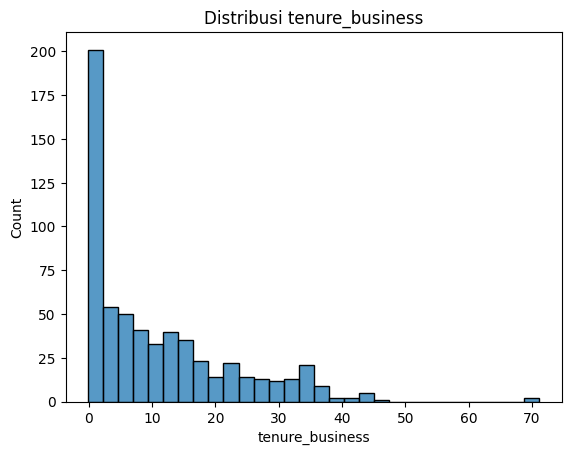

In [222]:
num_col = 'tenure_business'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [223]:
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
tenure_business,,,,
"(-0.051000000000000004, 0.15]",58,0,0.0000,10.5500
"(0.15, 0.882]",52,0,0.0000,9.4500
"(0.882, 2.054]",55,0,0.0000,10.0000
"(2.054, 4.062]",55,0,0.0000,10.0000
"(4.062, 6.88]",56,1,1.7857,10.1800
"(6.88, 10.378]",54,2,3.7037,9.8200
"(10.378, 13.362]",55,0,0.0000,10.0000
"(13.362, 18.076]",55,3,5.4545,10.0000
"(18.076, 24.335]",55,2,3.6364,10.0000


In [224]:
bins = [-float('inf'),3,20,float('inf')]
labels = [1, 2, 3]

df_train['tenure_buss_group'] = pd.cut(df_train['tenure_business'], bins=bins, labels=labels)
df_test['tenure_buss_group'] = pd.cut(df_test['tenure_business'], bins=bins, labels=labels)

tenure_map_dict = {
    1: 'T1 (-inf,3]',
    2: 'T2 (3,20]',
    3: 'T3 (20,inf]'
}

df_train['tenure_buss_group'] = df_train['tenure_buss_group'].astype(int).map(tenure_map_dict)
df_test['tenure_buss_group'] = df_test['tenure_buss_group'].astype(int).map(tenure_map_dict)


In [225]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('tenure_buss_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,tenure_buss_group,total,bad_ratio,portion
0,"T1 (-inf,3]",219,0.0000,36.0800
1,"T2 (3,20]",266,2.6300,43.8200
2,"T3 (20,inf]",122,3.2800,20.1000


## number_of_owner

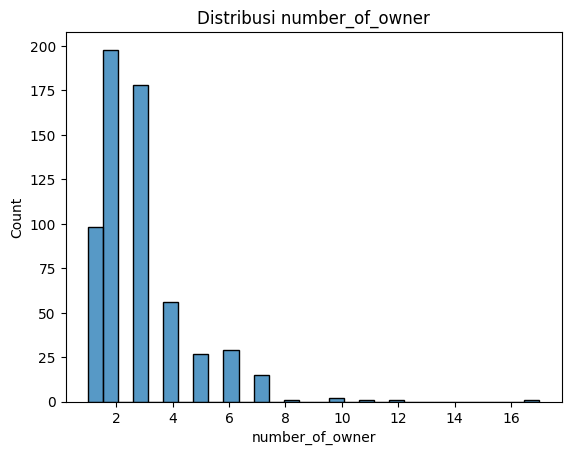

In [226]:
num_col = 'number_of_owner'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [227]:
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
number_of_owner,,,,
"(0.999, 2.0]",296,4,1.3514,50.5100
"(2.0, 3.0]",178,4,2.2472,30.3800
"(3.0, 4.0]",56,1,1.7857,9.5600
"(4.0, 6.0]",56,2,3.5714,9.5600


In [228]:
bins = [-float('inf'),2,float('inf')]
labels = [1, 2]

df_train['numberowner_group'] = pd.cut(df_train['number_of_owner'], bins=bins, labels=labels)
df_test['numberowner_group'] = pd.cut(df_test['number_of_owner'], bins=bins, labels=labels)

tenure_map_dict = {
    1: 'W1 (-inf,2]',
    2: 'W2 (2,inf]'
}

df_train['numberowner_group'] = df_train['numberowner_group'].astype(int).map(tenure_map_dict)
df_test['numberowner_group'] = df_test['numberowner_group'].astype(int).map(tenure_map_dict)


In [229]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('numberowner_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,numberowner_group,total,bad_ratio,portion
0,"W1 (-inf,2]",296,1.3500,48.7600
1,"W2 (2,inf]",311,2.2500,51.2400


## Plafond

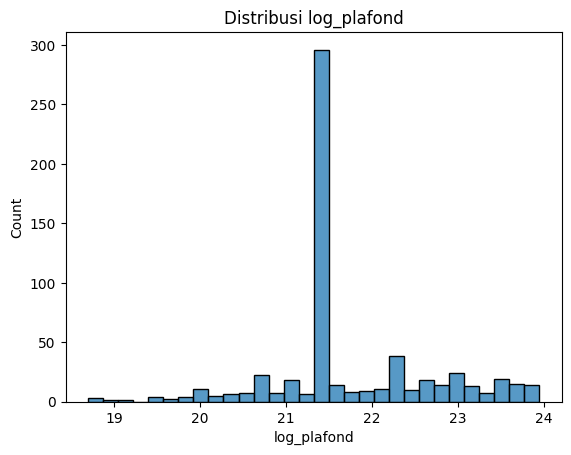

In [230]:
df_train['log_plafond'] = np.log1p(df_train['Plafond'])

df_test['log_plafond'] = np.log1p(df_test['Plafond'])

num_col = 'log_plafond'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [231]:
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafond,,,,
"(20.291, 21.129]",60,3,5.0000,10.9700
"(21.129, 21.416]",301,1,0.3322,55.0300
"(21.416, 21.822]",23,1,4.3478,4.2000
"(21.822, 22.333]",56,3,5.3571,10.2400
"(22.333, 23.026]",68,1,1.4706,12.4300
"(23.026, 23.431]",39,1,2.5641,7.1300


In [232]:
bins = [-float('inf'),21.416,22.333,float('inf')]
labels = [1, 2, 3]

df_train['log_plafond_group'] = pd.cut(df_train['log_plafond'], bins=bins, labels=labels)
df_test['log_plafond_group'] = pd.cut(df_test['log_plafond'], bins=bins, labels=labels)

tenure_map_dict = {
    1: 'P1 (-inf,21.416]',
    2: 'P2 (21.416,23.026]',
    3: 'P3 (23.026,inf]'
}

df_train['log_plafond_group'] = df_train['log_plafond_group'].astype(int).map(tenure_map_dict)
df_test['log_plafond_group'] = df_test['log_plafond_group'].astype(int).map(tenure_map_dict)


In [233]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafond_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafond_group,total,bad_ratio,portion
0,"P1 (-inf,21.416]",98,4.0800,16.1400
1,"P2 (21.416,23.026]",373,1.0700,61.4500
2,"P3 (23.026,inf]",136,2.2100,22.4100


In [234]:
df_train['Plafond'].describe()

count              607.0000
mean     4,414,121,851.0497
std      5,139,667,075.6494
min        132,000,000.0000
25%      2,000,000,000.0000
50%      2,000,000,000.0000
75%      5,000,000,000.0000
max     25,000,000,000.0000
Name: Plafond, dtype: float64

### Plafond Low and High

In [235]:
df_train['log_plafon_low'] = np.log1p(
    np.where(df_train['Plafond'] <= 2_000_000_000, df_train['Plafond'], 2_000_000_000))

df_train['log_plafon_high'] = np.log1p(
    np.where(df_train['Plafond'] > 2_000_000_000, df_train['Plafond'], 2_000_000_000))

df_test['log_plafon_low'] = np.log1p(
    np.where(df_test['Plafond'] <= 2_000_000_000, df_test['Plafond'], 2_000_000_000))

df_test['log_plafon_high'] = np.log1p(
    np.where(df_test['Plafond'] > 2_000_000_000, df_test['Plafond'], 2_000_000_000))

In [236]:
num_col = 'log_plafon_low'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_low,,,,
"(20.291, 21.129]",60,3,5.0000,10.4200
"(21.129, 21.416]",516,8,1.5504,89.5800


In [237]:
bin_1 = pd.cut(df_train['log_plafon_low'], bins=[-float('inf'),21.416,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['log_plafon_low'], bins=[-float('inf'),21.416,float('inf')], labels=[1,2])

# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,21.416]',
    2: 'P2 (21.416,inf]'
}

df_train['log_plafon_low_group'] = bin_1.astype(int).map(tenure_map_dict)

df_test['log_plafon_low_group'] = bin_2.astype(int).map(tenure_map_dict)

In [238]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_low_group,total,bad_ratio,portion
0,"P1 (-inf,21.416]",98,4.0800,16.1400
1,"P2 (21.416,inf]",509,1.3800,83.8600


In [239]:
num_col = 'log_plafon_high'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_high,,,,
"(21.415, 21.64]",406,4,0.9852,70.2400
"(21.64, 22.333]",65,4,6.1538,11.2500
"(22.333, 22.985]",49,0,0.0000,8.4800
"(22.985, 23.431]",58,2,3.4483,10.0300


In [240]:
bin_1 = pd.cut(df_train['log_plafon_high'], bins=[-float('inf'),21.64,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['log_plafon_high'], bins=[-float('inf'),21.64,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,21.64]',
    2: 'P2 (21.64,inf]'
}

df_train['log_plafon_high_group'] = bin_1.astype(int).map(tenure_map_dict)

df_test['log_plafon_high_group'] = bin_2.astype(int).map(tenure_map_dict)

In [241]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_high_group,total,bad_ratio,portion
0,"P1 (-inf,21.64]",406,0.9900,66.8900
1,"P2 (21.64,inf]",201,3.4800,33.1100


In [242]:
df_train.columns

Index(['level_0', 'index', 'IDLimit', 'Segmen', 'LoanType', 'TglMulai',
       'Plafond', 'Golongan Debitur', 'provinsi_domisili', 'peng_id',
       'badan_hukum', 'SektorEkonomi_Kategori', 'tenure_business',
       'range_revenue', 'flag_30_12MoB', 'Segmen_2', 'number_of_owner',
       'sector_group', 'badanhukum_group', 'provinsi_group', 'revenue_group',
       'Golongan_BU', 'Golongan_BU_group', 'tenure_buss_group',
       'numberowner_group', 'log_plafond', 'log_plafond_group',
       'log_plafon_low', 'log_plafon_high', 'log_plafon_low_group',
       'log_plafon_high_group'],
      dtype='object')

In [243]:
df_train = df_train.drop(columns=['level_0', 'index', 'IDLimit', 'Segmen', 
                                  'LoanType', 'TglMulai', 'Plafond', 'log_plafond',
                                  'Golongan Debitur', 'provinsi_domisili', 'peng_id',
                                  'Golongan_BU', 'log_plafon_low', 'log_plafon_high',
                                  'badan_hukum', 'SektorEkonomi_Kategori', 'tenure_business',
                                  'range_revenue', 'Segmen_2', 'number_of_owner', 'log_plafond_group'])

df_test = df_test.drop(columns=['level_0', 'index', 'IDLimit', 'Segmen', 
                                  'LoanType', 'TglMulai', 'Plafond', 'log_plafond',
                                  'Golongan Debitur', 'provinsi_domisili', 'peng_id',
                                  'Golongan_BU', 'log_plafon_low', 'log_plafon_high',
                                  'badan_hukum', 'SektorEkonomi_Kategori', 'tenure_business',
                                  'range_revenue', 'Segmen_2', 'number_of_owner', 'log_plafond_group'])

In [244]:
df_train.head()

,flag_30_12MoB,sector_group,badanhukum_group,provinsi_group,revenue_group,Golongan_BU_group,tenure_buss_group,numberowner_group,log_plafon_low_group,log_plafon_high_group
0,0,S1,B1,P2,R2,G2,"T3 (20,inf]","W2 (2,inf]","P2 (21.416,inf]","P1 (-inf,21.64]"
1,0,S1,B1,P2,R2,G2,"T3 (20,inf]","W2 (2,inf]","P1 (-inf,21.416]","P1 (-inf,21.64]"
2,0,S1,B1,P2,R2,G2,"T3 (20,inf]","W2 (2,inf]","P1 (-inf,21.416]","P1 (-inf,21.64]"
3,0,S1,B1,P2,R2,G2,"T3 (20,inf]","W2 (2,inf]","P1 (-inf,21.416]","P1 (-inf,21.64]"
4,0,S1,B1,P2,R2,G2,"T3 (20,inf]","W2 (2,inf]","P1 (-inf,21.416]","P1 (-inf,21.64]"


In [245]:
df_train.columns

Index(['flag_30_12MoB', 'sector_group', 'badanhukum_group', 'provinsi_group',
       'revenue_group', 'Golongan_BU_group', 'tenure_buss_group',
       'numberowner_group', 'log_plafon_low_group', 'log_plafon_high_group'],
      dtype='object')

## WoE

In [246]:
df_train = df_train.drop(columns = ['provinsi_group'])

In [247]:
categorical_cols = ['sector_group', 'badanhukum_group',
       'revenue_group', 'Golongan_BU_group', 'tenure_buss_group',
       'numberowner_group', 'log_plafon_low_group','log_plafon_high_group']
df_train[categorical_cols] = df_train[categorical_cols].astype('category')

df_test[categorical_cols] = df_test[categorical_cols].astype('category')

In [248]:
# Pisahkan X dan y
X_train = df_train[['sector_group', 'badanhukum_group', 
       'revenue_group', 'Golongan_BU_group', 'tenure_buss_group',
       'numberowner_group', 'log_plafon_low_group', 'log_plafon_high_group']]
y_train = df_train['flag_30_12MoB']

X_test = df_test[['sector_group', 'badanhukum_group', 
       'revenue_group', 'Golongan_BU_group', 'tenure_buss_group',
       'numberowner_group', 'log_plafon_low_group', 'log_plafon_high_group']]
y_test = df_test['flag_30_12MoB']


In [249]:
def hitung_woe_iv(df, target='flag_30_12MoB'):
    """
    Hitung Weight of Evidence (WOE) dan Information Value (IV) untuk setiap bin dari setiap variabel kategorik.
    
    Parameters
    ----------
    df : DataFrame
        Data dengan kolom target dan variabel independen yang sudah di-binning.
    target : str
        Nama kolom target (1 = bad, 0 = good)
    
    Returns
    -------
    woe_df : DataFrame
        Tabel berisi variabel, kategori/bin, jumlah good, jumlah bad, distribusi, WOE, dan kontribusi IV.
    iv_summary : DataFrame
        Ringkasan IV per variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_list = []

    # total good dan bad keseluruhan
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum'])
        temp = temp.rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # distribusi
        temp['bad_dist'] = temp['bad'] / total_bad
        temp['good_dist'] = temp['good'] / total_good

        # WOE dengan perlindungan dari pembagian nol
        epsilon = 1e-6
        temp['woe'] = np.log((temp['good_dist'] + epsilon) / (temp['bad_dist'] + epsilon))

        # Kontribusi IV per bin
        temp['iv_contrib'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        # Simpan IV per variabel
        iv = temp['iv_contrib'].sum()
        iv_list.append({'variabel': col, 'IV': iv})

        # Tambahkan nama variabel dan kategori
        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

    # Gabungkan semua variabel
    woe_df = pd.concat(hasil, ignore_index=True)
    woe_df = woe_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_contrib']]

    # Ringkasan IV per variabel
    iv_summary = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

    return woe_df, iv_summary


In [250]:
# ada tambahan epsilon

def hitung_woe_iv_epsilon(df, target='flag_30_12MoB', epsilon=0.5):
    """
    Hitung WOE dan IV dengan smoothing untuk mengurangi efek target imbalance.
    
    Parameters
    ----------
    df : DataFrame
        Dataset dengan kolom target dan variabel independen (kategori/bin).
    target : str
        Nama kolom target (1=bad, 0=good)
    epsilon : float
        Nilai smoothing untuk mencegah divisi nol
    
    Returns
    -------
    iv_df : DataFrame
        Tabel WOE dan IV untuk tiap bin tiap variabel
    iv_summary : DataFrame
        Ringkasan IV tiap variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_summary = []

    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # smoothing distribusi
        temp['good_dist'] = (temp['good'] + epsilon) / (total_good + epsilon * len(temp))
        temp['bad_dist'] = (temp['bad'] + epsilon) / (total_bad + epsilon * len(temp))

        # WOE
        temp['woe'] = np.log(temp['good_dist'] / temp['bad_dist'])

        # IV per bin
        temp['iv_bin'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

        iv_summary.append({
            'variabel': col,
            'IV': temp['iv_bin'].sum()
        })

    iv_df = pd.concat(hasil, ignore_index=True)
    iv_df = iv_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_bin']]

    iv_summary = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)

    return iv_df, iv_summary

In [251]:
woe_result, iv_summary = hitung_woe_iv(df_train)

# Lihat WOE tiap bin
woe_result

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_contrib
0,sector_group,S1,43,41,2,0.0688,0.1818,-0.9719,0.1099
1,sector_group,S2,66,64,2,0.1074,0.1818,-0.5266,0.0392
2,sector_group,S3,213,207,6,0.3473,0.5455,-0.4514,0.0894
3,sector_group,S4,139,138,1,0.2315,0.0909,0.9349,0.1315
4,sector_group,S5,146,146,0,0.2450,0.0000,12.4089,3.0398
5,badanhukum_group,B1,513,502,11,0.8423,1.0000,-0.1716,0.0271
6,badanhukum_group,B2,94,94,0,0.1577,0.0000,11.9686,1.8877
7,revenue_group,R1,21,21,0,0.0352,0.0000,10.4698,0.3689
8,revenue_group,R2,413,410,3,0.6879,0.2727,0.9252,0.3841
9,revenue_group,R3,173,165,8,0.2768,0.7273,-0.9658,0.4350


In [252]:
# Lihat IV per variabel
iv_summary

,variabel,IV
0,tenure_buss_group,4.8863
1,sector_group,3.4097
2,badanhukum_group,1.9147
3,revenue_group,1.1881
4,Golongan_BU_group,0.7598
5,log_plafon_high_group,0.4005
6,log_plafon_low_group,0.2297
7,numberowner_group,0.0656


In [253]:
woe_result_sm, iv_summary_sm = hitung_woe_iv_epsilon(df_train)

# Lihat WOE tiap bin
woe_result_sm

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_bin
0,sector_group,S1,43,41,2,0.0693,0.1852,-0.9823,0.1138
1,sector_group,S2,66,64,2,0.1078,0.1852,-0.5414,0.0419
2,sector_group,S3,213,207,6,0.3467,0.4815,-0.3284,0.0443
3,sector_group,S4,139,138,1,0.2314,0.1111,0.7337,0.0883
4,sector_group,S5,146,146,0,0.2448,0.0370,1.8884,0.3923
5,badanhukum_group,B1,513,502,11,0.8417,0.9583,-0.1298,0.0151
6,badanhukum_group,B2,94,94,0,0.1583,0.0417,1.3347,0.1557
7,revenue_group,R1,21,21,0,0.0360,0.0400,-0.1058,0.0004
8,revenue_group,R2,413,410,3,0.6870,0.2800,0.8976,0.3653
9,revenue_group,R3,173,165,8,0.2770,0.6800,-0.8981,0.3620


In [254]:
iv_summary_sm

,variabel,IV
0,Golongan_BU_group,0.8840
1,tenure_buss_group,0.8759
2,revenue_group,0.7277
3,sector_group,0.6805
4,log_plafon_high_group,0.3704
5,log_plafon_low_group,0.2514
6,badanhukum_group,0.1708
7,numberowner_group,0.0541


In [255]:
#woe_result_sm.to_csv('D:/Development/Hasil/Company SME/woe_company_sme.csv')

In [256]:
X_woe = X_train.copy()  # buat salinan agar aman

for col in X_train.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe[col] = X_train[col].map(woe_map)

X_woe_test = X_test.copy()

for col in X_test.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe_test[col] = X_test[col].map(woe_map)

In [257]:
#X_woe = X_woe.drop(columns=['provinsi_group'])
#X_woe_test = X_woe_test.drop(columns=['provinsi_group'])

In [258]:
X_woe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   sector_group           607 non-null    category
 1   badanhukum_group       607 non-null    category
 2   revenue_group          607 non-null    category
 3   Golongan_BU_group      607 non-null    category
 4   tenure_buss_group      607 non-null    category
 5   numberowner_group      607 non-null    category
 6   log_plafon_low_group   607 non-null    category
 7   log_plafon_high_group  607 non-null    category
dtypes: category(8)
memory usage: 5.9 KB


## Multikolinearitas (VIF) 

In [259]:
def hitung_vif(df_woe):
    """
    Menghitung Variance Inflation Factor (VIF) untuk dataset WOE.
    
    Parameters
    ----------
    df_woe : DataFrame
        DataFrame berisi variabel independen yang sudah diubah menjadi WOE.
    
    Returns
    -------
    DataFrame
        Tabel VIF untuk setiap variabel.
    """
    
    # tambah konstanta agar kompatibel
    X = df_woe.copy()
    #X = X.assign(const=1)

    vif_data = []
    
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append((X.columns[i], vif))
    
    vif_df = pd.DataFrame(vif_data, columns=['variabel', 'VIF'])

    return vif_df

In [260]:
vif_result = hitung_vif(X_woe)
vif_result

,variabel,VIF
0,sector_group,1.3971
1,badanhukum_group,1.3897
2,revenue_group,1.9771
3,Golongan_BU_group,1.3043
4,tenure_buss_group,1.7889
5,numberowner_group,1.2785
6,log_plafon_low_group,1.2695
7,log_plafon_high_group,2.2581


## SMOTE

In [261]:
# --- 1. Encode semua kolom kategorik ---
le_dict = {}

X_woe = X_woe.copy()
for col in X_woe.columns:
    le = LabelEncoder()
    X_woe[col] = le.fit_transform(X_woe[col])
    le_dict[col] = le  # disimpan jika nanti mau decode kembali

# --- 2. Terapkan SMOTE + Tomek Links ---
#smt = SMOTETomek(sampling_strategy=0.3, random_state=42)
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_woe, y_train)

# --- 3. Lihat hasil ---
print("Sebelum SMOTE:")
print(y_train.value_counts())
print("\nSesudah SMOTE:")
print(pd.Series(y_res).value_counts())

# --- 4. (Opsional) Decode kembali ke teks kategori ---
for col in X_woe.columns:
    X_res[col] = le_dict[col].inverse_transform(X_res[col])

X_res = pd.DataFrame(X_res, columns=X_woe.columns)

Sebelum SMOTE:
flag_30_12MoB
0    596
1     11
Name: count, dtype: int64

Sesudah SMOTE:
flag_30_12MoB
0    596
1    596
Name: count, dtype: int64


## Training model

In [262]:
X_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sector_group           1192 non-null   float64
 1   badanhukum_group       1192 non-null   float64
 2   revenue_group          1192 non-null   float64
 3   Golongan_BU_group      1192 non-null   float64
 4   tenure_buss_group      1192 non-null   float64
 5   numberowner_group      1192 non-null   float64
 6   log_plafon_low_group   1192 non-null   float64
 7   log_plafon_high_group  1192 non-null   float64
dtypes: float64(8)
memory usage: 74.6 KB


In [263]:
# Gabungkan X dan y untuk analisis korelasi
df_corr = X_res.copy()
df_corr['target'] = y_res

# Hitung korelasi Pearson
corr_with_target = df_corr.corr()['target'].sort_values(ascending=False)

# Tampilkan hasilnya
print("Korelasi variabel independen terhadap target:")
print(corr_with_target)

# Jika ingin tanpa target itu sendiri
#corr_with_target = corr_with_target.drop('target')

Korelasi variabel independen terhadap target:
target                   1.0000
numberowner_group       -0.2842
badanhukum_group        -0.2926
Golongan_BU_group       -0.3874
log_plafon_low_group    -0.3951
tenure_buss_group       -0.4961
sector_group            -0.5221
revenue_group           -0.5851
log_plafon_high_group   -0.5968
Name: target, dtype: float64


### Scikit learn

#### dengan smote

In [264]:
X_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sector_group           1192 non-null   float64
 1   badanhukum_group       1192 non-null   float64
 2   revenue_group          1192 non-null   float64
 3   Golongan_BU_group      1192 non-null   float64
 4   tenure_buss_group      1192 non-null   float64
 5   numberowner_group      1192 non-null   float64
 6   log_plafon_low_group   1192 non-null   float64
 7   log_plafon_high_group  1192 non-null   float64
dtypes: float64(8)
memory usage: 74.6 KB


In [265]:
X_res.head()

,sector_group,badanhukum_group,revenue_group,Golongan_BU_group,tenure_buss_group,numberowner_group,log_plafon_low_group,log_plafon_high_group
0,-0.9823,-0.1298,0.8976,0.4540,-0.5962,-0.2032,0.2977,0.5866
1,-0.9823,-0.1298,0.8976,0.4540,-0.5962,-0.2032,-0.8625,0.5866
2,-0.9823,-0.1298,0.8976,0.4540,-0.5962,-0.2032,-0.8625,0.5866
3,-0.9823,-0.1298,0.8976,0.4540,-0.5962,-0.2032,-0.8625,0.5866
4,-0.9823,-0.1298,0.8976,0.4540,-0.5962,-0.2032,-0.8625,0.5866


In [266]:
y_res.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1192 entries, 0 to 1191
Series name: flag_30_12MoB
Non-Null Count  Dtype
--------------  -----
1192 non-null   int64
dtypes: int64(1)
memory usage: 9.4 KB


In [267]:
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_res, y_res)
# coef = model.coef_[0]      # koefisien tiap variabel
# intercept = model.intercept_[0]   # konstanta (intercept)

# coef_df = pd.DataFrame({
#     'Variable': X_res.columns,
#     'Coefficient': coef
# })
# coef_df.loc[len(coef_df)] = ['Intercept', intercept]
# coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# coef_df

In [268]:
cols = X_woe_test.columns
X_woe_test[cols] = X_woe_test[cols].astype('float64')

In [269]:
X_woe_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sector_group           238 non-null    float64
 1   badanhukum_group       238 non-null    float64
 2   revenue_group          238 non-null    float64
 3   Golongan_BU_group      238 non-null    float64
 4   tenure_buss_group      238 non-null    float64
 5   numberowner_group      238 non-null    float64
 6   log_plafon_low_group   238 non-null    float64
 7   log_plafon_high_group  238 non-null    float64
dtypes: float64(8)
memory usage: 15.0 KB


In [270]:
# y_prob_train = model.predict_proba(X_res)[:,1]
# y_prob_test = model.predict_proba(X_woe_test)[:,1]

In [271]:
# df_train_slearn = pd.DataFrame({ 'proba': y_prob_train, 'y_res': y_res })
# df_test_slearn = pd.DataFrame({ 'proba': y_prob_test, 'y_res': y_test })

In [272]:
#df_train_slearn.to_excel('D:/Development/Hasil/proba company train sm v2.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/proba company test sm v2.xlsx')

In [273]:
# num_col = 'proba'
# #low = df_train_slearn[num_col].quantile(0.05)
# #high = df_train_slearn[num_col].quantile(0.95)
# #df_train_no_outlier = df_train_slearn[(df_train_slearn[num_col] >= low) & (df_train_slearn[num_col] <= high)]

# bins = pd.qcut(df_train_slearn[num_col], q=10, duplicates='drop')
# bad_ratio = (
#     df_train_slearn.groupby(bins, observed=False)['y_res']
#     .agg(['count', 'sum'])
#     .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
# )
# bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
# bad_ratio

### sklearn dengan p value

In [274]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
import inspect

def logistic_regression_with_pvalues(X, y):
    """
    Fit logistic regression (scikit-learn) tanpa penalti,
    lalu hitung standard error, z-score, dan p-value via MLE.

    Return:
        result -> tabel koefisien + SE + z + p-value
        model  -> sklearn LogisticRegression yang sudah fit
    """

    # --- Cek apakah sklearn versi baru mendukung penalty='none' ---
    try:
        model = LogisticRegression(penalty='none', solver='lbfgs', max_iter=5000)
        model.fit(X, y)
    except:
        # fallback untuk versi sklearn lama
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
        model.fit(X, y)

    # --- Prediksi probabilitas ---
    p = model.predict_proba(X)[:, 1]

    # --- Design matrix (tambah intercept) ---
    X_design = np.hstack([np.ones((X.shape[0], 1)), X])

    # --- Weight matrix W = diag(p*(1-p)) ---
    W = np.diag(p * (1 - p))

    # --- Fisher Information matrix ---
    info_mat = X_design.T @ W @ X_design

    # --- Variance-covariance matrix ---
    cov_mat = np.linalg.inv(info_mat)

    # --- Standard error ---
    se = np.sqrt(np.diag(cov_mat))

    # --- Ambil parameter (intercept + coef) ---
    params = np.hstack([model.intercept_, model.coef_.flatten()])

    # --- Hitung z-score & p-value ---
    z = params / se
    p_values = 2 * (1 - norm.cdf(np.abs(z)))

    # --- Pseudo R-Square (McFadden) ---
    eps = 1e-10
    # log-likelihood model penuh
    ll_full = np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    # log-likelihood model null (intercept saja)
    p_null = np.mean(y)
    ll_null = np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))

    r_square = 1 - (ll_full / ll_null)    
    
    # --- Susun dataframe hasil ---
    names = ["Intercept"] + list(X.columns)
    result = pd.DataFrame({
        "Coefficient": params,
        "Std Error": se,
        "z-score": z,
        "p-value": p_values
    }, index=names)

    return result, model, r_square


In [275]:
result, model, r_square = logistic_regression_with_pvalues(X_res, y_res)

In [276]:
r_square

np.float64(0.6748456451572507)

In [277]:
print(result)

                       Coefficient  Std Error  z-score  p-value
Intercept                  -6.2254     5.1917  -1.1991   0.2305
sector_group               -2.5113     0.3610  -6.9563   0.0000
badanhukum_group           -4.7640    12.5557  -0.3794   0.7044
revenue_group              -1.3315     0.1761  -7.5596   0.0000
Golongan_BU_group          -0.0863     0.1307  -0.6600   0.5092
tenure_buss_group          -2.8061     0.8106  -3.4619   0.0005
numberowner_group          -1.7123     0.6083  -2.8147   0.0049
log_plafon_low_group       -9.5950    15.6963  -0.6113   0.5410
log_plafon_high_group      -9.1016    14.7089  -0.6188   0.5361


In [278]:
X_res_2 = X_res.drop(columns=['badanhukum_group','Golongan_BU_group','log_plafon_low_group',
                              'numberowner_group'])
X_woe_test_2 = X_woe_test.drop(columns=['badanhukum_group','Golongan_BU_group', 'log_plafon_low_group',
                              'numberowner_group'])

result_2, model_2, r_square_2 = logistic_regression_with_pvalues(X_res_2, y_res)
print(result_2)

                       Coefficient  Std Error  z-score  p-value
Intercept                  -2.6613     0.3062  -8.6899   0.0000
sector_group               -3.5445     0.3378 -10.4923   0.0000
revenue_group              -1.4290     0.1452  -9.8447   0.0000
tenure_buss_group          -1.9769     0.4389  -4.5045   0.0000
log_plafon_high_group      -1.4477     0.2011  -7.1974   0.0000


In [279]:
r_square_2

np.float64(0.5629196937506618)

In [280]:
import joblib

#joblib.dump(model_2, "model awal company sme.pkl")

In [281]:
# --- Probabilitas Training & Testing ---
y_prob_train = model.predict_proba(X_res)[:, 1]
y_prob_test  = model.predict_proba(X_woe_test)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn = pd.DataFrame({
    'proba': y_prob_train,
    'y_res': y_res
})

df_test_slearn = pd.DataFrame({
    'proba': y_prob_test,
    'y_res': y_test
})


In [282]:
def make_decile_table(df, prob_col='proba', target_col='y_res', q=10):
    """
    Menghitung count, bad, bad_ratio (%), dan portion (%) berdasarkan quantile.
    prob_col  : kolom probabilitas
    target_col: kolom target (1 = bad)
    q         : jumlah bins (default 10 = decile)
    """

    bins = pd.qcut(df[prob_col], q=q, duplicates='drop')

    result = (
        df.groupby(bins, observed=False)[target_col]
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'bad'})
        .assign(
            bad_ratio=lambda x: (x['bad'] / x['count']) * 100,
            portion=lambda x: (x['count'] / x['count'].sum()) * 100
        )
        .round({'bad_ratio': 2, 'portion': 2})
    )

    return result


In [283]:
train_decile = make_decile_table(df_train_slearn, prob_col='proba', target_col='y_res', q=10)
train_decile

,count,bad,bad_ratio,portion
proba,,,,
"(-9.9999999969892e-06, 8.4431e-10]",144,0,0.0000,12.0800
"(8.4431e-10, 9.1643e-09]",95,0,0.0000,7.9700
"(9.1643e-09, 0.00030313]",119,0,0.0000,9.9800
"(0.00030313, 0.23171]",121,1,0.8300,10.1500
"(0.23171, 0.62853]",121,78,64.4600,10.1500
"(0.62853, 0.80482]",120,79,65.8300,10.0700
"(0.80482, 0.8129]",114,98,85.9600,9.5600
"(0.8129, 0.99998]",191,173,90.5800,16.0200
"(0.99998, 0.99999]",63,63,100.0000,5.2900


In [284]:
# --- Probabilitas Training & Testing ---
y_prob_train_2 = model_2.predict_proba(X_res_2)[:, 1]
y_prob_test_2  = model_2.predict_proba(X_woe_test_2)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn_2 = pd.DataFrame({
    'proba': y_prob_train_2,
    'y_res': y_res
})

df_test_slearn_2 = pd.DataFrame({
    'proba': y_prob_test_2,
    'y_res': y_test
})


In [285]:
#df_train_slearn_2.to_excel('D:/Development/Hasil/proba company train sm pvalue.xlsx')
#df_test_slearn_2.to_excel('D:/Development/Hasil/proba company test sm pvalue.xlsx')

In [286]:
train_decile_2 = make_decile_table(df_train_slearn_2, prob_col='proba', target_col='y_res', q=10)
train_decile_2

,count,bad,bad_ratio,portion
proba,,,,
"(-0.000999872, 1.94e-05]",150,0,0.0000,12.5800
"(1.94e-05, 0.000704]",120,0,0.0000,10.0700
"(0.000704, 0.0479]",117,1,0.8500,9.8200
"(0.0479, 0.341]",91,2,2.2000,7.6300
"(0.341, 0.754]",134,101,75.3700,11.2400
"(0.754, 0.797]",246,210,85.3700,20.6400
"(0.797, 0.871]",184,151,82.0700,15.4400
"(0.871, 0.935]",89,80,89.8900,7.4700
"(0.935, 0.986]",61,51,83.6100,5.1200


### Statsmodel

In [94]:
# # 1. Cek apakah ada kolom konstan
# print((X_res.nunique() == 1).sum(), "variabel punya 1 nilai unik")

# # 2. Cek kolinearitas ekstrem
# corr = X_res.corr().abs()
# high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
# print(high_corr[high_corr > 0.95])  # tampilkan yang sangat berkorelasi

In [95]:
# corr

In [96]:
# X = X_res.copy()
# y = y_res.copy()

# X = sm.add_constant(X)  # penting agar ada intercept β0

# logit_model = sm.Logit(y, X)
# result = logit_model.fit()

# print(result.summary())

In [97]:
# def stepwise_selection(X, y, threshold_out=0.05):
#     X = sm.add_constant(X)
#     model = sm.Logit(y, X).fit(disp=0)
    
#     while True:
#         pvalues = model.pvalues.iloc[1:]  # skip intercept
#         worst_pval = pvalues.max()
#         if worst_pval > threshold_out:
#             worst_feature = pvalues.idxmax()
#             X = X.drop(columns=[worst_feature])
#             model = sm.Logit(y, X).fit(disp=0)
#         else:
#             break
#     return model

# model_final = stepwise_selection(X, y)
# print(model_final.summary())

In [98]:
# def stepwise_selection(X, y, 
#                        initial_list=[], 
#                        threshold_in=0.05, 
#                        threshold_out=0.10, 
#                        verbose=True):
#     included = list(initial_list)
#     while True:
#         changed=False
#         excluded = list(set(X.columns) - set(included))
#         new_pval = pd.Series(index=excluded, dtype=float)
        
#         for new_column in excluded:
#             try:
#                 model = sm.Logit(y, sm.add_constant(X[included + [new_column]])).fit(disp=0)
#                 new_pval[new_column] = model.pvalues[new_column]
#             except np.linalg.LinAlgError:
#                 new_pval[new_column] = np.nan
        
#         best_pval = new_pval.min()
#         if best_pval is not np.nan and best_pval < threshold_in:
#             best_feature = new_pval.idxmin()
#             included.append(best_feature)
#             changed=True
#             if verbose:
#                 print(f'Add  {best_feature:25} with p-value {best_pval:.6f}')

#         # backward step
#         try:
#             model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
#             pvalues = model.pvalues.iloc[1:]
#             worst_pval = pvalues.max()
#             if worst_pval > threshold_out:
#                 worst_feature = pvalues.idxmax()
#                 included.remove(worst_feature)
#                 changed=True
#                 if verbose:
#                     print(f'Remove {worst_feature:25} with p-value {worst_pval:.6f}')
#         except np.linalg.LinAlgError:
#             break

#         if not changed:
#             break

#     final_model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
#     return final_model, included

# model_final, selected_vars = stepwise_selection(X, y)

In [99]:
# print("Final Selected Variables:")
# print(selected_vars)

# print("\nModel Summary:")
# print(model_final.summary())

## Training model v2 (lebih lengkap inferensinya)

In [100]:
# from scipy.stats import norm
# from sklearn.linear_model import LogisticRegression

# def logistic_regression_mle_full(
#     X,
#     y,
#     robust=True,
#     cluster=None,
#     use_pinv=True,
#     max_iter=5000
# ):
#     """
#     Logistic Regression (scikit-learn) tanpa penalti + inferensi statistik lengkap.

#     Fitur:
#     - Pure MLE (penalty=None)
#     - Standard Error: non-robust atau robust (sandwich)
#     - Opsional cluster-robust SE
#     - Aman terhadap singularity (pinv)
#     - McFadden R²
#     - Governance-ready output

#     Parameters
#     ----------
#     X : DataFrame (n_obs, n_features)
#     y : array-like (n_obs, ) binary {0,1}
#     robust : bool
#         Jika True → gunakan robust (sandwich) SE
#     cluster : array-like atau None
#         Cluster id untuk cluster-robust SE (misal AppNo)
#     use_pinv : bool
#         Gunakan pseudo-inverse (recommended)
#     max_iter : int

#     Returns
#     -------
#     result_df : DataFrame
#     model     : fitted sklearn LogisticRegression
#     diagnostics : dict
#     """

#     # ============================
#     # 1. Fit Logistic Regression (MLE)
#     # ============================
#     try:
#         model = LogisticRegression(
#             penalty='none', solver='lbfgs', max_iter=max_iter
#         )
#     except:
#         model = LogisticRegression(
#             penalty=None, solver='lbfgs', max_iter=max_iter
#         )

#     model.fit(X, y)

#     # ============================
#     # 2. Design Matrix
#     # ============================
#     n = X.shape[0]
#     X_design = np.hstack([np.ones((n, 1)), X.values])
#     feature_names = ['Intercept'] + list(X.columns)

#     # ============================
#     # 3. Predicted Probabilities
#     # ============================
#     p = model.predict_proba(X)[:, 1]
#     W = p * (1 - p)

#     # ============================
#     # 4. Fisher Information (Bread)
#     # ============================
#     info_mat = X_design.T @ (X_design * W[:, None])

#     inv = np.linalg.pinv if use_pinv else np.linalg.inv
#     bread = inv(info_mat)

#     # ============================
#     # 5. Variance-Covariance Matrix
#     # ============================
#     if robust:
#         # Score (gradient per observation)
#         score = X_design * (y - p)[:, None]

#         if cluster is None:
#             meat = score.T @ score
#         else:
#             cluster = np.asarray(cluster)
#             unique_clusters = np.unique(cluster)
#             meat = np.zeros((X_design.shape[1], X_design.shape[1]))

#             for g in unique_clusters:
#                 s_g = score[cluster == g].sum(axis=0)
#                 meat += np.outer(s_g, s_g)

#         cov_mat = bread @ meat @ bread
#     else:
#         cov_mat = bread

#     # ============================
#     # 6. Inference Statistics
#     # ============================
#     se = np.sqrt(np.diag(cov_mat))
#     params = np.hstack([model.intercept_, model.coef_.flatten()])
#     z = params / se
#     p_values = 2 * (1 - norm.cdf(np.abs(z)))

#     result_df = pd.DataFrame({
#         'Coefficient': params,
#         'Std Error': se,
#         'z-value': z,
#         'p-value': p_values
#     }, index=feature_names)

#     # ============================
#     # 7. McFadden R²
#     # ============================
#     eps = 1e-12
#     ll_full = np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
#     p_null = np.mean(y)
#     ll_null = np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))
#     r2_mcfadden = 1 - (ll_full / ll_null)

#     # ============================
#     # 8. Diagnostics
#     # ============================
#     diagnostics = {
#         'converged': model.n_iter_[0] < max_iter,
#         'n_iter': int(model.n_iter_[0]),
#         'pseudo_r2_mcfadden': r2_mcfadden,
#         'robust_se': robust,
#         'clustered': cluster is not None
#     }

#     return result_df, model, diagnostics


In [101]:
# contoh pakai

# #1.standar robust SE (tanpa cluster)
# res, model, diag = logistic_regression_mle_full(X, y)

# #2.cluster robust SE
# res, model, diag = logistic_regression_mle_full(
#     X, y,
#     robust=True,
#     cluster=df['AppNo']
# )

# #3.non robust (identik statsmodel default)
# res, model, diag = logistic_regression_mle_full(
#     X, y,
#     robust=False
# )

In [102]:
# contoh penjelasan ke regulator:

# Model diestimasi menggunakan Maximum Likelihood Estimation (MLE) tanpa regularisasi. 
# Inferensi parameter dilakukan menggunakan asymptotic theory dengan variance–covariance 
# matrix berbasis Fisher Information. Untuk meningkatkan robustness terhadap heteroskedastisitas 
# dan korelasi intra-debitur, digunakan sandwich (robust / cluster-robust) standard errors. 
# Pendekatan ini setara dengan inferensi pada generalized linear models (Logit) dan konsisten 
# dengan praktik statistik standar

## Model tuning (menggunakan platt scaling di scikit learn)

In [103]:
# calibrated_model = CalibratedClassifierCV(estimator=model_2, method='sigmoid', cv='prefit')
# calibrated_model.fit(X=X_woe_test_2, y=y_test)

# y_calibrated = calibrated_model.predict_proba(X_woe_test_2)[:, 1]

In [104]:
# X_woe_test_2.head()

In [105]:
# df_test_cal = pd.DataFrame({ 'proba': y_calibrated, 'y_res': y_test })
# #df_test_cal.to_excel('D:/Development/Hasil/proba company test sm cal v2.xlsx')

In [106]:
# cal = calibrated_model.calibrated_classifiers_[0].calibrators[0]
# print("Slope (A):", cal.a_)
# print("Intercept (B):", cal.b_)

In [107]:
# prob_true, prob_pred = calibration_curve(y_test, y_prob_test_2, n_bins=10)
# prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)

# plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
# plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='After calibration')
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.legend()
# plt.xlabel('Predicted PD')
# plt.ylabel('Actual default rate')
# plt.show()

In [108]:
# brier_before = brier_score_loss(y_test, y_prob_test_2)
# brier_after = brier_score_loss(y_test, y_calibrated)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model Tuning (regresi logistik lagi)

In [109]:
# logit_test_2 = np.log(y_prob_test_2/(1-y_prob_test_2))
# logit_test_2 = pd.DataFrame(logit_test_2)

# result_tun, model_tun, r_square_tun = logistic_regression_with_pvalues(logit_test_2, y_test)

In [110]:
# result_tun

In [111]:
# import joblib

# joblib.dump(model_tun, "model akhir company sme.pkl")

In [112]:
# y_prob_test_tun  = model_tun.predict_proba(logit_test_2)[:, 1]

# # --- Buat dataframe evaluasi ---

# df_test_slearn_tun = pd.DataFrame({
#     'proba': y_prob_test_tun,
#     'y_res': y_test
# })


In [113]:
#df_test_slearn_tun.to_excel('D:/Development/Hasil/proba company test sm cal pvalue.xlsx')

In [114]:
# test_decile_tun = make_decile_table(df_test_slearn_tun, prob_col='proba', target_col='y_res', q=10)
# test_decile_tun

In [115]:
# brier_before = brier_score_loss(y_test, y_prob_test_2)
# brier_after = brier_score_loss(y_test, y_prob_test_tun)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model tuning (hanya intercept)

In [287]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

logit_old = np.log(y_prob_test_2/(1-y_prob_test_2))
logit_old = pd.DataFrame(logit_old)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def intercept_loss(alpha, logit_old, y_true):
    """
    Loss function untuk tuning intercept saja
    """
    logit_new = logit_old + alpha
    y_pred = sigmoid(logit_new)
    return log_loss(y_true, y_pred)

# initial value alpha = 0 (tidak ada adjustment)
result = minimize(
    intercept_loss,
    x0=0.0,
    args=(logit_old, y_test),
    method="BFGS"
)

alpha_opt = result.x[0]
print("Optimal intercept adjustment:", alpha_opt)

# logit & PD setelah tuning intercept
logit_calibrated = logit_old + alpha_opt
pd_calibrated = sigmoid(logit_calibrated)

df_calibration = pd.DataFrame({
    # "pd_before_calibration": y_prob_test_2,
    "pd_calibrated": pd_calibrated.to_numpy().ravel(),
    "y_actual": y_test
})

from sklearn.metrics import roc_auc_score

print("AUC sebelum tuning :", roc_auc_score(y_test, sigmoid(logit_old)))
print("AUC sesudah tuning :", roc_auc_score(y_test, pd_calibrated))

print("LogLoss sebelum tuning :", log_loss(y_test, sigmoid(logit_old)))
print("LogLoss sesudah tuning :", log_loss(y_test, pd_calibrated))


Optimal intercept adjustment: -4.391348715329344
AUC sebelum tuning : 0.8781115879828326
AUC sesudah tuning : 0.8781115879828326
LogLoss sebelum tuning : 0.41788802386007623
LogLoss sesudah tuning : 0.08836410306159993


In [ ]:
#df_calibration.to_excel('D:/Development/Hasil/proba company test sm cal pvalue (intercept).xlsx')

## Persamaan akhir (pakai plat scaling)

In [112]:
# result_2_reset = result_2.reset_index()

In [113]:
# # intercept dan slope Platt
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# platt_slope = cal.a_
# platt_intercept = cal.b_

# # hitung intercept & slope akhir
# intercept_final = platt_slope * intercept_raw + platt_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * platt_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (pakai regresi logistik lagi)

In [ ]:
# result_2_reset = result_2.reset_index()

In [138]:
# # intercept dan slope calibration
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# cal_slope = result_tun['Coefficient'][0]
# cal_intercept = result_tun['Coefficient']['Intercept']

# # hitung intercept & slope akhir
# intercept_final = cal_slope * intercept_raw + cal_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * cal_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (tuning hanya intercept)

In [288]:
model_2.intercept_

array([-2.661263])

In [289]:
import copy

model_calibrated = copy.deepcopy(model_2)
model_calibrated.intercept_ = model_2.intercept_ + alpha_opt
model_calibrated.intercept_

array([-7.05261172])

In [ ]:
# import joblib

# joblib.dump(model_calibrated, "model akhir company sme (intercept tuning).pkl")

['model akhir company sme (intercept tuning).pkl']

In [290]:
result_calibrated = pd.DataFrame({
        "Coefficient": np.hstack([model_calibrated.intercept_, model_calibrated.coef_.flatten()])    
}, index=["Intercept"] + list(X_res_2.columns))
result_calibrated

,Coefficient
Intercept,-7.0526
sector_group,-3.5445
revenue_group,-1.4290
tenure_buss_group,-1.9769
log_plafon_high_group,-1.4477


# 2. Individual SME

In [141]:
df = pd.read_csv('D:/Development/Data Source/dataset/dataset individual sme.csv')
df = df.drop(columns=['Unnamed: 0', 'index'])

In [142]:
df.head()

,IDLimit,CIF,NamaDebitur,Segmen,LoanType,TglMulai,TglJatuhTempo,Plafond,Gender,source_income,OccupationName,Segmen Pekerjaan,Debtor Marriage Status,Educational Status,Golongan Debitur,provinsi_domisili,City,SektorEkonomi_Kategori,age,range_revenue,flag_30_12MoB,flag_30_6MoB,flag_30_2MoB,Segmen_2
0,10038.0008110.01,10038,ROMAN SOENTADJAJA,INVESTASI,PAB01,2023-12-29,2024-12-29,"300,000,000.0000",MALE,GAJI,PEGAWAI SWASTA,MANUFAKTUR,MENIKAH,DIPLOMA III (D3)/AKADEMI,PERSEORANGAN,Jawa Barat,KOTA BEKASI,Industri Pengolahan,62.5000,> 50 JUTA s/d 100 JUTA,0,0,0,SME
1,10100143.0008020.01,10100143,SUSIANIK,MODAL KERJA,PRK,2024-07-05,2025-06-07,"100,000,000.0000",FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Pengangkutan dan Pergudangan,65.0600,s/d 50 JUTA,0,0,0,SME
2,10101685.0008010.01,10101685,TEDDI PRATAMA,MODAL KERJA,PB001,2023-11-22,2024-11-25,"1,000,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,MANUFAKTUR,MENIKAH,UNIVERSITAS / S-1,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Industri Pengolahan,60.1600,> 100 JUTA s/d 200 JUTA,1,0,0,SME
3,10400071.0008020.01,10400071,LAI KOK LIANG,MODAL KERJA,PRK,2024-08-14,2025-08-30,"500,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Tidak Terdefinisi,62.9200,s/d 50 JUTA,0,0,0,SME
4,10400897.0008020.01,10400897,HENDRIK,MODAL KERJA,PRK,2022-08-29,2023-07-03,"5,000,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PROPERTI DAN KONSTRUKSI,MENIKAH,UNIVERSITAS / S-1,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA SELATAN,Perdagangan Besar dan Eceran,73.3000,> 200 JUTA,0,0,0,SME


In [143]:
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('Tidak Terdefinisi', '')

In [144]:
df[df['SektorEkonomi_Kategori'] == '']['Segmen Pekerjaan'].unique()

array(['PERDAGANGAN ECERAN', 'PERDAGANGAN BESAR', 'FASHION',
       'TRANSPORTASI', 'PERHIASAN DAN LOGAM MULIA', 'MANUFAKTUR'],
      dtype=object)

In [145]:
# Definisikan mapping dictionary
SektorEkonomi_Kategori_map = {
    'PERDAGANGAN ECERAN': 'Perdagangan Besar dan Eceran',
    'PERDAGANGAN BESAR': 'Perdagangan Besar dan Eceran',
    'FASHION': 'Industri Pengolahan',
    'TRANSPORTASI': 'Pengangkutan dan Pergudangan',
    'PERHIASAN DAN LOGAM MULIA': 'Perdagangan Besar dan Eceran',
    'MANUFAKTUR': 'Industri Pengolahan'
}

df['SektorEkonomi_Kategori'] = df.apply(
    lambda x: SektorEkonomi_Kategori_map.get(x['Segmen Pekerjaan'], x['SektorEkonomi_Kategori'])
    if pd.isna(x['SektorEkonomi_Kategori']) or x['SektorEkonomi_Kategori'] == ''
    else x['SektorEkonomi_Kategori'],
    axis=1
)
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('', 'Lainnya')

In [146]:
df['SektorEkonomi_Kategori'].unique()

array(['Industri Pengolahan', 'Pengangkutan dan Pergudangan',
       'Perdagangan Besar dan Eceran',
       'Akomodasi dan Penyediaan Makan Minum',
       'Pengelolaan Air, Air Limbah, Daur Ulang',
       'Kesenian, Hiburan, dan Rekreasi',
       'Aktivitas Profesional, Ilmiah, dan Teknis', 'Rumah Tangga',
       'Penyewaan dan Sewa Guna Usaha', 'Pertambangan dan Penggalian',
       'Pertanian, Kehutanan, dan Perikanan', 'Informasi dan Komunikasi',
       'Keuangan dan Asuransi', 'LAINNYA'], dtype=object)

In [147]:
df['Debtor Marriage Status'].unique()

array(['MENIKAH', 'DUDA', 'CERAIHIDUP', 'SINGLE', 'JANDA', 'CERAIMATI'],
      dtype=object)

In [148]:
pd.DataFrame({'value': df.isnull().sum(), 'percentage': df.isna().mean() * 100})

,value,percentage
IDLimit,0,0.0000
CIF,0,0.0000
NamaDebitur,0,0.0000
Segmen,0,0.0000
LoanType,0,0.0000
TglMulai,0,0.0000
TglJatuhTempo,1,0.0700
Plafond,0,0.0000
Gender,0,0.0000
source_income,0,0.0000


In [149]:
df['Educational Status'].unique()

array(['DIPLOMA III (D3)/AKADEMI', 'SMA / SLTA', 'UNIVERSITAS / S-1',
       'SEKOLAH DASAR (SD)', 'SMP / SLTP', 'UNIVERSITAS / S-2',
       'UNIVERSITAS / S-3', 'LAINNYA', nan], dtype=object)

In [150]:
df['Educational Status'] = df['Educational Status'].fillna('LAINNYA')
df[df['Educational Status'].isna()]

,IDLimit,CIF,NamaDebitur,Segmen,LoanType,TglMulai,TglJatuhTempo,Plafond,Gender,source_income,OccupationName,Segmen Pekerjaan,Debtor Marriage Status,Educational Status,Golongan Debitur,provinsi_domisili,City,SektorEkonomi_Kategori,age,range_revenue,flag_30_12MoB,flag_30_6MoB,flag_30_2MoB,Segmen_2


In [151]:
df['provinsi_domisili'].unique()

array(['Jawa Barat', 'DKI Jakarta', 'Banten', 'Lampung', 'Jawa Timur',
       'Bali', 'Bengkulu', 'Jawa Tengah', 'Sumatera Utara',
       'Kalimantan Barat', 'Gorontalo', 'Sumatera Selatan',
       'Sulawesi Tenggara', 'Nusa Tenggara Timur', 'Riau',
       'Sulawesi Utara', 'Kepulauan Bangka Belitung', 'Sulawesi Selatan',
       'D.I. Jogjakarta', 'Jambi', 'Sumatera Barat',
       'Nusa Tenggara Barat', 'KALIMANTAN UTARA', 'Maluku Utara',
       'Kalimantan Timur', 'Kalimantan Selatan', 'Kepulauan Riau',
       'Maluku', 'Kalimantan Tengah'], dtype=object)

In [152]:
df_train = df[(df['TglMulai'] >= '2022-01-01') & (df['TglMulai'] <= '2024-04-30')].reset_index(drop=True)
df_test = df[df['TglMulai'] >= '2024-05-01'].reset_index(drop=True)

In [153]:
df_train.shape

(1007, 24)

In [154]:
df_test.shape

(422, 24)

In [155]:
df_train['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.9672
1   0.0328
Name: proportion, dtype: float64

In [156]:
df_test['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.9882
1   0.0118
Name: proportion, dtype: float64

In [157]:
df_train.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2'],
      dtype='object')

In [158]:
cols_cat = ['OccupationName', 'Segmen Pekerjaan', 'Debtor Marriage Status',
            'Educational Status', 'Golongan Debitur', 'provinsi_domisili', 
            'SektorEkonomi_Kategori', 'source_income',
            'range_revenue', 'Gender']
df_train[cols_cat] = df_train[cols_cat].astype('category')
df_test[cols_cat] = df_test[cols_cat].astype('category')

## SektorEkonomi_Kategori

In [159]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('SektorEkonomi_Kategori', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,SektorEkonomi_Kategori,total,bad_ratio,portion
12,Rumah Tangga,14,35.7100,1.3900
11,"Pertanian, Kehutanan, dan Perikanan",10,20.0000,0.9900
1,"Aktivitas Profesional, Ilmiah, dan Teknis",7,14.2900,0.7000
4,"Kesenian, Hiburan, dan Rekreasi",9,11.1100,0.8900
3,Informasi dan Komunikasi,13,7.6900,1.2900
7,Pengangkutan dan Pergudangan,313,7.0300,31.0800
2,Industri Pengolahan,40,2.5000,3.9700
0,Akomodasi dan Penyediaan Makan Minum,3,0.0000,0.3000
5,Keuangan dan Asuransi,4,0.0000,0.4000
8,"Pengelolaan Air, Air Limbah, Daur Ulang",2,0.0000,0.2000


In [160]:
df_train['SektorEkonomi_Kategori'].unique()

['Industri Pengolahan', 'Perdagangan Besar dan Eceran', 'Pengangkutan dan Pergudangan', 'Kesenian, Hiburan, dan Rekreasi', 'Aktivitas Profesional, Ilmiah, dan Teknis', ..., 'Pertanian, Kehutanan, dan Perikanan', 'Pengelolaan Air, Air Limbah, Daur Ulang', 'Informasi dan Komunikasi', 'Keuangan dan Asuransi', 'LAINNYA']
Length: 13
Categories (13, object): ['Akomodasi dan Penyediaan Makan Minum', 'Aktivitas Profesional, Ilmiah, dan Teknis', 'Industri Pengolahan', 'Informasi dan Komunikasi', ..., 'Penyewaan dan Sewa Guna Usaha', 'Perdagangan Besar dan Eceran', 'Pertanian, Kehutanan, dan Perikanan', 'Rumah Tangga']

In [161]:
sector_to_group = {
    'Rumah Tangga': 'S1',
    'Pertanian, Kehutanan, dan Perikanan': 'S1',

    'Aktivitas Profesional, Ilmiah, dan Teknis': 'S2',
    'Kesenian, Hiburan, dan Rekreasi': 'S1',
    'Informasi dan Komunikasi': 'S1',
    'Pengangkutan dan Pergudangan': 'S2',
    'Industri Pengolahan': 'S1',

    'Akomodasi dan Penyediaan Makan Minum': 'S1',
    'Keuangan dan Asuransi': 'S2',
    'Pengelolaan Air, Air Limbah, Daur Ulang': 'S1',
    'Perdagangan Besar dan Eceran': 'S3',
    'Penyewaan dan Sewa Guna Usaha': 'S1',
    'Pertambangan dan Penggalian': 'S1',
    'LAINNYA': 'S1'
}

df_train['sector_group'] = df_train['SektorEkonomi_Kategori'].map(sector_to_group)
df_test['sector_group'] = df_test['SektorEkonomi_Kategori'].map(sector_to_group)

In [162]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('sector_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,sector_group,total,bad_ratio,portion
0,S1,95,10.5300,9.4300
1,S2,324,7.1000,32.1700
2,S3,588,0.0000,58.3900


## Debtor Marriage Status

In [163]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Debtor Marriage Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Debtor Marriage Status,total,bad_ratio,portion
2,JANDA,19,5.2600,1.8900
3,MENIKAH,647,4.3300,64.2500
4,SINGLE,327,1.2200,32.4700
0,CERAIHIDUP,2,0.0000,0.2000
1,DUDA,12,0.0000,1.1900


In [164]:
marital_to_group = {
    'MENIKAH': 'M1',
    'JANDA': 'M2',
    'CERAIHIDUP': 'M2',
    'CERAIMATI': 'M2',
    'DUDA': 'M2',
    'SINGLE': 'M3'
}

df_train['marital_group'] = df_train['Debtor Marriage Status'].map(marital_to_group)
df_test['marital_group'] = df_test['Debtor Marriage Status'].map(marital_to_group)

In [165]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('marital_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,marital_group,total,bad_ratio,portion
0,M1,647,4.3300,64.2500
1,M2,33,3.0300,3.2800
2,M3,327,1.2200,32.4700


## Educational Status

In [166]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Educational Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Educational Status,total,bad_ratio,portion
2,SEKOLAH DASAR (SD),27,29.6300,2.6800
4,SMP / SLTP,40,17.5000,3.9700
5,UNIVERSITAS / S-1,107,4.6700,10.6300
3,SMA / SLTA,803,1.6200,79.7400
0,DIPLOMA III (D3)/AKADEMI,13,0.0000,1.2900
1,LAINNYA,9,0.0000,0.8900
6,UNIVERSITAS / S-2,7,0.0000,0.7000
7,UNIVERSITAS / S-3,1,0.0000,0.1000


In [167]:
edu_to_group = {
    'SEKOLAH DASAR (SD)': 'E1',
    'SMP / SLTP': 'E1',
    'SMA / SLTA': 'E2',
    'DIPLOMA III (D3)/AKADEMI': 'E3',
    'UNIVERSITAS / S-1': 'E3',
    'UNIVERSITAS / S-2': 'E3',
    'UNIVERSITAS / S-3': 'E3',
    'LAINNYA': 'E3'
}

df_train['edu_group'] = df_train['Educational Status'].map(edu_to_group)
df_test['edu_group'] = df_test['Educational Status'].map(edu_to_group)

In [168]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('edu_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,edu_group,total,bad_ratio,portion
0,E1,67,22.3900,6.6500
1,E2,803,1.6200,79.7400
2,E3,137,3.6500,13.6000


## provinsi_domisili

In [169]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_domisili', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_domisili,total,bad_ratio,portion
24,Sumatera Selatan,13,23.0800,1.2900
11,Kalimantan Barat,8,12.5000,0.7900
7,Jawa Barat,256,8.9800,25.4200
23,Sumatera Barat,31,3.2300,3.0800
16,Lampung,32,3.1200,3.1800
8,Jawa Tengah,52,1.9200,5.1600
4,DKI Jakarta,196,1.0200,19.4600
9,Jawa Timur,241,0.4100,23.9300
1,Banten,95,0.0000,9.4300
0,Bali,20,0.0000,1.9900


In [170]:
provinsi_to_group = {
    'Sumatera Selatan': 'P1',
    'Kalimantan Barat': 'P1',
    'Jawa Tengah': 'P1',
    'Sumatera Barat': 'P1',
    'Lampung': 'P1',

    'Jawa Barat': 'P2',
    'DKI Jakarta': 'P2',
    'Jawa Timur': 'P2',
    
    'Sumatera Utara': 'P3',
    'Banten': 'P3',
    'Bali': 'P3',
    'Jambi': 'P3', 
    'Bengkulu': 'P3', 
    'D.I. Jogjakarta': 'P3',  
    'Gorontalo': 'P3',
    'Kalimantan Timur': 'P3',
    'Kepualauan Bangka Belitung': 'P3',
    'Kalimantan Selatan': 'P3',
    'Kalimantan Tengah': 'P3',
    'KALIMANTAN UTARA': 'P3',
    'Nusa Tenggara Barat': 'P3',
    'Kepulauan Riau': 'P3',
    'Nusa Tenggara Timur': 'P3',
    'Sulawesi Tenggara': 'P3',
    'Sulawesi Selatan': 'P3',
    'Sulawesi Utara': 'P3',
    'Sumatera Utara': 'P3',
    'Maluku': 'P3',
    'Maluku Utara': 'P3',
    'Riau': 'P3'
}

df_train['provinsi_group'] = df_train['provinsi_domisili'].map(provinsi_to_group)
df_train['provinsi_group'] = df_train['provinsi_group'].fillna('P3')

df_test['provinsi_group'] = df_test['provinsi_domisili'].map(provinsi_to_group)
df_test['provinsi_group'] = df_test['provinsi_group'].fillna('P3')

In [171]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_group,total,bad_ratio,portion
0,P1,136,5.1500,13.5100
1,P2,693,3.7500,68.8200
2,P3,178,0.0000,17.6800


## range_revenue

In [172]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('range_revenue', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,range_revenue,total,bad_ratio,portion
3,s/d 50 JUTA,67,22.3900,6.6500
0,> 100 JUTA s/d 200 JUTA,57,15.7900,5.6600
2,> 50 JUTA s/d 100 JUTA,56,7.1400,5.5600
1,> 200 JUTA,827,0.6000,82.1300


In [173]:
revenue_to_group = {
    's/d 50 JUTA': 'R1',
    '> 50 JUTA s/d 100 JUTA': 'R2',
    '> 100 JUTA s/d 200 JUTA': 'R2',
    '> 200 JUTA': 'R3'
}

df_train['revenue_group'] = df_train['range_revenue'].map(revenue_to_group)

df_test['revenue_group'] = df_test['range_revenue'].map(revenue_to_group)

In [174]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('revenue_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,revenue_group,total,bad_ratio,portion
0,R1,67,22.3900,6.6500
1,R2,113,11.5000,11.2200
2,R3,827,0.6000,82.1300


## Gender

In [175]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Gender', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Gender,total,bad_ratio,portion
0,FEMALE,297,4.7100,29.4900
1,MALE,710,2.6800,70.5100


In [176]:
gender_to_group = {
    'FEMALE': 'G1',
    'MALE': 'G2'
}

df_train['gender_group'] = df_train['Gender'].map(gender_to_group)

df_test['gender_group'] = df_test['Gender'].map(gender_to_group)

In [177]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('gender_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,gender_group,total,bad_ratio,portion
0,G1,297,4.7100,29.4900
1,G2,710,2.6800,70.5100


## age

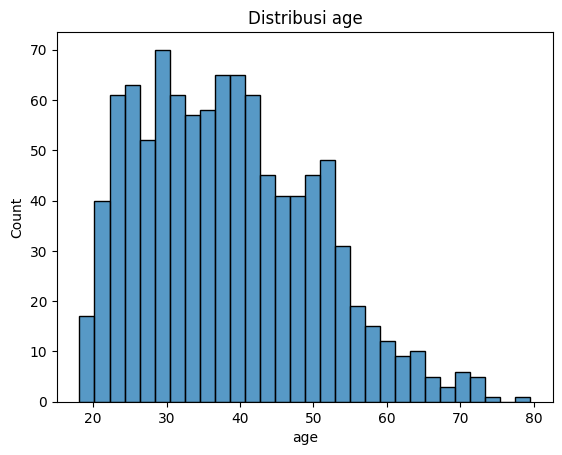

In [178]:
num_col = 'age'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [179]:
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age,,,,
"(22.089, 25.108]",91,0,0.0000,10.0600
"(25.108, 28.328]",90,0,0.0000,9.9400
"(28.328, 31.11]",91,6,6.5934,10.0600
"(31.11, 34.222]",90,3,3.3333,9.9400
"(34.222, 37.47]",91,4,4.3956,10.0600
"(37.47, 40.226]",90,2,2.2222,9.9400
"(40.226, 43.14]",90,5,5.5556,9.9400
"(43.14, 47.792]",91,5,5.4945,10.0600
"(47.792, 51.776]",90,4,4.4444,9.9400


In [180]:
bin_1 = pd.cut(df_train['age'], bins=[-float('inf'),32,41,52,float('inf')], labels=[1,2,3,4])
bin_2 = pd.cut(df_test['age'], bins=[-float('inf'),32,41,52,float('inf')], labels=[1,2,3,4])

# lalu pakai map untuk memberi label lebih deskriptif
age_map_dict = {
    1: 'A1 (-inf,32]',
    2: 'A2 (32,41]',
    3: 'A3 (41,52]',
    4: 'A4 (52,inf]'
}

df_train['age_group'] = bin_1.astype(int).map(age_map_dict)

df_test['age_group'] = bin_2.astype(int).map(age_map_dict)

In [181]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,age_group,total,bad_ratio,portion
0,"A1 (-inf,32]",349,1.7200,34.6600
1,"A2 (32,41]",273,4.0300,27.1100
2,"A3 (41,52]",250,4.8000,24.8300
3,"A4 (52,inf]",135,2.9600,13.4100


### age_low and age_high

In [182]:
df_train['age_low'] = np.where(df_train['age'] <= 30, df_train['age'], 30)

df_train['age_high'] = np.where(df_train['age'] > 30, df_train['age'], 30)

df_test['age_low'] = np.where(df_test['age'] <= 30, df_test['age'], 30)

df_test['age_high'] = np.where(df_test['age'] > 30, df_test['age'], 30)

In [183]:
num_col = 'age_low'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_low,,,,
"(22.089, 25.35]",98,0,0.0000,10.2500
"(25.35, 28.64]",94,1,1.0638,9.8300
"(28.64, 30.0]",764,32,4.1885,79.9200


In [184]:
bin_1 = pd.cut(df_train['age_low'], bins=[-float('inf'),28.64,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['age_low'], bins=[-float('inf'),28.64,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
age_low_map_dict = {
    1: 'A1L (-inf,28.64]',
    2: 'A2L (28.64, inf]'
}

df_train['age_low_group'] = bin_1.astype(int).map(age_low_map_dict)

df_test['age_low_group'] = bin_2.astype(int).map(age_low_map_dict)

In [185]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_low_group,total,bad_ratio,portion
0,"A1L (-inf,28.64]",243,0.4100,24.1300
1,"A2L (28.64, inf]",764,4.1900,75.8700


In [186]:
num_col = 'age_high'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_high,,,,
"(29.999, 30.292]",299,4,1.3378,29.9900
"(30.292, 33.842]",100,5,5.0000,10.0300
"(33.842, 37.31]",100,4,4.0000,10.0300
"(37.31, 40.406]",99,2,2.0202,9.9300
"(40.406, 43.89]",101,5,4.9505,10.1300
"(43.89, 48.844]",98,6,6.1224,9.8300
"(48.844, 53.45]",100,3,3.0000,10.0300
"(53.45, 69.86]",100,4,4.0000,10.0300


In [187]:
bin_1 = pd.cut(df_train['age_high'], bins=[-float('inf'),40.406,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['age_high'], bins=[-float('inf'),40.406,float('inf')], labels=[1,2])

# lalu pakai map untuk memberi label lebih deskriptif
age_high_map_dict = {
    1: 'A1H (-inf,40.406]',
    2: 'A2H (40.406,inf]'
}

df_train['age_high_group'] = bin_1.astype(int).map(age_high_map_dict)

df_test['age_high_group'] = bin_2.astype(int).map(age_high_map_dict)

In [188]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_high_group,total,bad_ratio,portion
0,"A1H (-inf,40.406]",598,2.5100,59.3800
1,"A2H (40.406,inf]",409,4.4000,40.6200


## Plafond

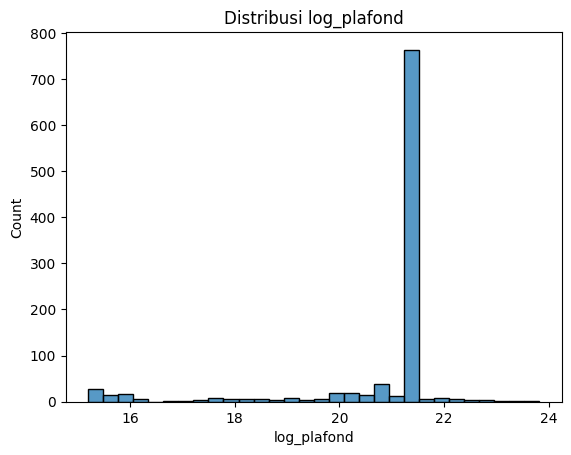

In [189]:
df_train['log_plafond'] = np.log1p(df_train['Plafond'])

df_test['log_plafond'] = np.log1p(df_test['Plafond'])

num_col = 'log_plafond'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [190]:
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafond,,,,
"(15.424000000000001, 19.519]",101,29,28.7129,10.2300
"(19.519, 21.129]",100,3,3.0000,10.1300
"(21.129, 21.416]",766,0,0.0000,77.6100
"(21.416, 22.428]",20,0,0.0000,2.0300


In [191]:
bin_1 = pd.cut(df_train['log_plafond'], bins=[-float('inf'),21.129,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['log_plafond'], bins=[-float('inf'),21.129,float('inf')], labels=[1,2])

# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,21.129]',
    2: 'P2 (21.129,inf]'
}

df_train['log_plafond_group'] = bin_1.astype(int).map(tenure_map_dict)

df_test['log_plafond_group'] = bin_2.astype(int).map(tenure_map_dict)

In [192]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafond_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafond_group,total,bad_ratio,portion
0,"P1 (-inf,21.129]",210,15.2400,20.8500
1,"P2 (21.129,inf]",797,0.1300,79.1500


In [193]:
df_train['Plafond'].describe()

count            1,007.0000
mean     1,781,312,784.7021
std      1,183,696,195.9672
min          4,000,000.0000
25%      2,000,000,000.0000
50%      2,000,000,000.0000
75%      2,000,000,000.0000
max     22,000,000,000.0000
Name: Plafond, dtype: float64

### Plafond Low and High

In [194]:
df_train['log_plafon_low'] = np.log1p(
    np.where(df_train['Plafond'] <= 2_000_000_000, df_train['Plafond'], 2_000_000_000))

df_train['log_plafon_high'] = np.log1p(
    np.where(df_train['Plafond'] > 2_000_000_000, df_train['Plafond'], 2_000_000_000))

df_test['log_plafon_low'] = np.log1p(
    np.where(df_test['Plafond'] <= 2_000_000_000, df_test['Plafond'], 2_000_000_000))

df_test['log_plafon_high'] = np.log1p(
    np.where(df_test['Plafond'] > 2_000_000_000, df_test['Plafond'], 2_000_000_000))

In [195]:
num_col = 'log_plafon_low'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_low,,,,
"(15.424000000000001, 19.519]",101,29,28.7129,10.1200
"(19.519, 21.129]",100,3,3.0000,10.0200
"(21.129, 21.416]",797,1,0.1255,79.8600


In [196]:
bin_1 = pd.cut(df_train['log_plafon_low'], bins=[-float('inf'),21.129,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['log_plafon_low'], bins=[-float('inf'),21.129,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,21.129]',
    2: 'P2 (21.129,inf]'
}

df_train['log_plafon_low_group'] = bin_1.astype(int).map(tenure_map_dict)

df_test['log_plafon_low_group'] = bin_2.astype(int).map(tenure_map_dict)

In [197]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_low_group,total,bad_ratio,portion
0,"P1 (-inf,21.129]",210,15.2400,20.8500
1,"P2 (21.129,inf]",797,0.1300,79.1500


In [198]:
num_col = 'log_plafon_high'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_high,,,,
"(21.415, 22.428]",996,32,3.2129,100.0000


In [199]:
bin_1 = pd.cut(df_train['log_plafon_high'], bins=[-float('inf'),22.3,float('inf')], labels=[1,2])
bin_2 = pd.cut(df_test['log_plafon_high'], bins=[-float('inf'),22.3,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,21.64]',
    2: 'P2 (21.64,inf]'
}

df_train['log_plafon_high_group'] = bin_1.astype(int).map(tenure_map_dict)

df_test['log_plafon_high_group'] = bin_2.astype(int).map(tenure_map_dict)

In [200]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_high_group,total,bad_ratio,portion
0,"P1 (-inf,21.64]",993,3.2200,98.6100
1,"P2 (21.64,inf]",14,7.1400,1.3900


## WoE

In [201]:
df_train.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2', 'sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low', 'age_high', 'age_low_group',
       'age_high_group', 'log_plafond', 'log_plafond_group', 'log_plafon_low',
       'log_plafon_high', 'log_plafon_low_group', 'log_plafon_high_group'],
      dtype='object')

In [202]:
df_train = df_train[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_low_group',
       'age_high_group', 'log_plafond_group', 'flag_30_12MoB']].copy()
df_test = df_test[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_low_group',
       'age_high_group', 'log_plafond_group', 'flag_30_12MoB']].copy()

In [203]:
categorical_cols = ['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_low_group',
       'age_high_group', 'log_plafond_group']
df_train[categorical_cols] = df_train[categorical_cols].astype('category')

df_test[categorical_cols] = df_test[categorical_cols].astype('category')

In [204]:
def hitung_woe_iv(df, target='flag_30_12MoB'):
    """
    Hitung Weight of Evidence (WOE) dan Information Value (IV) untuk setiap bin dari setiap variabel kategorik.
    
    Parameters
    ----------
    df : DataFrame
        Data dengan kolom target dan variabel independen yang sudah di-binning.
    target : str
        Nama kolom target (1 = bad, 0 = good)
    
    Returns
    -------
    woe_df : DataFrame
        Tabel berisi variabel, kategori/bin, jumlah good, jumlah bad, distribusi, WOE, dan kontribusi IV.
    iv_summary : DataFrame
        Ringkasan IV per variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_list = []

    # total good dan bad keseluruhan
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum'])
        temp = temp.rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # distribusi
        temp['bad_dist'] = temp['bad'] / total_bad
        temp['good_dist'] = temp['good'] / total_good

        # WOE dengan perlindungan dari pembagian nol
        epsilon = 1e-6
        temp['woe'] = np.log((temp['good_dist'] + epsilon) / (temp['bad_dist'] + epsilon))

        # Kontribusi IV per bin
        temp['iv_contrib'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        # Simpan IV per variabel
        iv = temp['iv_contrib'].sum()
        iv_list.append({'variabel': col, 'IV': iv})

        # Tambahkan nama variabel dan kategori
        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

    # Gabungkan semua variabel
    woe_df = pd.concat(hasil, ignore_index=True)
    woe_df = woe_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_contrib']]

    # Ringkasan IV per variabel
    iv_summary = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

    return woe_df, iv_summary


In [205]:
# ada tambahan epsilon

def hitung_woe_iv_epsilon(df, target='flag_30_12MoB', epsilon=0.5):
    """
    Hitung WOE dan IV dengan smoothing untuk mengurangi efek target imbalance.
    
    Parameters
    ----------
    df : DataFrame
        Dataset dengan kolom target dan variabel independen (kategori/bin).
    target : str
        Nama kolom target (1=bad, 0=good)
    epsilon : float
        Nilai smoothing untuk mencegah divisi nol
    
    Returns
    -------
    iv_df : DataFrame
        Tabel WOE dan IV untuk tiap bin tiap variabel
    iv_summary : DataFrame
        Ringkasan IV tiap variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_summary = []

    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # smoothing distribusi
        temp['good_dist'] = (temp['good'] + epsilon) / (total_good + epsilon * len(temp))
        temp['bad_dist'] = (temp['bad'] + epsilon) / (total_bad + epsilon * len(temp))

        # WOE
        temp['woe'] = np.log(temp['good_dist'] / temp['bad_dist'])

        # IV per bin
        temp['iv_bin'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

        iv_summary.append({
            'variabel': col,
            'IV': temp['iv_bin'].sum()
        })

    iv_df = pd.concat(hasil, ignore_index=True)
    iv_df = iv_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_bin']]

    iv_summary = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)

    return iv_df, iv_summary

In [206]:
woe_result, iv_summary = hitung_woe_iv(df_train)

# Lihat WOE tiap bin
woe_result

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_contrib
0,sector_group,S1,95,85,10,0.0873,0.3030,-1.2448,0.2686
1,sector_group,S2,324,301,23,0.3090,0.6970,-0.8133,0.3155
2,sector_group,S3,588,588,0,0.6037,0.0000,13.3108,8.0357
3,marital_group,M1,647,619,28,0.6355,0.8485,-0.2890,0.0615
4,marital_group,M2,33,32,1,0.0329,0.0303,0.0808,0.0002
5,marital_group,M3,327,323,4,0.3316,0.1212,1.0064,0.2118
6,edu_group,E1,67,52,15,0.0534,0.4545,-2.1417,0.8592
7,edu_group,E2,803,790,13,0.8111,0.3939,0.7222,0.3013
8,edu_group,E3,137,132,5,0.1355,0.1515,-0.1115,0.0018
9,provinsi_group,P1,136,129,7,0.1324,0.2121,-0.4710,0.0375


In [207]:
# Lihat IV per variabel
iv_summary

,variabel,IV
0,sector_group,8.6198
1,log_plafond_group,3.9060
2,revenue_group,2.4400
3,provinsi_group,2.2662
4,edu_group,1.1622
5,age_low_group,0.5146
6,marital_group,0.2735
7,age_high_group,0.0838
8,gender_group,0.0785


In [208]:
woe_result_sm, iv_summary_sm = hitung_woe_iv_epsilon(df_train)

# Lihat WOE tiap bin
woe_result_sm

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_bin
0,sector_group,S1,95,85,10,0.0876,0.3043,-1.2448,0.2698
1,sector_group,S2,324,301,23,0.3091,0.6812,-0.7902,0.2940
2,sector_group,S3,588,588,0,0.6033,0.0145,3.7287,2.1954
3,marital_group,M1,647,619,28,0.6351,0.8261,-0.2630,0.0502
4,marital_group,M2,33,32,1,0.0333,0.0435,-0.2662,0.0027
5,marital_group,M3,327,323,4,0.3316,0.1304,0.9331,0.1877
6,edu_group,E1,67,52,15,0.0538,0.4493,-2.1220,0.8392
7,edu_group,E2,803,790,13,0.8104,0.3913,0.7280,0.3051
8,edu_group,E3,137,132,5,0.1358,0.1594,-0.1602,0.0038
9,provinsi_group,P1,136,129,7,0.1328,0.2174,-0.4932,0.0417


In [209]:
iv_summary_sm

,variabel,IV
0,log_plafond_group,3.5328
1,sector_group,2.7592
2,revenue_group,2.3627
3,edu_group,1.1480
4,provinsi_group,0.4787
5,age_low_group,0.4031
6,marital_group,0.2407
7,age_high_group,0.0821
8,gender_group,0.0808


In [211]:
#woe_result_sm.to_csv('D:/Development/Hasil/Individual SME/woe_individual_sme.csv')

In [212]:
df_train = df_train.drop(columns = ['age_high_group', 'gender_group'])
df_test = df_test.drop(columns = ['age_high_group', 'gender_group'])

In [213]:
df_train.columns

Index(['sector_group', 'marital_group', 'edu_group', 'provinsi_group',
       'revenue_group', 'age_low_group', 'log_plafond_group', 'flag_30_12MoB'],
      dtype='object')

In [214]:
# Pisahkan X dan y
X_train = df_train[['sector_group', 'marital_group', 'edu_group', 'provinsi_group',
       'revenue_group', 'age_low_group', 'log_plafond_group']]
y_train = df_train['flag_30_12MoB']

X_test = df_test[['sector_group', 'marital_group', 'edu_group', 'provinsi_group',
       'revenue_group', 'age_low_group', 'log_plafond_group']]
y_test = df_test['flag_30_12MoB']


In [215]:
X_woe = X_train.copy()  # buat salinan agar aman

for col in X_train.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe[col] = X_train[col].map(woe_map)

X_woe_test = X_test.copy()

for col in X_test.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe_test[col] = X_test[col].map(woe_map)

In [216]:
pd.DataFrame({'value': X_woe.isnull().sum(), 'percentage': X_woe.isna().mean() * 100})

,value,percentage
sector_group,0,0.0000
marital_group,0,0.0000
edu_group,0,0.0000
provinsi_group,0,0.0000
revenue_group,0,0.0000
age_low_group,0,0.0000
log_plafond_group,0,0.0000


In [217]:
pd.DataFrame({'value': X_woe_test.isnull().sum(), 'percentage': X_woe_test.isna().mean() * 100})

,value,percentage
sector_group,0,0.0000
marital_group,0,0.0000
edu_group,0,0.0000
provinsi_group,0,0.0000
revenue_group,0,0.0000
age_low_group,0,0.0000
log_plafond_group,0,0.0000


## Multikolinearitas (VIF) 

In [218]:
def hitung_vif(df_woe):
    """
    Menghitung Variance Inflation Factor (VIF) untuk dataset WOE.
    
    Parameters
    ----------
    df_woe : DataFrame
        DataFrame berisi variabel independen yang sudah diubah menjadi WOE.
    
    Returns
    -------
    DataFrame
        Tabel VIF untuk setiap variabel.
    """
    
    # tambah konstanta agar kompatibel
    X = df_woe.copy()
    #X = X.assign(const=1)

    vif_data = []
    
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append((X.columns[i], vif))
    
    vif_df = pd.DataFrame(vif_data, columns=['variabel', 'VIF'])

    return vif_df

In [219]:
vif_result = hitung_vif(X_woe)
vif_result

,variabel,VIF
0,sector_group,2.0484
1,marital_group,1.6565
2,edu_group,2.3583
3,provinsi_group,1.0814
4,revenue_group,3.7805
5,age_low_group,1.7075
6,log_plafond_group,4.2445


## SMOTE

In [220]:
X_woe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sector_group       1007 non-null   category
 1   marital_group      1007 non-null   category
 2   edu_group          1007 non-null   category
 3   provinsi_group     1007 non-null   category
 4   revenue_group      1007 non-null   category
 5   age_low_group      1007 non-null   category
 6   log_plafond_group  1007 non-null   category
dtypes: category(7)
memory usage: 7.9 KB


In [221]:
# --- 1. Encode semua kolom kategorik ---
le_dict = {}

X_woe = X_woe.copy()
for col in X_woe.columns:
    le = LabelEncoder()
    X_woe[col] = le.fit_transform(X_woe[col])
    le_dict[col] = le  # disimpan jika nanti mau decode kembali

# --- 2. Terapkan SMOTE + Tomek Links ---
#smt = SMOTETomek(sampling_strategy=0.3, random_state=42)
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_woe, y_train)

# --- 3. Lihat hasil ---
print("Sebelum SMOTE:")
print(y_train.value_counts())
print("\nSesudah SMOTE:")
print(pd.Series(y_res).value_counts())

# --- 4. (Opsional) Decode kembali ke teks kategori ---
for col in X_woe.columns:
    X_res[col] = le_dict[col].inverse_transform(X_res[col])

X_res = pd.DataFrame(X_res, columns=X_woe.columns)

Sebelum SMOTE:
flag_30_12MoB
0    974
1     33
Name: count, dtype: int64

Sesudah SMOTE:
flag_30_12MoB
0    974
1    974
Name: count, dtype: int64


## Training model

In [222]:
X_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sector_group       1948 non-null   float64
 1   marital_group      1948 non-null   float64
 2   edu_group          1948 non-null   float64
 3   provinsi_group     1948 non-null   float64
 4   revenue_group      1948 non-null   float64
 5   age_low_group      1948 non-null   float64
 6   log_plafond_group  1948 non-null   float64
dtypes: float64(7)
memory usage: 106.7 KB


In [223]:
# Gabungkan X dan y untuk analisis korelasi
df_corr = X_res.copy()
df_corr['target'] = y_res

# Hitung korelasi Pearson
corr_with_target = df_corr.corr()['target'].sort_values(ascending=False)

# Tampilkan hasilnya
print("Korelasi variabel independen terhadap target:")
print(corr_with_target)

# Jika ingin tanpa target itu sendiri
#corr_with_target = corr_with_target.drop('target')

Korelasi variabel independen terhadap target:
target               1.0000
provinsi_group      -0.3352
age_low_group       -0.3744
marital_group       -0.3817
edu_group           -0.5513
sector_group        -0.6662
revenue_group       -0.7949
log_plafond_group   -0.8300
Name: target, dtype: float64


### Scikit learn

#### dengan smote

In [224]:
X_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sector_group       1948 non-null   float64
 1   marital_group      1948 non-null   float64
 2   edu_group          1948 non-null   float64
 3   provinsi_group     1948 non-null   float64
 4   revenue_group      1948 non-null   float64
 5   age_low_group      1948 non-null   float64
 6   log_plafond_group  1948 non-null   float64
dtypes: float64(7)
memory usage: 106.7 KB


In [225]:
X_res.head()

,sector_group,marital_group,edu_group,provinsi_group,revenue_group,age_low_group,log_plafond_group
0,-1.2448,-0.2630,-0.1602,-0.1156,-1.3345,-0.2409,-1.6527
1,-1.2448,-0.2630,-0.1602,-0.1156,-1.3345,-0.2409,-1.6527
2,3.7287,-0.2630,-0.1602,-0.1156,1.6656,-0.2409,2.9187
3,-0.7902,-0.2630,-0.1602,-0.1156,-1.3345,-0.2409,2.9187
4,-0.7902,-0.2630,-0.1602,-0.1156,-2.1220,-0.2409,-1.6527


In [226]:
y_res.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1948 entries, 0 to 1947
Series name: flag_30_12MoB
Non-Null Count  Dtype
--------------  -----
1948 non-null   int64
dtypes: int64(1)
memory usage: 15.3 KB


In [227]:
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_res, y_res)
# coef = model.coef_[0]      # koefisien tiap variabel
# intercept = model.intercept_[0]   # konstanta (intercept)

# coef_df = pd.DataFrame({
#     'Variable': X_res.columns,
#     'Coefficient': coef
# })
# coef_df.loc[len(coef_df)] = ['Intercept', intercept]
# coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# coef_df

In [228]:
cols = X_woe_test.columns
X_woe_test[cols] = X_woe_test[cols].astype('float64')

In [229]:
X_woe_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sector_group       422 non-null    float64
 1   marital_group      422 non-null    float64
 2   edu_group          422 non-null    float64
 3   provinsi_group     422 non-null    float64
 4   revenue_group      422 non-null    float64
 5   age_low_group      422 non-null    float64
 6   log_plafond_group  422 non-null    float64
dtypes: float64(7)
memory usage: 23.2 KB


In [230]:
# y_prob_train = model.predict_proba(X_res)[:,1]
# y_prob_test = model.predict_proba(X_woe_test)[:,1]

In [231]:
# df_train_slearn = pd.DataFrame({ 'proba': y_prob_train, 'y_res': y_res })
# df_test_slearn = pd.DataFrame({ 'proba': y_prob_test, 'y_res': y_test })

In [232]:
#df_train_slearn.to_excel('D:/Development/Hasil/proba company train sm v2.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/proba company test sm v2.xlsx')

In [233]:
# num_col = 'proba'
# #low = df_train_slearn[num_col].quantile(0.05)
# #high = df_train_slearn[num_col].quantile(0.95)
# #df_train_no_outlier = df_train_slearn[(df_train_slearn[num_col] >= low) & (df_train_slearn[num_col] <= high)]

# bins = pd.qcut(df_train_slearn[num_col], q=10, duplicates='drop')
# bad_ratio = (
#     df_train_slearn.groupby(bins, observed=False)['y_res']
#     .agg(['count', 'sum'])
#     .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
# )
# bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
# bad_ratio

### sklearn dengan p value

In [234]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
import inspect

def logistic_regression_with_pvalues(X, y):
    """
    Fit logistic regression (scikit-learn) tanpa penalti,
    lalu hitung standard error, z-score, dan p-value via MLE.

    Return:
        result -> tabel koefisien + SE + z + p-value
        model  -> sklearn LogisticRegression yang sudah fit
    """

    # --- Cek apakah sklearn versi baru mendukung penalty='none' ---
    try:
        model = LogisticRegression(penalty='none', solver='lbfgs', max_iter=5000)
        model.fit(X, y)
    except:
        # fallback untuk versi sklearn lama
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
        model.fit(X, y)

    # --- Prediksi probabilitas ---
    p = model.predict_proba(X)[:, 1]

    # --- Design matrix (tambah intercept) ---
    X_design = np.hstack([np.ones((X.shape[0], 1)), X])

    # --- Weight matrix W = diag(p*(1-p)) ---
    W = np.diag(p * (1 - p))

    # --- Fisher Information matrix ---
    info_mat = X_design.T @ W @ X_design

    # --- Variance-covariance matrix ---
    cov_mat = np.linalg.inv(info_mat)

    # --- Standard error ---
    se = np.sqrt(np.diag(cov_mat))

    # --- Ambil parameter (intercept + coef) ---
    params = np.hstack([model.intercept_, model.coef_.flatten()])

    # --- Hitung z-score & p-value ---
    z = params / se
    p_values = 2 * (1 - norm.cdf(np.abs(z)))

    # --- Pseudo R-Square (McFadden) ---
    eps = 1e-10
    # log-likelihood model penuh
    ll_full = np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    # log-likelihood model null (intercept saja)
    p_null = np.mean(y)
    ll_null = np.sum(y * np.log(p_null + eps) + (1 - y) * np.log(1 - p_null + eps))

    r_square = 1 - (ll_full / ll_null)    
    
    # --- Susun dataframe hasil ---
    names = ["Intercept"] + list(X.columns)
    result = pd.DataFrame({
        "Coefficient": params,
        "Std Error": se,
        "z-score": z,
        "p-value": p_values
    }, index=names)

    return result, model, r_square


In [235]:
result, model, r_square = logistic_regression_with_pvalues(X_res, y_res)

In [236]:
r_square

np.float64(0.736957241934675)

In [237]:
print(result)

                   Coefficient  Std Error  z-score  p-value
Intercept              -2.7828     0.4812  -5.7831   0.0000
sector_group           -1.1910     0.2710  -4.3944   0.0000
marital_group           0.0657     0.3551   0.1851   0.8531
edu_group              -0.2090     0.0817  -2.5576   0.0105
provinsi_group         -1.9181     0.4108  -4.6688   0.0000
revenue_group          -0.5419     0.0800  -6.7740   0.0000
age_low_group          -1.7229     0.6014  -2.8651   0.0042
log_plafond_group      -1.2597     0.2234  -5.6394   0.0000


In [238]:
X_res_2 = X_res.drop(columns=['marital_group'])
X_woe_test_2 = X_woe_test.drop(columns=['marital_group'])

result_2, model_2, r_square_2 = logistic_regression_with_pvalues(X_res_2, y_res)
print(result_2)

                   Coefficient  Std Error  z-score  p-value
Intercept              -2.8131     0.4938  -5.6974   0.0000
sector_group           -1.2009     0.2746  -4.3731   0.0000
edu_group              -0.2059     0.0797  -2.5837   0.0098
provinsi_group         -1.9111     0.4062  -4.7048   0.0000
revenue_group          -0.5403     0.0781  -6.9149   0.0000
age_low_group          -1.6456     0.5721  -2.8764   0.0040
log_plafond_group      -1.2788     0.2333  -5.4814   0.0000


In [239]:
r_square_2

np.float64(0.7369352760944273)

In [244]:
# import joblib

# joblib.dump(model_2, "model awal individual sme.pkl")

In [245]:
# --- Probabilitas Training & Testing ---
y_prob_train = model.predict_proba(X_res)[:, 1]
y_prob_test  = model.predict_proba(X_woe_test)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn = pd.DataFrame({
    'proba': y_prob_train,
    'y_res': y_res
})

df_test_slearn = pd.DataFrame({
    'proba': y_prob_test,
    'y_res': y_test
})


In [246]:
def make_decile_table(df, prob_col='proba', target_col='y_res', q=10):
    """
    Menghitung count, bad, bad_ratio (%), dan portion (%) berdasarkan quantile.
    prob_col  : kolom probabilitas
    target_col: kolom target (1 = bad)
    q         : jumlah bins (default 10 = decile)
    """

    bins = pd.qcut(df[prob_col], q=q, duplicates='drop')

    result = (
        df.groupby(bins, observed=False)[target_col]
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'bad'})
        .assign(
            bad_ratio=lambda x: (x['bad'] / x['count']) * 100,
            portion=lambda x: (x['count'] / x['count'].sum()) * 100
        )
        .round({'bad_ratio': 2, 'portion': 2})
    )

    return result


In [247]:
train_decile = make_decile_table(df_train_slearn, prob_col='proba', target_col='y_res', q=10)
train_decile

,count,bad,bad_ratio,portion
proba,,,,
"(-0.00099999752, 4.33e-07]",203,0,0.0000,10.4200
"(4.33e-07, 1.19e-05]",249,0,0.0000,12.7800
"(1.19e-05, 2.66e-05]",135,0,0.0000,6.9300
"(2.66e-05, 0.00506]",194,0,0.0000,9.9600
"(0.00506, 0.834]",217,93,42.8600,11.1400
"(0.834, 0.884]",208,190,91.3500,10.6800
"(0.884, 0.917]",208,195,93.7500,10.6800
"(0.917, 0.921]",176,170,96.5900,9.0300
"(0.921, 0.94]",205,195,95.1200,10.5200


In [248]:
# --- Probabilitas Training & Testing ---
y_prob_train_2 = model_2.predict_proba(X_res_2)[:, 1]
y_prob_test_2  = model_2.predict_proba(X_woe_test_2)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn_2 = pd.DataFrame({
    'proba': y_prob_train_2,
    'y_res': y_res
})

df_test_slearn_2 = pd.DataFrame({
    'proba': y_prob_test_2,
    'y_res': y_test
})


In [249]:
#df_train_slearn_2.to_excel('D:/Development/Hasil/proba individual sme train sm pvalue.xlsx')
#df_test_slearn_2.to_excel('D:/Development/Hasil/proba individual sme test sm pvalue.xlsx')

In [250]:
train_decile_2 = make_decile_table(df_train_slearn_2, prob_col='proba', target_col='y_res', q=10)
train_decile_2

,count,bad,bad_ratio,portion
proba,,,,
"(-0.00099999739, 4.14e-07]",204,0,0.0000,10.4700
"(4.14e-07, 1.06e-05]",299,0,0.0000,15.3500
"(1.06e-05, 2.31e-05]",84,0,0.0000,4.3100
"(2.31e-05, 0.00493]",205,0,0.0000,10.5200
"(0.00493, 0.835]",209,93,44.5000,10.7300
"(0.835, 0.883]",205,190,92.6800,10.5200
"(0.883, 0.918]",218,205,94.0400,11.1900
"(0.918, 0.921]",176,170,96.5900,9.0300
"(0.921, 0.94]",195,185,94.8700,10.0100


### Statsmodel

In [251]:
# # 1. Cek apakah ada kolom konstan
# print((X_res.nunique() == 1).sum(), "variabel punya 1 nilai unik")

# # 2. Cek kolinearitas ekstrem
# corr = X_res.corr().abs()
# high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
# print(high_corr[high_corr > 0.95])  # tampilkan yang sangat berkorelasi

In [252]:
# corr

In [253]:
# X = X_res.copy()
# y = y_res.copy()

# X = sm.add_constant(X)  # penting agar ada intercept β0

# logit_model = sm.Logit(y, X)
# result = logit_model.fit()

# print(result.summary())

In [254]:
# def stepwise_selection(X, y, threshold_out=0.05):
#     X = sm.add_constant(X)
#     model = sm.Logit(y, X).fit(disp=0)
    
#     while True:
#         pvalues = model.pvalues.iloc[1:]  # skip intercept
#         worst_pval = pvalues.max()
#         if worst_pval > threshold_out:
#             worst_feature = pvalues.idxmax()
#             X = X.drop(columns=[worst_feature])
#             model = sm.Logit(y, X).fit(disp=0)
#         else:
#             break
#     return model

# model_final = stepwise_selection(X, y)
# print(model_final.summary())

In [255]:
# def stepwise_selection(X, y, 
#                        initial_list=[], 
#                        threshold_in=0.05, 
#                        threshold_out=0.10, 
#                        verbose=True):
#     included = list(initial_list)
#     while True:
#         changed=False
#         excluded = list(set(X.columns) - set(included))
#         new_pval = pd.Series(index=excluded, dtype=float)
        
#         for new_column in excluded:
#             try:
#                 model = sm.Logit(y, sm.add_constant(X[included + [new_column]])).fit(disp=0)
#                 new_pval[new_column] = model.pvalues[new_column]
#             except np.linalg.LinAlgError:
#                 new_pval[new_column] = np.nan
        
#         best_pval = new_pval.min()
#         if best_pval is not np.nan and best_pval < threshold_in:
#             best_feature = new_pval.idxmin()
#             included.append(best_feature)
#             changed=True
#             if verbose:
#                 print(f'Add  {best_feature:25} with p-value {best_pval:.6f}')

#         # backward step
#         try:
#             model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
#             pvalues = model.pvalues.iloc[1:]
#             worst_pval = pvalues.max()
#             if worst_pval > threshold_out:
#                 worst_feature = pvalues.idxmax()
#                 included.remove(worst_feature)
#                 changed=True
#                 if verbose:
#                     print(f'Remove {worst_feature:25} with p-value {worst_pval:.6f}')
#         except np.linalg.LinAlgError:
#             break

#         if not changed:
#             break

#     final_model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
#     return final_model, included

# model_final, selected_vars = stepwise_selection(X, y)

In [256]:
# print("Final Selected Variables:")
# print(selected_vars)

# print("\nModel Summary:")
# print(model_final.summary())

## Model tuning (menggunakan platt scaling di scikit learn)

In [257]:
# calibrated_model = CalibratedClassifierCV(estimator=model_2, method='sigmoid', cv='prefit')
# calibrated_model.fit(X=X_woe_test_2, y=y_test)

# y_calibrated = calibrated_model.predict_proba(X_woe_test_2)[:, 1]

In [258]:
# X_woe_test_2.head()

In [259]:
# df_test_cal = pd.DataFrame({ 'proba': y_calibrated, 'y_res': y_test })
# #df_test_cal.to_excel('D:/Development/Hasil/proba company test sm cal v2.xlsx')

In [260]:
# cal = calibrated_model.calibrated_classifiers_[0].calibrators[0]
# print("Slope (A):", cal.a_)
# print("Intercept (B):", cal.b_)

In [261]:
# prob_true, prob_pred = calibration_curve(y_test, y_prob_test_2, n_bins=10)
# prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)

# plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
# plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='After calibration')
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.legend()
# plt.xlabel('Predicted PD')
# plt.ylabel('Actual default rate')
# plt.show()

In [262]:
# brier_before = brier_score_loss(y_test, y_prob_test_2)
# brier_after = brier_score_loss(y_test, y_calibrated)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model Tuning (regresi logistik lagi)

In [263]:
# logit_test_2 = np.log(y_prob_test_2/(1-y_prob_test_2))
# logit_test_2 = pd.DataFrame(logit_test_2)

# result_tun, model_tun, r_square_tun = logistic_regression_with_pvalues(logit_test_2, y_test)

In [264]:
# result_tun

In [265]:
# import joblib

# joblib.dump(model_tun, "model akhir individual sme.pkl")

In [266]:
# y_prob_test_tun  = model_tun.predict_proba(logit_test_2)[:, 1]

# # --- Buat dataframe evaluasi ---

# df_test_slearn_tun = pd.DataFrame({
#     'proba': y_prob_test_tun,
#     'y_res': y_test
# })


In [267]:
#df_test_slearn_tun.to_excel('D:/Development/Hasil/proba individual sme test sm cal pvalue.xlsx')

In [268]:
# test_decile_tun = make_decile_table(df_test_slearn_tun, prob_col='proba', target_col='y_res', q=10)
# test_decile_tun

In [269]:
# brier_before = brier_score_loss(y_test, y_prob_test_2)
# brier_after = brier_score_loss(y_test, y_prob_test_tun)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model tuning (hanya intercept)

In [270]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

logit_old = np.log(y_prob_test_2/(1-y_prob_test_2))
logit_old = pd.DataFrame(logit_old)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def intercept_loss(alpha, logit_old, y_true):
    """
    Loss function untuk tuning intercept saja
    """
    logit_new = logit_old + alpha
    y_pred = sigmoid(logit_new)
    return log_loss(y_true, y_pred)

# initial value alpha = 0 (tidak ada adjustment)
result = minimize(
    intercept_loss,
    x0=0.0,
    args=(logit_old, y_test),
    method="BFGS"
)

alpha_opt = result.x[0]
print("Optimal intercept adjustment:", alpha_opt)

# logit & PD setelah tuning intercept
logit_calibrated = logit_old + alpha_opt
pd_calibrated = sigmoid(logit_calibrated)

df_calibration = pd.DataFrame({
    # "pd_before_calibration": y_prob_test_2,
    "pd_calibrated": pd_calibrated.to_numpy().ravel(),
    "y_actual": y_test
})

from sklearn.metrics import roc_auc_score

print("AUC sebelum tuning :", roc_auc_score(y_test, sigmoid(logit_old)))
print("AUC sesudah tuning :", roc_auc_score(y_test, pd_calibrated))

print("LogLoss sebelum tuning :", log_loss(y_test, sigmoid(logit_old)))
print("LogLoss sesudah tuning :", log_loss(y_test, pd_calibrated))


Optimal intercept adjustment: -3.7761729522117817
AUC sebelum tuning : 0.7750599520383693
AUC sesudah tuning : 0.7750599520383693
LogLoss sebelum tuning : 0.23468445894350567
LogLoss sesudah tuning : 0.12201597607628269


In [ ]:
# df_calibration.to_excel('D:/Development/Hasil/proba individual test sm cal pvalue (intercept).xlsx')

## Persamaan akhir (pakai plat scaling)

In [272]:
# result_2_reset = result_2.reset_index()

In [273]:
# # intercept dan slope Platt
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# platt_slope = cal.a_
# platt_intercept = cal.b_

# # hitung intercept & slope akhir
# intercept_final = platt_slope * intercept_raw + platt_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * platt_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (pakai regresi logistik lagi)

In [274]:
# result_2_reset = result_2.reset_index()

In [275]:
# # intercept dan slope calibration
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# cal_slope = result_tun['Coefficient'][0]
# cal_intercept = result_tun['Coefficient']['Intercept']

# # hitung intercept & slope akhir
# intercept_final = cal_slope * intercept_raw + cal_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * cal_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (tuning hanya intercept)

In [276]:
model_2.intercept_

array([-2.8131304])

In [277]:
import copy

model_calibrated = copy.deepcopy(model_2)
model_calibrated.intercept_ = model_2.intercept_ + alpha_opt
model_calibrated.intercept_

array([-6.58930335])

In [ ]:
# import joblib

# joblib.dump(model_calibrated, "model akhir individual sme (intercept tuning).pkl")

['model akhir individual sme (intercept tuning).pkl']

In [279]:
result_calibrated = pd.DataFrame({
        "Coefficient": np.hstack([model_calibrated.intercept_, model_calibrated.coef_.flatten()])    
}, index=["Intercept"] + list(X_res_2.columns))
result_calibrated

,Coefficient
Intercept,-6.5893
sector_group,-1.2009
edu_group,-0.2059
provinsi_group,-1.9111
revenue_group,-0.5403
age_low_group,-1.6456
log_plafond_group,-1.2788


# 3. Individual SME Channeling

In [298]:
df = pd.read_csv('dataset individual sme channeling.csv')
df = df.drop(columns=['Unnamed: 0', 'index'])

In [299]:
df.head()

,IDLimit,CIF,NamaDebitur,Segmen,LoanType,TglMulai,TglJatuhTempo,Plafond,Gender,source_income,OccupationName,Segmen Pekerjaan,Debtor Marriage Status,Educational Status,Resident,Golongan Debitur,provinsi_domisili,City,SektorEkonomi_Kategori,age,range_revenue,flag_30_12MoB,flag_30_6MoB,flag_30_2MoB,Segmen_2
0,15110374.0008110.01,15110374,ANGKEN LARAIKA,CHANNELING,PAB05,2024-07-09,2025-07-09,"5,000,000.0000",FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,SEWA.KONTRAK,PERSEORANGAN,Jambi,KAB. TEBO,Pengangkutan dan Pergudangan,29.7600,s/d 50 JUTA,0,0,0,SME
1,30031035.0008110.01,30031035,AYU OKTAPIA,CHANNELING,PAB05,2024-05-13,2025-05-13,"5,000,000.0000",FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,ORANG.TUA.KELUARGA,PERSEORANGAN,Banten,KAB. CIAMIS,"Pertanian, Kehutanan, dan Perikanan",26.4800,s/d 50 JUTA,0,0,0,SME
2,30144675.0008110.01,30144675,LIN PUTRI UTARI,CHANNELING,PAB05,2024-06-04,2025-06-04,"5,000,000.0000",FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,KOST,PERSEORANGAN,Banten,KAB. TAPANULI SELATAN,Industri Pengolahan,24.8900,s/d 50 JUTA,0,0,0,SME
3,60063424.0008110.01,60063424,SUSANTI,CHANNELING,PAB05,2023-12-12,2024-12-12,"5,000,000.0000",FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,NaN,PERSEORANGAN,Sumatera Utara,KAB. SIMALUNGUN,Tidak Terdefinisi,40.0800,> 100 JUTA s/d 200 JUTA,0,0,0,SME
4,60063425.0008110.01,60063425,MARSELINA NAU,CHANNELING,PAB05,2023-12-12,2024-12-12,"5,000,000.0000",FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,NaN,PERSEORANGAN,Nusa Tenggara Timur,KAB. NAGEKEO,Pengangkutan dan Pergudangan,40.6900,> 100 JUTA s/d 200 JUTA,0,0,0,SME


In [300]:
pd.DataFrame({'value': df.isnull().sum(), 'percentage': df.isna().mean() * 100})

,value,percentage
IDLimit,0,0.0000
CIF,0,0.0000
NamaDebitur,0,0.0000
Segmen,0,0.0000
LoanType,0,0.0000
TglMulai,0,0.0000
TglJatuhTempo,0,0.0000
Plafond,0,0.0000
Gender,0,0.0000
source_income,0,0.0000


In [301]:
df = df.dropna(how='any').reset_index(drop=True)

In [302]:
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('Tidak Terdefinisi', np.nan)

In [303]:
pd.DataFrame({'value': df.isnull().sum(), 'percentage': df.isna().mean() * 100})

,value,percentage
IDLimit,0,0.0000
CIF,0,0.0000
NamaDebitur,0,0.0000
Segmen,0,0.0000
LoanType,0,0.0000
TglMulai,0,0.0000
TglJatuhTempo,0,0.0000
Plafond,0,0.0000
Gender,0,0.0000
source_income,0,0.0000


In [304]:
df[df['SektorEkonomi_Kategori'].isna()]['Segmen Pekerjaan'].unique()

array(['PERDAGANGAN ECERAN'], dtype=object)

In [305]:
# Definisikan mapping dictionary
SektorEkonomi_Kategori_map = {
    'PERDAGANGAN ECERAN': 'Perdagangan Besar dan Eceran',
    'PERDAGANGAN BESAR': 'Perdagangan Besar dan Eceran',
    'FASHION': 'Industri Pengolahan',
    'TRANSPORTASI': 'Pengangkutan dan Pergudangan',
    'PERHIASAN DAN LOGAM MULIA': 'Perdagangan Besar dan Eceran',
    'MANUFAKTUR': 'Industri Pengolahan'
}

df['SektorEkonomi_Kategori'] = df.apply(
    lambda x: SektorEkonomi_Kategori_map.get(x['Segmen Pekerjaan'], x['SektorEkonomi_Kategori'])
    if pd.isna(x['SektorEkonomi_Kategori']) or x['SektorEkonomi_Kategori'] == ''
    else x['SektorEkonomi_Kategori'],
    axis=1
)
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].fillna('Lainnya')

In [306]:
df['SektorEkonomi_Kategori'].unique()

array(['Pengangkutan dan Pergudangan',
       'Pertanian, Kehutanan, dan Perikanan', 'Industri Pengolahan',
       'Perdagangan Besar dan Eceran', 'Kesenian, Hiburan, dan Rekreasi',
       'Akomodasi dan Penyediaan Makan Minum',
       'Pengelolaan Air, Air Limbah, Daur Ulang',
       'Informasi dan Komunikasi',
       'Aktivitas Profesional, Ilmiah, dan Teknis'], dtype=object)

In [307]:
df['Debtor Marriage Status'].unique()

array(['SINGLE', 'MENIKAH', 'JANDA'], dtype=object)

In [308]:
pd.DataFrame({'value': df.isnull().sum(), 'percentage': df.isna().mean() * 100})

,value,percentage
IDLimit,0,0.0000
CIF,0,0.0000
NamaDebitur,0,0.0000
Segmen,0,0.0000
LoanType,0,0.0000
TglMulai,0,0.0000
TglJatuhTempo,0,0.0000
Plafond,0,0.0000
Gender,0,0.0000
source_income,0,0.0000


In [309]:
df['Educational Status'].unique()

array(['SMA / SLTA', 'SMP / SLTP', 'SEKOLAH DASAR (SD)',
       'UNIVERSITAS / S-1', 'LAINNYA'], dtype=object)

In [310]:
df['Educational Status'] = df['Educational Status'].fillna('LAINNYA')

In [311]:
df['provinsi_domisili'].unique()

array(['Jambi', 'Banten', 'Sumatera Barat', 'Riau', 'Jawa Timur',
       'Sumatera Utara', 'Jawa Tengah', 'Lampung', 'Nusa Tenggara Barat',
       'Bengkulu', 'Jawa Barat', 'Sulawesi Selatan', 'Sulawesi Utara',
       'Sumatera Selatan', 'Gorontalo', 'Sulawesi Tenggara',
       'Nusa Tenggara Timur', 'Kepulauan Bangka Belitung',
       'Sulawesi Tengah', 'Sulawesi Barat', 'Kalimantan Barat',
       'Kalimantan Selatan', 'Kalimantan Timur', 'DKI Jakarta', 'Bali',
       'Kalimantan Tengah', 'Kepulauan Riau', 'Maluku Utara', 'Papua',
       'D.I. Jogjakarta'], dtype=object)

In [312]:
# pastikan kolom bertipe datetime
df['TglMulai'] = pd.to_datetime(df['TglMulai'], errors='coerce')

# buat kolom periode (format YYYY-MM)
df['periode'] = df['TglMulai'].dt.to_period('M')

# hitung jumlah data per tahun-bulan
jumlah_per_bulan = df['periode'].value_counts().sort_index()

jumlah_per_bulan

periode
2023-12       33
2024-01      810
2024-02      959
2024-03     3893
2024-04     1435
2024-05    10483
2024-06    10576
2024-07    10043
2024-08    10181
2024-09     7604
2024-10     8489
Freq: M, Name: count, dtype: int64

In [313]:
#df_train = df[(df['TglMulai'] >= '2023-12-01') & (df['TglMulai'] <= '2024-08-31')].reset_index(drop=True)
#df_validation = df[(df['TglMulai'] >= '2024-09-01') & (df['TglMulai'] <= '2024-10-08')].reset_index(drop=True)
#df_test = df[df['TglMulai'] >= '2024-10-09'].reset_index(drop=True)

In [314]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["flag_30_12MoB"]
)

In [315]:
#df_train.to_excel('D:/Development/Hasil/individual sme channeling/train.xlsx')
#df_test.to_excel('D:/Development/Hasil/individual sme channeling/test.xlsx')

In [316]:
def porsi_dataframe(dfs, names=None):
    import pandas as pd

    if names is None:
        names = [f"df{i+1}" for i in range(len(dfs))]

    counts = [len(df) for df in dfs]
    total = sum(counts)

    summary = pd.DataFrame({
        "Dataframe": names,
        "Jumlah": counts,
        "Porsi": [c / total for c in counts]
    })
    summary["Porsi (%)"] = summary["Porsi"] * 100
    return summary

porsi_dataframe([df_train, df_test], names=["Train", "Test"])

,Dataframe,Jumlah,Porsi,Porsi (%)
0,Train,45154,0.7000,69.9997
1,Test,19352,0.3000,30.0003


In [317]:
df_train['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.7590
1   0.2410
Name: proportion, dtype: float64

In [318]:
df_test['flag_30_12MoB'].value_counts(normalize=True)

flag_30_12MoB
0   0.7590
1   0.2410
Name: proportion, dtype: float64

In [319]:
df_train.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Resident', 'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2', 'periode'],
      dtype='object')

In [320]:
cols_cat = ['Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Resident', 'Golongan Debitur', 'provinsi_domisili',
       'SektorEkonomi_Kategori', 'range_revenue']
df_train[cols_cat] = df_train[cols_cat].astype('category')
df_test[cols_cat] = df_test[cols_cat].astype('category')

## SektorEkonomi_Kategori

In [321]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('SektorEkonomi_Kategori', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,SektorEkonomi_Kategori,total,bad_ratio,portion
1,"Aktivitas Profesional, Ilmiah, dan Teknis",14,28.5700,0.0300
5,Pengangkutan dan Pergudangan,22821,25.5900,50.5400
7,Perdagangan Besar dan Eceran,13281,23.4200,29.4100
3,Informasi dan Komunikasi,13,23.0800,0.0300
4,"Kesenian, Hiburan, dan Rekreasi",1466,22.9900,3.2500
6,"Pengelolaan Air, Air Limbah, Daur Ulang",203,22.1700,0.4500
0,Akomodasi dan Penyediaan Makan Minum,316,22.1500,0.7000
2,Industri Pengolahan,3730,21.9800,8.2600
8,"Pertanian, Kehutanan, dan Perikanan",3310,19.8200,7.3300


In [322]:
df_train['SektorEkonomi_Kategori'].unique()

['Pengangkutan dan Pergudangan', 'Perdagangan Besar dan Eceran', 'Industri Pengolahan', 'Pertanian, Kehutanan, dan Perikanan', 'Kesenian, Hiburan, dan Rekreasi', 'Pengelolaan Air, Air Limbah, Daur Ulang', 'Aktivitas Profesional, Ilmiah, dan Teknis', 'Akomodasi dan Penyediaan Makan Minum', 'Informasi dan Komunikasi']
Categories (9, object): ['Akomodasi dan Penyediaan Makan Minum', 'Aktivitas Profesional, Ilmiah, dan Teknis', 'Industri Pengolahan', 'Informasi dan Komunikasi', ..., 'Pengangkutan dan Pergudangan', 'Pengelolaan Air, Air Limbah, Daur Ulang', 'Perdagangan Besar dan Eceran', 'Pertanian, Kehutanan, dan Perikanan']

In [323]:
sector_to_group = {
    'Rumah Tangga': 'S3',
    'Pertanian, Kehutanan, dan Perikanan': 'S3',

    'Aktivitas Profesional, Ilmiah, dan Teknis': 'S1',
    'Kesenian, Hiburan, dan Rekreasi': 'S2',
    'Informasi dan Komunikasi': 'S2',
    'Pengangkutan dan Pergudangan': 'S1',
    'Industri Pengolahan': 'S3',

    'Akomodasi dan Penyediaan Makan Minum': 'S2',
    'Keuangan dan Asuransi': 'S3',
    'Pengelolaan Air, Air Limbah, Daur Ulang': 'S2',
    'Perdagangan Besar dan Eceran': 'S2',
    'Penyewaan dan Sewa Guna Usaha': 'S3',
    'Pertambangan dan Penggalian': 'S3',
    'LAINNYA': 'S3'
}

df_train['sector_group'] = df_train['SektorEkonomi_Kategori'].map(sector_to_group)
df_test['sector_group'] = df_test['SektorEkonomi_Kategori'].map(sector_to_group)

In [324]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('sector_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,sector_group,total,bad_ratio,portion
0,S1,22835,25.5900,50.5700
1,S2,15279,23.3300,33.8400
2,S3,7040,20.9700,15.5900


## Debtor Marriage Status

In [325]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Debtor Marriage Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Debtor Marriage Status,total,bad_ratio,portion
0,JANDA,2135,27.5900,4.7300
1,MENIKAH,43017,23.9300,95.2700
2,SINGLE,2,0.0000,0.0000


In [326]:
marital_to_group = {
    'MENIKAH': 'M2',
    'JANDA': 'M1',
    'CERAIHIDUP': 'M1',
    'CERAIMATI': 'M1',
    'DUDA': 'M1',
    'SINGLE': 'M3'
}

df_train['marital_group'] = df_train['Debtor Marriage Status'].map(marital_to_group)
df_test['marital_group'] = df_test['Debtor Marriage Status'].map(marital_to_group)

In [327]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('marital_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,marital_group,total,bad_ratio,portion
0,M1,2135,27.5900,4.7300
1,M2,43017,23.9300,95.2700
2,M3,2,0.0000,0.0000


## Educational Status

In [328]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Educational Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Educational Status,total,bad_ratio,portion
3,SMP / SLTP,26739,24.7800,59.2200
1,SEKOLAH DASAR (SD),15592,23.5000,34.5300
4,UNIVERSITAS / S-1,1362,22.2500,3.0200
0,LAINNYA,1445,20.0000,3.2000
2,SMA / SLTA,16,12.5000,0.0400


In [329]:
edu_to_group = {
    'SEKOLAH DASAR (SD)': 'E1',
    'SMP / SLTP': 'E1',
    'SMA / SLTA': 'E2',
    'DIPLOMA III (D3)/AKADEMI': 'E2',
    'UNIVERSITAS / S-1': 'E2',
    'UNIVERSITAS / S-2': 'E2',
    'UNIVERSITAS / S-3': 'E2',
    'LAINNYA': 'E2'
}

df_train['edu_group'] = df_train['Educational Status'].map(edu_to_group)
df_test['edu_group'] = df_test['Educational Status'].map(edu_to_group)

In [330]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('edu_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,edu_group,total,bad_ratio,portion
0,E1,42331,24.3100,93.7500
1,E2,2823,21.0400,6.2500


## provinsi_domisili

In [331]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_domisili', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_domisili,total,bad_ratio,portion
18,Nusa Tenggara Barat,2440,45.7800,5.4000
13,Kalimantan Timur,417,43.4100,0.9200
7,Jawa Barat,4054,41.5100,8.9800
4,DKI Jakarta,5,40.0000,0.0100
3,D.I. Jogjakarta,18,33.3300,0.0400
1,Banten,385,32.7300,0.8500
12,Kalimantan Tengah,285,30.1800,0.6300
8,Jawa Tengah,4490,29.2900,9.9400
27,Sumatera Barat,2129,27.0100,4.7100
9,Jawa Timur,5805,23.9800,12.8600


In [332]:
provinsi_to_group = {
    'Nusa Tenggara Barat': 'P1',
    'Kalimantan Timur': 'P1',
    'Jawa Barat': 'P2',
    'Banten': 'P2',
    'Kalimantan Tengah': 'P1',
    'Jawa Tengah': 'P1',
    'Sumatera Barat': 'P1',
    'Jawa Timur': 'P2',
    'Sumatera Selatan': 'P2',
    'Sumatera Utara': 'P2',
    'Kalimantan Selatan': 'P2',
    'Sulawesi Utara': 'P2',
    'Kalimantan Barat': 'P2',
    'Lampung': 'P2',
    'Sulawesi Selatan': 'P2',
    'Jambi': 'P3',
    'Gorontalo': 'P3',
    'Bengkulu': 'P3',
    'Kepulauan Bangka Belitung': 'P3',
    'Nusa Tenggara Timur': 'P3',
    'Bali': 'P3',
    'Sulawesi Tengah': 'P3',
    'Riau': 'P3',
    'Sulawesi Barat': 'P3',
    'Sulawesi Tenggara': 'P3',
    'DKI Jakarta': 'P2',
    'D.I. Jogjakarta': 'P3',  
    'KALIMANTAN UTARA': 'P3',
    'Kepulauan Riau': 'P3',
    'Sumatera Utara': 'P3',
    'Maluku': 'P3',
    'Maluku Utara': 'P3'
}

df_train['provinsi_group'] = df_train['provinsi_domisili'].map(provinsi_to_group)
df_train['provinsi_group'] = df_train['provinsi_group'].fillna('P3')

df_test['provinsi_group'] = df_test['provinsi_domisili'].map(provinsi_to_group)
df_test['provinsi_group'] = df_test['provinsi_group'].fillna('P3')

In [333]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_group,total,bad_ratio,portion
0,P1,9761,33.5400,21.6200
1,P2,18248,26.9800,40.4100
2,P3,17145,15.6700,37.9700


## range_revenue

In [334]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('range_revenue', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,range_revenue,total,bad_ratio,portion
1,> 200 JUTA,5244,25.1500,11.6100
2,> 50 JUTA s/d 100 JUTA,13861,24.7500,30.7000
0,> 100 JUTA s/d 200 JUTA,21385,23.7500,47.3600
3,s/d 50 JUTA,4664,22.6200,10.3300


In [335]:
revenue_to_group = {
    's/d 50 JUTA': 'R1',
    '> 50 JUTA s/d 100 JUTA': 'R2',
    '> 100 JUTA s/d 200 JUTA': 'R2',
    '> 200 JUTA': 'R3'
}

df_train['revenue_group'] = df_train['range_revenue'].map(revenue_to_group)
df_test['revenue_group'] = df_test['range_revenue'].map(revenue_to_group)

In [336]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('revenue_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,revenue_group,total,bad_ratio,portion
2,R3,5244,25.1500,11.6100
1,R2,35246,24.1400,78.0600
0,R1,4664,22.6200,10.3300


## Gender

In [337]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Gender', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Gender,total,bad_ratio,portion
0,FEMALE,45154,24.1000,100.0000


In [338]:
gender_to_group = {
    'FEMALE': 'G1',
    'MALE': 'G2'
}

df_train['gender_group'] = df_train['Gender'].map(gender_to_group)
df_test['gender_group'] = df_test['Gender'].map(gender_to_group)

In [339]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('gender_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,gender_group,total,bad_ratio,portion
0,G1,45154,24.1000,100.0000


## age

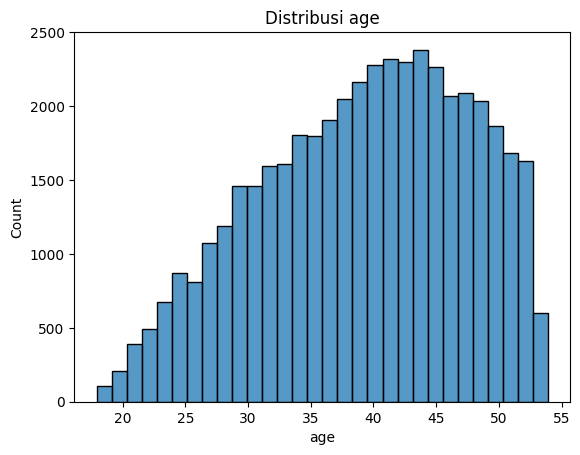

In [340]:
num_col = 'age'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [341]:
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age,,,,
"(20.769, 27.8]",4436,1091,24.5942,10.0200
"(27.8, 31.59]",4421,1095,24.7682,9.9900
"(31.59, 34.72]",4433,1046,23.5958,10.0200
"(34.72, 37.58]",4417,1101,24.9264,9.9800
"(37.58, 40.0]",4422,1089,24.6269,9.9900
"(40.0, 42.25]",4437,1082,24.3858,10.0300
"(42.25, 44.57]",4418,1053,23.8343,9.9800
"(44.57, 47.03]",4437,1053,23.7323,10.0300
"(47.03, 49.69]",4417,981,22.2096,9.9800


In [342]:
bin_1 = pd.cut(df_train['age'], bins=[-float('inf'),33,47,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['age'], bins=[-float('inf'),33,47,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
age_map_dict = {
    1: 'A1 (-inf,33]',
    2: 'A2 (33,47]',
    3: 'A3 (47,inf]'
}

df_train['age_group'] = bin_1.astype(int).map(age_map_dict)
df_test['age_group'] = bin_3.astype(int).map(age_map_dict)

In [343]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,age_group,total,bad_ratio,portion
0,"A1 (-inf,33]",11218,24.4200,24.8400
1,"A2 (33,47]",24584,24.2500,54.4400
2,"A3 (47,inf]",9352,23.3400,20.7100


### age_low and age_high

In [344]:
df_train['age_low'] = np.where(df_train['age'] <= 32, df_train['age'], 32)

df_train['age_high'] = np.where(df_train['age'] > 32, df_train['age'], 32)

df_test['age_low'] = np.where(df_test['age'] <= 32, df_test['age'], 32)

df_test['age_high'] = np.where(df_test['age'] > 32, df_test['age'], 32)

In [345]:
num_col = 'age_low'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_low,,,,
"(24.499, 29.33]",4298,1056,24.5696,10.0200
"(29.33, 32.0]",38602,9273,24.0221,89.9800


In [346]:
bin_1 = pd.cut(df_train['age_low'], bins=[-float('inf'),29.35,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['age_low'], bins=[-float('inf'),29.35,float('inf')], labels=[1,2])

# lalu pakai map untuk memberi label lebih deskriptif
age_low_map_dict = {
    1: 'A1L (-inf,29.35]',
    2: 'A2L (29.35, inf]'
}

df_train['age_low_group'] = bin_1.astype(int).map(age_low_map_dict)
df_test['age_low_group'] = bin_3.astype(int).map(age_low_map_dict)

In [347]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_low_group,total,bad_ratio,portion
0,"A1L (-inf,29.35]",6574,24.6000,14.5600
1,"A2L (29.35, inf]",38580,24.0200,85.4400


In [348]:
num_col = 'age_high'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_6MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_high,,,,
"(31.999, 34.14]",12881,833,6.4669,30.0200
"(34.14, 36.96]",4289,285,6.6449,10.0000
"(36.96, 39.41]",4285,268,6.2544,9.9900
"(39.41, 41.69]",4297,263,6.1205,10.0200
"(41.69, 43.937]",4279,247,5.7724,9.9700
"(43.937, 46.13]",4297,257,5.9809,10.0200
"(46.13, 48.71]",4296,230,5.3538,10.0100
"(48.71, 51.49]",4278,239,5.5867,9.9700


In [349]:
bin_1 = pd.cut(df_train['age_high'], bins=[-float('inf'),36.9,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['age_high'], bins=[-float('inf'),36.9,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
age_high_map_dict = {
    1: 'A1H (-inf,36.9]',
    2: 'A2H (36.9,inf]'
}

df_train['age_high_group'] = bin_1.astype(int).map(age_high_map_dict)
df_test['age_high_group'] = bin_3.astype(int).map(age_high_map_dict)

In [350]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_high_group,total,bad_ratio,portion
0,"A1H (-inf,36.9]",17062,24.5400,37.7900
1,"A2H (36.9,inf]",28092,23.8400,62.2100


## Plafond

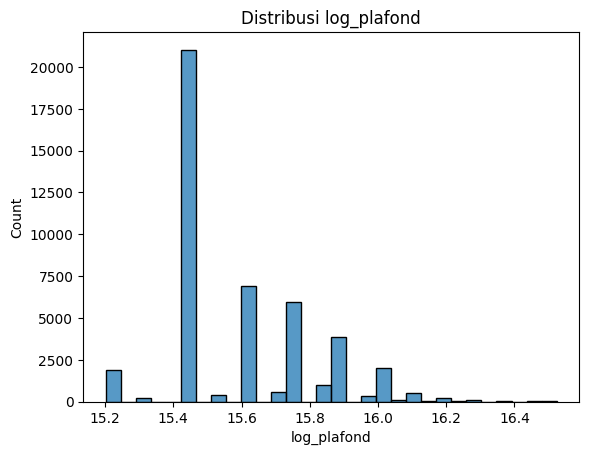

In [351]:
df_train['log_plafond'] = np.log1p(df_train['Plafond'])
df_test['log_plafond'] = np.log1p(df_test['Plafond'])

num_col = 'log_plafond'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [352]:
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafond,,,,
"(15.201, 15.425]",23117,5209,22.5332,51.6100
"(15.425, 15.607]",7344,1853,25.2315,16.4000
"(15.607, 15.761]",6521,1752,26.8670,14.5600
"(15.761, 15.895]",4848,1292,26.6502,10.8200
"(15.895, 16.118]",2960,688,23.2432,6.6100


In [353]:
bin_1 = pd.cut(df_train['log_plafond'], bins=[-float('inf'),15.425,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafond'], bins=[-float('inf'),15.425,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.425]',
    2: 'P2 (15.425,inf]'
}

df_train['log_plafond_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafond_group'] = bin_3.astype(int).map(tenure_map_dict)

In [354]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafond_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafond_group,total,bad_ratio,portion
0,"P1 (-inf,15.425]",23117,22.5300,51.2000
1,"P2 (15.425,inf]",22037,25.7500,48.8000


In [355]:
df_train['Plafond'].describe()

count       45,154.0000
mean     6,032,566.3286
std      1,444,913.9263
min      4,000,000.0000
25%      5,000,000.0000
50%      5,000,000.0000
75%      7,000,000.0000
max     15,000,000.0000
Name: Plafond, dtype: float64

### Plafond Low and High

In [356]:
df_train['log_plafon_low'] = np.log1p(
    np.where(df_train['Plafond'] <= 5_000_000, df_train['Plafond'], 5_000_000))
df_train['log_plafon_high'] = np.log1p(
    np.where(df_train['Plafond'] > 5_000_000, df_train['Plafond'], 5_000_000))

df_test['log_plafon_low'] = np.log1p(
    np.where(df_test['Plafond'] <= 5_000_000, df_test['Plafond'], 5_000_000))
df_test['log_plafon_high'] = np.log1p(
    np.where(df_test['Plafond'] > 5_000_000, df_test['Plafond'], 5_000_000))

In [357]:
num_col = 'log_plafon_low'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_low,,,,
"(15.201, 15.425]",45154,10884,24.1042,100.0000


In [358]:
bin_1 = pd.cut(df_train['log_plafon_low'], bins=[-float('inf'),15.3,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafon_low'], bins=[-float('inf'),15.3,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.3]',
    2: 'P2 (15.3,inf]'
}

df_train['log_plafon_low_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafon_low_group'] = bin_3.astype(int).map(tenure_map_dict)

In [359]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_low_group,total,bad_ratio,portion
0,"P1 (-inf,15.3]",1871,28.9200,4.1400
1,"P2 (15.3,inf]",43283,23.9000,95.8600


In [360]:
num_col = 'log_plafon_high'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_high,,,,
"(15.424000000000001, 15.607]",30461,7062,23.1837,68.0100
"(15.607, 15.761]",6521,1752,26.8670,14.5600
"(15.761, 15.895]",4848,1292,26.6502,10.8200
"(15.895, 16.118]",2960,688,23.2432,6.6100


In [361]:
bin_1 = pd.cut(df_train['log_plafon_high'], bins=[-float('inf'),15.607,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafon_high'], bins=[-float('inf'),15.607,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.607]',
    2: 'P2 (15.607,inf]'
}

df_train['log_plafon_high_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafon_high_group'] = bin_3.astype(int).map(tenure_map_dict)

In [362]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_high_group,total,bad_ratio,portion
0,"P1 (-inf,15.607]",23528,22.6800,52.1100
1,"P2 (15.607,inf]",21626,25.6500,47.8900


## WoE

In [363]:
df_train.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Resident', 'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2', 'periode', 'sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low', 'age_high', 'age_low_group',
       'age_high_group', 'log_plafond', 'log_plafond_group', 'log_plafon_low',
       'log_plafon_high', 'log_plafon_low_group', 'log_plafon_high_group'],
      dtype='object')

In [364]:
df_train = df_train[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low_group',
       'age_high_group', 'log_plafond_group', 'flag_30_12MoB']].copy()

df_test = df_test[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low_group',
       'age_high_group', 'log_plafond_group', 'flag_30_12MoB']].copy()

In [365]:
categorical_cols = ['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low_group',
       'age_high_group', 'log_plafond_group']

df_train[categorical_cols] = df_train[categorical_cols].astype('category')
df_test[categorical_cols] = df_test[categorical_cols].astype('category')

In [366]:
# Pisahkan X dan y
X_train = df_train[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low_group',
       'age_high_group', 'log_plafond_group']]
y_train = df_train['flag_30_12MoB']

X_test = df_test[['sector_group',
       'marital_group', 'edu_group', 'provinsi_group', 'revenue_group',
       'gender_group', 'age_group', 'age_low_group',
       'age_high_group', 'log_plafond_group']]
y_test = df_test['flag_30_12MoB']


In [367]:
def hitung_woe_iv(df, target='flag_30_12MoB'):
    """
    Hitung Weight of Evidence (WOE) dan Information Value (IV) untuk setiap bin dari setiap variabel kategorik.
    
    Parameters
    ----------
    df : DataFrame
        Data dengan kolom target dan variabel independen yang sudah di-binning.
    target : str
        Nama kolom target (1 = bad, 0 = good)
    
    Returns
    -------
    woe_df : DataFrame
        Tabel berisi variabel, kategori/bin, jumlah good, jumlah bad, distribusi, WOE, dan kontribusi IV.
    iv_summary : DataFrame
        Ringkasan IV per variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_list = []

    # total good dan bad keseluruhan
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum'])
        temp = temp.rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # distribusi
        temp['bad_dist'] = temp['bad'] / total_bad
        temp['good_dist'] = temp['good'] / total_good

        # WOE dengan perlindungan dari pembagian nol
        epsilon = 1e-6
        temp['woe'] = np.log((temp['good_dist'] + epsilon) / (temp['bad_dist'] + epsilon))

        # Kontribusi IV per bin
        temp['iv_contrib'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        # Simpan IV per variabel
        iv = temp['iv_contrib'].sum()
        iv_list.append({'variabel': col, 'IV': iv})

        # Tambahkan nama variabel dan kategori
        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

    # Gabungkan semua variabel
    woe_df = pd.concat(hasil, ignore_index=True)
    woe_df = woe_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_contrib']]

    # Ringkasan IV per variabel
    iv_summary = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

    return woe_df, iv_summary


In [368]:
# ada tambahan epsilon

def hitung_woe_iv_epsilon(df, target='flag_30_12MoB', epsilon=0.5):
    """
    Hitung WOE dan IV dengan smoothing untuk mengurangi efek target imbalance.
    
    Parameters
    ----------
    df : DataFrame
        Dataset dengan kolom target dan variabel independen (kategori/bin).
    target : str
        Nama kolom target (1=bad, 0=good)
    epsilon : float
        Nilai smoothing untuk mencegah divisi nol
    
    Returns
    -------
    iv_df : DataFrame
        Tabel WOE dan IV untuk tiap bin tiap variabel
    iv_summary : DataFrame
        Ringkasan IV tiap variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_summary = []

    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # smoothing distribusi
        temp['good_dist'] = (temp['good'] + epsilon) / (total_good + epsilon * len(temp))
        temp['bad_dist'] = (temp['bad'] + epsilon) / (total_bad + epsilon * len(temp))

        # WOE
        temp['woe'] = np.log(temp['good_dist'] / temp['bad_dist'])

        # IV per bin
        temp['iv_bin'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

        iv_summary.append({
            'variabel': col,
            'IV': temp['iv_bin'].sum()
        })

    iv_df = pd.concat(hasil, ignore_index=True)
    iv_df = iv_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_bin']]

    iv_summary = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)

    return iv_df, iv_summary

In [369]:
woe_result, iv_summary = hitung_woe_iv(df_train)

# Lihat WOE tiap bin
woe_result

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_contrib
0,sector_group,S1,22835,16992,5843,0.4958,0.5368,-0.0795,0.0033
1,sector_group,S2,15279,11714,3565,0.3418,0.3275,0.0426,0.0006
2,sector_group,S3,7040,5564,1476,0.1624,0.1356,0.1800,0.0048
3,marital_group,M1,2135,1546,589,0.0451,0.0541,-0.1820,0.0016
4,marital_group,M2,43017,32722,10295,0.9548,0.9459,0.0094,0.0001
5,marital_group,M3,2,2,0,0.0001,0.0000,4.0836,0.0002
6,edu_group,E1,42331,32041,10290,0.9350,0.9454,-0.0111,0.0001
7,edu_group,E2,2823,2229,594,0.0650,0.0546,0.1754,0.0018
8,provinsi_group,P1,9761,6487,3274,0.1893,0.3008,-0.4632,0.0517
9,provinsi_group,P2,18248,13325,4923,0.3888,0.4523,-0.1513,0.0096


In [370]:
# Lihat IV per variabel
iv_summary

,variabel,IV
0,provinsi_group,0.1550
1,sector_group,0.0087
2,log_plafond_group,0.0077
3,marital_group,0.0020
4,edu_group,0.0020
5,revenue_group,0.0011
6,age_group,0.0005
7,age_high_group,0.0003
8,age_low_group,0.0001
9,gender_group,0.0000


In [371]:
woe_result_sm, iv_summary_sm = hitung_woe_iv_epsilon(df_train)

# Lihat WOE tiap bin
woe_result_sm

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_bin
0,sector_group,S1,22835,16992,5843,0.4958,0.5368,-0.0794,0.0033
1,sector_group,S2,15279,11714,3565,0.3418,0.3275,0.0426,0.0006
2,sector_group,S3,7040,5564,1476,0.1624,0.1356,0.1799,0.0048
3,marital_group,M1,2135,1546,589,0.0451,0.0542,-0.1824,0.0016
4,marital_group,M2,43017,32722,10295,0.9548,0.9458,0.0095,0.0001
5,marital_group,M3,2,2,0,0.0001,0.0000,0.4626,0.0000
6,edu_group,E1,42331,32041,10290,0.9349,0.9454,-0.0111,0.0001
7,edu_group,E2,2823,2229,594,0.0651,0.0546,0.1749,0.0018
8,provinsi_group,P1,9761,6487,3274,0.1893,0.3008,-0.4632,0.0517
9,provinsi_group,P2,18248,13325,4923,0.3888,0.4523,-0.1512,0.0096


In [372]:
iv_summary_sm

,variabel,IV
0,provinsi_group,0.1550
1,sector_group,0.0087
2,log_plafond_group,0.0077
3,edu_group,0.0019
4,marital_group,0.0017
5,revenue_group,0.0011
6,age_group,0.0005
7,age_high_group,0.0003
8,age_low_group,0.0001
9,gender_group,0.0000


In [373]:
X_woe = X_train.copy()  # buat salinan agar aman

for col in X_train.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe[col] = X_train[col].map(woe_map)

X_woe_test = X_test.copy()

for col in X_test.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe_test[col] = X_test[col].map(woe_map)

In [374]:
X_woe = X_woe.drop(columns=['age_high_group','age_group',
                            'age_low_group','gender_group'])
X_woe_test = X_woe_test.drop(columns=['age_high_group','age_group',
                            'age_low_group','gender_group'])

## Multikolinearitas (VIF) 

In [375]:
def hitung_vif(df_woe):
    """
    Menghitung Variance Inflation Factor (VIF) untuk dataset WOE.
    
    Parameters
    ----------
    df_woe : DataFrame
        DataFrame berisi variabel independen yang sudah diubah menjadi WOE.
    
    Returns
    -------
    DataFrame
        Tabel VIF untuk setiap variabel.
    """
    
    # tambah konstanta agar kompatibel
    X = df_woe.copy()
    #X = X.assign(const=1)

    vif_data = []
    
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append((X.columns[i], vif))
    
    vif_df = pd.DataFrame(vif_data, columns=['variabel', 'VIF'])

    return vif_df

In [376]:
vif_result = hitung_vif(X_woe)
vif_result

,variabel,VIF
0,sector_group,1.0020
1,marital_group,1.0014
2,edu_group,1.0018
3,provinsi_group,1.0053
4,revenue_group,1.0045
5,log_plafond_group,1.0026


## SMOTE

In [377]:
#X_woe.info()

In [378]:
# # --- 1. Encode semua kolom kategorik ---
# le_dict = {}

# X_woe = X_woe.copy()
# for col in X_woe.columns:
#     le = LabelEncoder()
#     X_woe[col] = le.fit_transform(X_woe[col])
#     le_dict[col] = le  # disimpan jika nanti mau decode kembali

# # --- 2. Terapkan SMOTE + Tomek Links ---
# #smt = SMOTETomek(sampling_strategy=0.3, random_state=42)
# smt = SMOTETomek(random_state=42)
# X_res, y_res = smt.fit_resample(X_woe, y_train)

# # --- 3. Lihat hasil ---
# print("Sebelum SMOTE:")
# print(y_train.value_counts())
# print("\nSesudah SMOTE:")
# print(pd.Series(y_res).value_counts())

# # --- 4. (Opsional) Decode kembali ke teks kategori ---
# for col in X_woe.columns:
#     X_res[col] = le_dict[col].inverse_transform(X_res[col])

# X_res = pd.DataFrame(X_res, columns=X_woe.columns)

## Training model

In [379]:
cols = X_woe.columns
X_woe[cols] = X_woe[cols].astype('float64')
X_woe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45154 entries, 46161 to 43703
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sector_group       45154 non-null  float64
 1   marital_group      45154 non-null  float64
 2   edu_group          45154 non-null  float64
 3   provinsi_group     45154 non-null  float64
 4   revenue_group      45154 non-null  float64
 5   log_plafond_group  45154 non-null  float64
dtypes: float64(6)
memory usage: 2.4 MB


In [380]:
#X_res.info()

In [381]:
# Gabungkan X dan y untuk analisis korelasi
df_corr = X_woe.copy()
df_corr['target'] = y_train

# Hitung korelasi Pearson
corr_with_target = df_corr.corr()['target'].sort_values(ascending=False)

# Tampilkan hasilnya
print("Korelasi variabel independen terhadap target:")
print(corr_with_target)

# Jika ingin tanpa target itu sendiri
#corr_with_target = corr_with_target.drop('target')

Korelasi variabel independen terhadap target:
target               1.0000
revenue_group       -0.0140
marital_group       -0.0184
edu_group           -0.0185
log_plafond_group   -0.0376
sector_group        -0.0395
provinsi_group      -0.1643
Name: target, dtype: float64


### Scikit learn

#### dengan smote

In [382]:
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_res, y_res)
# coef = model.coef_[0]      # koefisien tiap variabel
# intercept = model.intercept_[0]   # konstanta (intercept)

# coef_df = pd.DataFrame({
#     'Variable': X_res.columns,
#     'Coefficient': coef
# })
# coef_df.loc[len(coef_df)] = ['Intercept', intercept]
# coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# coef_df

In [383]:
# y_prob_train = model.predict_proba(X_res)[:,1]
# y_prob_test = model.predict_proba(X_woe_test)[:,1]

In [384]:
# df_train_slearn = pd.DataFrame({ 'proba': y_prob_train, 'y_res': y_res })
# df_test_slearn = pd.DataFrame({ 'proba': y_prob_test, 'y_res': y_test })

In [385]:
#df_train_slearn['proba'] = df_train_slearn['proba'].round(30)
#df_test_slearn['proba'] = df_test_slearn['proba'].round(30)

In [386]:
#df_train_slearn.to_excel('D:/Development/Hasil/proba individual sme train sm.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/proba individual sme test sm.xlsx')

In [387]:
# num_col = 'proba'

# bins = pd.qcut(df_train_slearn[num_col], q=10, duplicates='drop')
# bad_ratio = (
#     df_train_slearn.groupby(bins, observed=False)['y_res']
#     .agg(['count', 'sum'])
#     .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
# )
# bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
# bad_ratio

### tanpa smote

In [388]:
X_woe.head()

,sector_group,marital_group,edu_group,provinsi_group,revenue_group,log_plafond_group
46161,-0.0794,0.0095,-0.0111,-0.1512,-0.0022,-0.0881
58778,0.0426,0.0095,0.1749,-0.4632,-0.0022,-0.0881
43895,-0.0794,0.0095,-0.0111,0.5358,-0.0022,-0.0881
25245,0.1799,0.0095,-0.0111,-0.4632,-0.0022,-0.0881
31132,-0.0794,0.0095,0.1749,0.5358,-0.0022,0.0879


In [389]:
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_woe, y_train)
# coef = model.coef_[0]      # koefisien tiap variabel
# intercept = model.intercept_[0]   # konstanta (intercept)

# coef_df = pd.DataFrame({
#     'Variable': X_woe.columns,
#     'Coefficient': coef
# })
# coef_df.loc[len(coef_df)] = ['Intercept', intercept]
# coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# coef_df

In [390]:
# y_prob_train = model.predict_proba(X_woe)[:,1]
# y_prob_test = model.predict_proba(X_woe_test)[:,1]
# df_train_slearn = pd.DataFrame({ 'proba': y_prob_train, 'y_res': y_train })
# df_test_slearn = pd.DataFrame({ 'proba': y_prob_test, 'y_res': y_test })

In [391]:
# num_col = 'proba'
# #low = df_train_slearn[num_col].quantile(0.05)
# #high = df_train_slearn[num_col].quantile(0.95)
# #df_train_no_outlier = df_train_slearn[(df_train_slearn[num_col] >= low) & (df_train_slearn[num_col] <= high)]

# bins = pd.qcut(df_train_slearn[num_col], q=10, duplicates='drop')
# bad_ratio = (
#     df_train_slearn.groupby(bins, observed=False)['y_res']
#     .agg(['count', 'sum'])
#     .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
# )
# bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
# bad_ratio

### sklearn dengan p value

In [399]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm

def logistic_regression_with_pvalues(X, y):
    """
    Logistic Regression tanpa penalti (sklearn) + 
    perhitungan SE, z-score, dan p-value yang efisien 
    (tanpa membuat matriks diagonal besar).
    """

    # --- Fit logistic regression sklearn ---
    try:
        model = LogisticRegression(penalty='none', solver='lbfgs', max_iter=5000)
        model.fit(X, y)
    except:
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
        model.fit(X, y)

    # --- Prediksi probabilitas ---
    p = model.predict_proba(X)[:, 1]

    # --- Design matrix (dengan intercept) ---
    X_design = np.column_stack([np.ones(X.shape[0]), X])

    # --- Weight vector (bukan matriks!) ---
    w = p * (1 - p)          # shape (n,)

    # ---------------------------------------------
    # Fisher Information: Xᵀ W X
    #
    # Di Python:
    #     info = X_design.T @ (w * X_design)
    #
    # Ini setara dengan Xᵀ W X tanpa bikin W besar.
    # ---------------------------------------------
    info_mat = X_design.T @ (w[:, None] * X_design)

    # --- Variance-covariance matrix ---
    cov_mat = np.linalg.inv(info_mat)

    # --- Standard Error ---
    se = np.sqrt(np.diag(cov_mat))

    # --- Parameter (intercept + koef) ---
    params = np.concatenate([model.intercept_, model.coef_.flatten()])

    # --- z-score dan p-value ---
    z = params / se
    p_values = 2 * (1 - norm.cdf(np.abs(z)))

    # --- Pseudo R² McFadden ---
    eps = 1e-10
    ll_full = np.sum(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
    p_null = np.mean(y)
    ll_null = np.sum(y*np.log(p_null+eps) + (1-y)*np.log(1-p_null+eps))
    r_square = 1 - ll_full/ll_null

    # --- Susun output ---
    names = ["Intercept"] + list(X.columns)
    result = pd.DataFrame({
        "Coefficient": params,
        "Std Error": se,
        "z-score": z,
        "p-value": p_values
    }, index=names)

    return result, model, r_square


In [397]:
X_woe.head()

,sector_group,marital_group,edu_group,provinsi_group,revenue_group,log_plafond_group
46161,-0.0794,0.0095,-0.0111,-0.1512,-0.0022,-0.0881
58778,0.0426,0.0095,0.1749,-0.4632,-0.0022,-0.0881
43895,-0.0794,0.0095,-0.0111,0.5358,-0.0022,-0.0881
25245,0.1799,0.0095,-0.0111,-0.4632,-0.0022,-0.0881
31132,-0.0794,0.0095,0.1749,0.5358,-0.0022,0.0879


In [396]:
y_train.head()

46161    0
58778    1
43895    0
25245    0
31132    0
Name: flag_30_12MoB, dtype: int64

In [400]:
result, model, r_square = logistic_regression_with_pvalues(X_woe, y_train)

In [401]:
r_square

np.float64(0.02812226589126543)

In [402]:
print(result)

                   Coefficient  Std Error   z-score  p-value
Intercept              -1.1468     0.0112 -101.9762   0.0000
sector_group           -1.1025     0.1209   -9.1195   0.0000
marital_group          -0.7914     0.2632   -3.0071   0.0026
edu_group              -0.8127     0.2602   -3.1228   0.0018
provinsi_group         -0.9949     0.0291  -34.1729   0.0000
revenue_group          -0.2929     0.3412   -0.8583   0.3907
log_plafond_group      -0.8368     0.1272   -6.5803   0.0000


In [431]:
X_woe_2 = X_woe.drop(columns=['revenue_group'])
X_woe_test_2 = X_woe_test.drop(columns=['revenue_group'])

result_2, model_2, r_square_2 = logistic_regression_with_pvalues(X_woe_2, y_train)
print(result_2)

                   Coefficient  Std Error   z-score  p-value
Intercept              -1.1468     0.0112 -101.9756   0.0000
sector_group           -1.1100     0.1209   -9.1845   0.0000
marital_group          -0.7751     0.2633   -2.9437   0.0032
edu_group              -0.7996     0.2600   -3.0754   0.0021
provinsi_group         -0.9963     0.0291  -34.2389   0.0000
log_plafond_group      -0.8527     0.1271   -6.7073   0.0000


In [404]:
r_square_2

np.float64(0.028099937560792765)

In [405]:
# --- Probabilitas Training & Testing ---
y_prob_train = model.predict_proba(X_woe)[:, 1]
y_prob_test  = model.predict_proba(X_woe_test)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn = pd.DataFrame({
    'proba': y_prob_train,
    'y_res': y_train
})

df_test_slearn = pd.DataFrame({
    'proba': y_prob_test,
    'y_res': y_test
})


In [406]:
def make_decile_table(df, prob_col='proba', target_col='y_res', q=10):
    """
    Menghitung count, bad, bad_ratio (%), dan portion (%) berdasarkan quantile.
    prob_col  : kolom probabilitas
    target_col: kolom target (1 = bad)
    q         : jumlah bins (default 10 = decile)
    """

    bins = pd.qcut(df[prob_col], q=q, duplicates='drop')

    result = (
        df.groupby(bins, observed=False)[target_col]
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'bad'})
        .assign(
            bad_ratio=lambda x: (x['bad'] / x['count']) * 100,
            portion=lambda x: (x['count'] / x['count'].sum()) * 100
        )
        .round({'bad_ratio': 2, 'portion': 2})
    )

    return result


In [407]:
train_decile = make_decile_table(df_train_slearn, prob_col='proba', target_col='y_res', q=10)
train_decile

,count,bad,bad_ratio,portion
proba,,,,
"(0.0989, 0.142]",5417,692,12.7700,12.0000
"(0.142, 0.159]",4262,615,14.4300,9.4400
"(0.159, 0.18]",6710,1244,18.5400,14.8600
"(0.18, 0.22]",2148,442,20.5800,4.7600
"(0.22, 0.247]",4446,1128,25.3700,9.8500
"(0.247, 0.273]",5439,1523,28.0000,12.0500
"(0.273, 0.278]",3210,920,28.6600,7.1100
"(0.278, 0.306]",4502,1286,28.5700,9.9700
"(0.306, 0.341]",5646,1786,31.6300,12.5000


In [408]:
# --- Probabilitas Training & Testing ---
y_prob_train_2 = model_2.predict_proba(X_woe_2)[:, 1]
y_prob_test_2  = model_2.predict_proba(X_woe_test_2)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn_2 = pd.DataFrame({
    'proba': y_prob_train_2,
    'y_res': y_train
})

df_test_slearn_2 = pd.DataFrame({
    'proba': y_prob_test_2,
    'y_res': y_test
})


In [ ]:
#df_train_slearn_2.to_excel('D:/Development/Hasil/proba individual sme train sm pvalue.xlsx')
#df_test_slearn_2.to_excel('D:/Development/Hasil/proba individual sme test sm pvalue.xlsx')

In [409]:
train_decile_2 = make_decile_table(df_train_slearn_2, prob_col='proba', target_col='y_res', q=10)
train_decile_2

,count,bad,bad_ratio,portion
proba,,,,
"(0.102, 0.142]",5557,710,12.7800,12.3100
"(0.142, 0.159]",3912,569,14.5400,8.6600
"(0.159, 0.18]",7420,1358,18.3000,16.4300
"(0.18, 0.219]",1743,371,21.2900,3.8600
"(0.219, 0.247]",5015,1302,25.9600,11.1100
"(0.247, 0.273]",5065,1430,28.2300,11.2200
"(0.273, 0.277]",3263,892,27.3400,7.2300
"(0.277, 0.308]",5092,1468,28.8300,11.2800
"(0.308, 0.342]",5146,1665,32.3600,11.4000


## Konversi ke Skor

In [432]:
result_2_reset = result_2.reset_index()
result_2_reset

,index,Coefficient,Std Error,z-score,p-value
0,Intercept,-1.1468,0.0112,-101.9756,0.0000
1,sector_group,-1.1100,0.1209,-9.1845,0.0000
2,marital_group,-0.7751,0.2633,-2.9437,0.0032
3,edu_group,-0.7996,0.2600,-3.0754,0.0021
4,provinsi_group,-0.9963,0.0291,-34.2389,0.0000
5,log_plafond_group,-0.8527,0.1271,-6.7073,0.0000


In [ ]:
# Skor param
BaseScore = 600
PDO = 20

Factor = PDO / np.log(2)
Offset = BaseScore - Factor * result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values

# Merge WOE dan Coef
df_score = woe_result_sm.merge(result_2_reset, left_on='variabel', right_on='index', how="left")

# Hitung skor tiap kategori
df_score['Score_raw'] = -1 * df_score['Coefficient'] * df_score['woe'] * Factor
df_score = df_score[df_score['Score_raw'].notna()]
df_score = df_score[['variabel','kategori','woe','iv_bin','Coefficient','Score_raw']]

# Cari skor minimum
score_min = df_score['Score_raw'].min()

# Tambahkan offset agar semua positif
BaseOffset = 10
df_score['Score'] = df_score['Score_raw'] - score_min + BaseOffset

# Skor intercept ikut disesuaikan
Score_intercept = Offset - score_min + BaseOffset

print('Score intercept:', Score_intercept)
df_score

Score intercept: [656.40387074]


,variabel,kategori,woe,iv_bin,Coefficient,Score_raw,Score
0,sector_group,S1,-0.0794,0.0033,-1.1100,-2.5443,20.7699
1,sector_group,S2,0.0426,0.0006,-1.1100,1.3657,24.6798
2,sector_group,S3,0.1799,0.0048,-1.1100,5.7602,29.0743
3,marital_group,M1,-0.1824,0.0016,-0.7751,-4.0794,19.2347
4,marital_group,M2,0.0095,0.0001,-0.7751,0.2119,23.5260
5,marital_group,M3,0.4626,0.0000,-0.7751,10.3448,33.6590
6,edu_group,E1,-0.0111,0.0001,-0.7996,-0.2562,23.0580
7,edu_group,E2,0.1749,0.0018,-0.7996,4.0354,27.3495
8,provinsi_group,P1,-0.4632,0.0517,-0.9963,-13.3142,10.0000
9,provinsi_group,P2,-0.1512,0.0096,-0.9963,-4.3470,18.9672


In [413]:
# Hitung minimum dan maksimum per variabel
score_range = df_score.groupby('variabel')['Score'].agg(['min','max'])

# Hitung total minimum dan maksimum
total_min = Score_intercept + score_range['min'].sum()
total_max = Score_intercept + score_range['max'].sum()

print("Skor Minimum Model:", total_min)
print("Skor Maximum Model:", total_max)

Skor Minimum Model: [750.61347725]
Skor Maximum Model: [810.67873202]


In [414]:
X_train_skor = X_woe[X_woe.columns]
X_test_skor = X_test[X_woe_test.columns]

In [415]:
def get_score(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('kategori')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score

def get_score_from_woe(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('woe')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score


In [416]:
df_result_train = get_score_from_woe(X_train_skor, df_score, Score_intercept)
df_result_test = get_score(X_test_skor, df_score, Score_intercept)

In [417]:
df_train_slearn = pd.DataFrame({ 'skor': df_result_train['Score_total'], 'y_res': y_train })
df_test_slearn = pd.DataFrame({ 'skor': df_result_test['Score_total'], 'y_res': y_test })

In [418]:
#df_train_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling train sm.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling test sm.xlsx')

## Model tuning (menggunakan platt scaling di scikit learn)

In [419]:
# calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
# calibrated_model.fit(X_woe_test, y_test)

# y_calibrated = calibrated_model.predict_proba(X_woe_test)[:, 1]

In [420]:
# df_test_cal = pd.DataFrame({ 'proba': y_calibrated, 'y_res': y_test })

In [421]:
# cal = calibrated_model.calibrated_classifiers_[0].calibrators[0]
# print("Slope (A):", cal.a_)
# print("Intercept (B):", cal.b_)

In [422]:
# prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
# prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)

# plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
# plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='After calibration')
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.legend()
# plt.xlabel('Predicted PD')
# plt.ylabel('Actual default rate')
# plt.show()

In [423]:
# brier_before = brier_score_loss(y_test, y_prob_test)
# brier_after = brier_score_loss(y_test, y_calibrated)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model Tuning (regresi logistik lagi)

In [424]:
logit_test_2 = np.log(y_prob_test_2/(1-y_prob_test_2))
logit_test_2 = pd.DataFrame(logit_test_2)

result_tun, model_tun, r_square_tun = logistic_regression_with_pvalues(logit_test_2, y_test)

In [425]:
result_tun

,Coefficient,Std Error,z-score,p-value
Intercept,-0.0380,0.0493,-0.7704,0.4411
0,0.9658,0.0419,23.0639,0.0000


In [426]:
y_prob_test_tun  = model_tun.predict_proba(logit_test_2)[:, 1]

# --- Buat dataframe evaluasi ---

df_test_slearn_tun = pd.DataFrame({
    'proba': y_prob_test_tun,
    'y_res': y_test
})


In [ ]:
#df_test_slearn_tun.to_excel('D:/Development/Hasil/proba individual sme test sm cal pvalue.xlsx')

In [427]:
test_decile_tun = make_decile_table(df_test_slearn_tun, prob_col='proba', target_col='y_res', q=10)
test_decile_tun

,count,bad,bad_ratio,portion
proba,,,,
"(0.111, 0.145]",2387,327,13.7000,12.3300
"(0.145, 0.162]",1685,236,14.0100,8.7100
"(0.162, 0.182]",3132,554,17.6900,16.1800
"(0.182, 0.22]",763,175,22.9400,3.9400
"(0.22, 0.247]",2149,592,27.5500,11.1000
"(0.247, 0.272]",2152,547,25.4200,11.1200
"(0.272, 0.276]",1442,415,28.7800,7.4500
"(0.276, 0.304]",1783,511,28.6600,9.2100
"(0.304, 0.338]",1944,640,32.9200,10.0500


In [428]:
brier_before = brier_score_loss(y_test, y_prob_test_2)
brier_after = brier_score_loss(y_test, y_prob_test_tun)

print("Brier score before:", brier_before)
print("Brier score after:", brier_after)

Brier score before: 0.17781456382155034
Brier score after: 0.17780224634177885


## Persamaan akhir (pakai plat scaling)

In [ ]:
# result_2_reset = result_2.reset_index()

In [429]:
# # intercept dan slope Platt
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# platt_slope = cal.a_
# platt_intercept = cal.b_

# # hitung intercept & slope akhir
# intercept_final = platt_slope * intercept_raw + platt_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * platt_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (pakai regresi logistik lagi)

In [ ]:
#result_2_reset = result_2.reset_index()

In [433]:
# intercept dan slope calibration
intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
cal_slope = result_tun['Coefficient'][0]
cal_intercept = result_tun['Coefficient']['Intercept']

# hitung intercept & slope akhir
intercept_final = cal_slope * intercept_raw + cal_intercept
coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * cal_slope

print('Intercept akhir:', intercept_final)
coef_df_final

Intercept akhir: [-1.14555571]


,index,Coefficient,Std Error,z-score,p-value,Coefficient_final
1,sector_group,-1.1100,0.1209,-9.1845,0.0000,-1.0720
2,marital_group,-0.7751,0.2633,-2.9437,0.0032,-0.7486
3,edu_group,-0.7996,0.2600,-3.0754,0.0021,-0.7723
4,provinsi_group,-0.9963,0.0291,-34.2389,0.0000,-0.9622
5,log_plafond_group,-0.8527,0.1271,-6.7073,0.0000,-0.8236


## Konversi ke Skor Akhir

In [435]:
# Skor param
BaseScore = 600
PDO = 20

Factor = PDO / np.log(2)
Offset = BaseScore - Factor * intercept_final

# Merge WOE dan Coef
df_score = woe_result_sm.merge(coef_df_final, left_on='variabel', right_on='index', how="left")

# Hitung skor tiap kategori
df_score['Score_raw'] = df_score['Coefficient_final'] * df_score['woe'] * Factor
df_score = df_score[df_score['Score_raw'].notna()]
df_score = df_score[['variabel','kategori','woe','iv_bin','Coefficient_final','Score_raw']]

# Cari skor minimum
score_min = df_score['Score_raw'].min()

# Tambahkan offset agar semua positif
BaseOffset = 10
df_score['Score'] = df_score['Score_raw'] - score_min + BaseOffset

# Skor intercept ikut disesuaikan
Score_intercept = Offset - score_min + BaseOffset

print('Score intercept:', Score_intercept)
df_score

Score intercept: [657.9288271]


,variabel,kategori,woe,iv_bin,Coefficient_final,Score_raw,Score
0,sector_group,S1,-0.0794,0.0033,-1.0720,2.4573,27.3324
1,sector_group,S2,0.0426,0.0006,-1.0720,-1.3190,23.5561
2,sector_group,S3,0.1799,0.0048,-1.0720,-5.5632,19.3118
3,marital_group,M1,-0.1824,0.0016,-0.7486,3.9400,28.8151
4,marital_group,M2,0.0095,0.0001,-0.7486,-0.2046,24.6704
5,marital_group,M3,0.4626,0.0000,-0.7486,-9.9911,14.8839
6,edu_group,E1,-0.0111,0.0001,-0.7723,0.2474,25.1225
7,edu_group,E2,0.1749,0.0018,-0.7723,-3.8974,20.9777
8,provinsi_group,P1,-0.4632,0.0517,-0.9622,12.8590,37.7341
9,provinsi_group,P2,-0.1512,0.0096,-0.9622,4.1984,29.0735


In [436]:
X_test_skor = X_test[X_woe_test.columns]

In [437]:
def get_score(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('kategori')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score


In [438]:
df_result_test = get_score(X_test_skor, df_score, Score_intercept)

In [439]:
df_test_slearn = pd.DataFrame({ 'skor': df_result_test['Score_total'], 'y_res': y_test })

In [117]:
#df_valid_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling validation sm cal.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling test sm cal.xlsx')

# 4. Individual SME Channeling with SLIK

In [3]:
import glob
import os

def read_and_combine_excel(folder_path):
    # cari semua file excel di folder
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    if not files:
        print("Tidak ada file excel ditemukan.")
        return pd.DataFrame()
    
    # read semua file
    df_list = [pd.read_excel(f) for f in files]
    
    # gabungkan
    df_combined = pd.concat(df_list, ignore_index=True)
    
    return df_combined

def read_and_combine_csv(folder_path):
    # cari semua file CSV di folder
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if not files:
        print("Tidak ada file CSV ditemukan.")
        return pd.DataFrame()
    
    # read semua file
    df_list = [pd.read_csv(f) for f in files]
    
    # gabungkan
    df_combined = pd.concat(df_list, ignore_index=True)
    
    return df_combined

In [527]:
folder = r"D:\Development\cbasslik\dataset"
df_cbas = read_and_combine_excel(folder)

In [4]:
folder = r"D:\Development\SLIK Summary"
df_summary = read_and_combine_csv(folder)
#df_summary = df_summary[['AppNo', 'CreatedDate', 'CIFNo', 'DroppingDate', 'LimitNo',
#                         'Max_dpd_L6M', 'Frek_90_L6M']] # untuk run normal tetap pakai ini

In [5]:
df_summary['ChannelDesc'].unique()

array(['PT. Amartha Mikro Fintek',
       'PT. Amartha Mikro Fintek (Risk Premium)'], dtype=object)

In [529]:
df_slik = df_cbas.merge(df_summary, left_on=['appno'], right_on=['AppNo'], how="inner")
df_slik = df_slik.drop(columns=['Unnamed: 0','jenisPenggunaanKet', 'sektorEkonomiKet',
       'kreditProgramPemerintahKet', 'kolektibilitasKet', 'kondisiKet',
       'kategoriDebiturKet', 'CreditType', 'bakiDebet', 'plafon', 'plafonAwal',
       'frekuensiTunggakan', 'frekuensiRestrukturisasi', 'jumlahHariTunggakan',
       'AppNo', 'flag_30_12MoB'])
df_slik['DroppingDate'] = pd.to_datetime(df_slik['DroppingDate'], errors='coerce')

In [530]:
df = pd.read_csv('dataset individual sme channeling.csv')
df = df.drop(columns=['Unnamed: 0', 'index'])

In [531]:
df = df.dropna(how='any').reset_index(drop=True)

In [532]:
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('Tidak Terdefinisi', np.nan)

In [533]:
# Definisikan mapping dictionary
SektorEkonomi_Kategori_map = {
    'PERDAGANGAN ECERAN': 'Perdagangan Besar dan Eceran',
    'PERDAGANGAN BESAR': 'Perdagangan Besar dan Eceran',
    'FASHION': 'Industri Pengolahan',
    'TRANSPORTASI': 'Pengangkutan dan Pergudangan',
    'PERHIASAN DAN LOGAM MULIA': 'Perdagangan Besar dan Eceran',
    'MANUFAKTUR': 'Industri Pengolahan'
}

df['SektorEkonomi_Kategori'] = df.apply(
    lambda x: SektorEkonomi_Kategori_map.get(x['Segmen Pekerjaan'], x['SektorEkonomi_Kategori'])
    if pd.isna(x['SektorEkonomi_Kategori']) or x['SektorEkonomi_Kategori'] == ''
    else x['SektorEkonomi_Kategori'],
    axis=1
)
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].fillna('Lainnya')

In [534]:
df['Educational Status'] = df['Educational Status'].fillna('LAINNYA')

In [535]:
# pastikan kolom bertipe datetime
df['TglMulai'] = pd.to_datetime(df['TglMulai'], errors='coerce')

# buat kolom periode (format YYYY-MM)
df['periode'] = df['TglMulai'].dt.to_period('M')

# hitung jumlah data per tahun-bulan
jumlah_per_bulan = df['periode'].value_counts().sort_index()

jumlah_per_bulan

periode
2023-12       33
2024-01      810
2024-02      959
2024-03     3893
2024-04     1435
2024-05    10483
2024-06    10576
2024-07    10043
2024-08    10181
2024-09     7604
2024-10     8489
Freq: M, Name: count, dtype: int64

In [536]:
cols_cat = ['Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Resident', 'Golongan Debitur', 'provinsi_domisili',
       'SektorEkonomi_Kategori', 'range_revenue']
df[cols_cat] = df[cols_cat].astype('category')

In [538]:
df.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Resident', 'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2', 'periode'],
      dtype='object')

In [539]:
df_channeling = df[['IDLimit','CIF','TglMulai','Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status', 'age',
       'Resident', 'Golongan Debitur', 'provinsi_domisili', 'Plafond',
       'SektorEkonomi_Kategori', 'range_revenue','flag_30_12MoB']]

In [540]:
df_merge = df_channeling.merge(df_slik, left_on=["CIF","TglMulai"], right_on=["CIFNo","DroppingDate"], how="left")


In [541]:
df_merge.shape

(64506, 46)

In [542]:
df_merge.head()

,IDLimit,CIF,TglMulai,Gender,source_income,OccupationName,Segmen Pekerjaan,Debtor Marriage Status,Educational Status,age,Resident,Golongan Debitur,provinsi_domisili,Plafond,SektorEkonomi_Kategori,range_revenue,flag_30_12MoB,appno,AppDate,tenor_days,account_age_days,days_since_last_update,days_past_maturity,days_since_last_restruktur,avg_sukuBunga,worst_dpd_24,sum_dpd_24,count_dpd_gt30,count_dpd_gt90,worst_kol_24,avg_kol_24,kol_volatility,kol_trend,total_ht,ht_last3,jml_fasilitas_aktif_12bulan,jml_aktif_utilisasi_90,jml_dpd3M_gt30,outstanding_per_fasilitas,max_kol_L6M_per_AppNo,CreatedDate,CIFNo,DroppingDate,LimitNo,Max_dpd_L6M,Frek_90_L6M
0,15110374.0008110.01,15110374,2024-07-09,FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,29.7600,SEWA.KONTRAK,PERSEORANGAN,Jambi,"5,000,000.0000",Pengangkutan dan Pergudangan,s/d 50 JUTA,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,30031035.0008110.01,30031035,2024-05-13,FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,26.4800,ORANG.TUA.KELUARGA,PERSEORANGAN,Banten,"5,000,000.0000","Pertanian, Kehutanan, dan Perikanan",s/d 50 JUTA,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,30144675.0008110.01,30144675,2024-06-04,FEMALE,GAJI,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,SINGLE,SMA / SLTA,24.8900,KOST,PERSEORANGAN,Banten,"5,000,000.0000",Industri Pengolahan,s/d 50 JUTA,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,60063613.0008110.01,60063613,2023-12-21,FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMP / SLTP,42.9600,MILIK.SENDIRI,PERSEORANGAN,Sumatera Barat,"7,500,000.0000",Perdagangan Besar dan Eceran,> 50 JUTA s/d 100 JUTA,0,"202,312,202,306,614.0000",2023-12-20 16:00:02.097,"3,358.0000","2,603.0000",11.0000,0.0000,NaN,22.0000,"202,311.0000","4,853,956.0000",24.0000,24.0000,2.0000,1.0833,0.2823,1.0233,25.0000,0.0000,1.0000,0.0000,0.0000,"15,757,078.0000",2.0000,2023-12-20 16:00:02.097,"60,063,613.0000",2023-12-21,60063613.0008100.01,0.0000,0.0000
4,60063614.0008110.01,60063614,2023-12-21,FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SEKOLAH DASAR (SD),49.2500,MILIK.SENDIRI,PERSEORANGAN,Riau,"7,000,000.0000",Pengangkutan dan Pergudangan,> 200 JUTA,0,"202,312,202,306,617.0000",2023-12-20 16:00:02.103,"2,443.0000","2,129.0000",11.0000,0.0000,NaN,52.3729,"202,311.0000","4,853,956.0000",24.0000,24.0000,4.0000,1.8333,1.1672,1.3567,"1,346.0000",0.0000,2.0000,1.0000,1.0000,"5,895,574.5000",4.0000,2023-12-20 16:00:02.103,"60,063,614.0000",2023-12-21,60063614.0008100.01,0.0000,0.0000


In [446]:
#df_merge.to_excel('D:/Development/Hasil/individual sme channeling/df_merge.xlsx')

In [447]:
# def hitung_bad_rate_dpd_full(df, threshold=15, target="flag_30_12MoB"):
#     dpd_cols = [col for col in df.columns if "dpd" in col.lower()]
#     hasil = []

#     for col in dpd_cols:
#         cond_low   = df[col] <= threshold
#         cond_high  = df[col] > threshold
#         cond_na    = df[col].isna()

#         hasil.append({
#             "kolom_dpd": col,

#             "NA_count": cond_na.sum(),
#             "NA_bad_rate": df.loc[cond_na, target].mean(),

#             f"≤{threshold}_count": cond_low.sum(),
#             f"≤{threshold}_bad_rate": df.loc[cond_low, target].mean(),

#             f">{threshold}_count": cond_high.sum(),
#             f">{threshold}_bad_rate": df.loc[cond_high, target].mean()
#         })
    
#     return pd.DataFrame(hasil)


In [448]:
# df_bad_rate = hitung_bad_rate_dpd_full(df_merge, threshold=15)
# df_bad_rate

In [449]:
# df_bad_rate = hitung_bad_rate_dpd_full(df_merge, threshold=30)
# df_bad_rate

In [543]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_merge,
    test_size=0.3,
    random_state=42,
    stratify=df_merge["flag_30_12MoB"]
)

In [544]:
df_train.columns

Index(['IDLimit', 'CIF', 'TglMulai', 'Gender', 'source_income',
       'OccupationName', 'Segmen Pekerjaan', 'Debtor Marriage Status',
       'Educational Status', 'age', 'Resident', 'Golongan Debitur',
       'provinsi_domisili', 'Plafond', 'SektorEkonomi_Kategori',
       'range_revenue', 'flag_30_12MoB', 'appno', 'AppDate', 'tenor_days',
       'account_age_days', 'days_since_last_update', 'days_past_maturity',
       'days_since_last_restruktur', 'avg_sukuBunga', 'worst_dpd_24',
       'sum_dpd_24', 'count_dpd_gt30', 'count_dpd_gt90', 'worst_kol_24',
       'avg_kol_24', 'kol_volatility', 'kol_trend', 'total_ht', 'ht_last3',
       'jml_fasilitas_aktif_12bulan', 'jml_aktif_utilisasi_90',
       'jml_dpd3M_gt30', 'outstanding_per_fasilitas', 'max_kol_L6M_per_AppNo',
       'CreatedDate', 'CIFNo', 'DroppingDate', 'LimitNo', 'Max_dpd_L6M',
       'Frek_90_L6M'],
      dtype='object')

In [545]:
df_train = df_train[['Debtor Marriage Status', 'age',
       'Educational Status', 'provinsi_domisili', 'Plafond', 'SektorEkonomi_Kategori',
       'range_revenue','flag_30_12MoB','tenor_days',
       'account_age_days', 'days_since_last_update', 'days_past_maturity',
       'days_since_last_restruktur', 'avg_sukuBunga', 'worst_dpd_24',
       'sum_dpd_24', 'count_dpd_gt30', 'count_dpd_gt90', 'worst_kol_24',
       'avg_kol_24', 'kol_volatility', 'kol_trend', 'total_ht', 'ht_last3',
       'jml_fasilitas_aktif_12bulan', 'jml_aktif_utilisasi_90',
       'jml_dpd3M_gt30', 'outstanding_per_fasilitas', 'max_kol_L6M_per_AppNo','Max_dpd_L6M',
       'Frek_90_L6M']]

df_test = df_test[['Debtor Marriage Status','age',
       'Educational Status', 'provinsi_domisili', 'Plafond', 'SektorEkonomi_Kategori',
       'range_revenue','flag_30_12MoB','tenor_days',
       'account_age_days', 'days_since_last_update', 'days_past_maturity',
       'days_since_last_restruktur', 'avg_sukuBunga', 'worst_dpd_24',
       'sum_dpd_24', 'count_dpd_gt30', 'count_dpd_gt90', 'worst_kol_24',
       'avg_kol_24', 'kol_volatility', 'kol_trend', 'total_ht', 'ht_last3',
       'jml_fasilitas_aktif_12bulan', 'jml_aktif_utilisasi_90',
       'jml_dpd3M_gt30', 'outstanding_per_fasilitas', 'max_kol_L6M_per_AppNo','Max_dpd_L6M',
       'Frek_90_L6M']]

## binning otomatis

### versi 1

In [452]:
"""
Stable Auto Binning + WoE/IV + Transform + Plot + Excel export
Handles numeric and categorical features with NaN as separate bin
Dependencies: pandas, numpy, scikit-learn, scipy, matplotlib, openpyxl
"""

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import math

# -------------------------
# 1) WoE & IV calculation
# -------------------------
def calculate_woe_iv_from_groups(groups):
    g = groups.copy()
    g['bad']  = g['bad'].replace(0, 0.5)
    g['good'] = g['good'].replace(0, 0.5)
    g['dist_good'] = g['good'] / g['good'].sum()
    g['dist_bad']  = g['bad']  / g['bad'].sum()
    g['woe'] = np.log(g['dist_good']/g['dist_bad']).replace([np.inf,-np.inf],0)
    g['iv'] = (g['dist_good']-g['dist_bad'])*g['woe']
    iv_total = g['iv'].sum()
    return g, iv_total

def woe_iv_by_feature(df, feature_bin_col, target_col):
    tmp = df.groupby(feature_bin_col)[target_col].agg(['count','sum']).rename(columns={'count':'total','sum':'bad'})
    tmp['good'] = tmp['total'] - tmp['bad']
    return calculate_woe_iv_from_groups(tmp)

# -------------------------
# 2) Merge small bins
# -------------------------
def merge_small_bins(series_bins, min_count):
    s = series_bins.copy().astype(int)
    changed = True
    while changed:
        changed = False
        counts = s.value_counts().sort_index()
        small = counts[counts < min_count]
        if small.empty: break
        bin_to_merge = small.index[0]
        idxs = sorted(s.unique())
        pos = idxs.index(bin_to_merge)
        if pos > 0:
            neighbor = idxs[pos-1]
        elif pos < len(idxs)-1:
            neighbor = idxs[pos+1]
        else:
            break
        s = s.replace({bin_to_merge: neighbor})
        mapping = {old:new for new, old in enumerate(sorted(s.unique()))}
        s = s.map(mapping)
        changed = True
    return s

# -------------------------
# 3) Monotonic binning numeric
# -------------------------
def monotonic_binning_numeric(series_x, series_y, min_bin_pct=0.05, max_bins=6, min_bins=2):
    df = pd.DataFrame({'x': series_x, 'y': series_y})
    n = len(df.dropna(subset=['y']))
    if n==0:
        raise ValueError("Empty series")

    nan_mask = df['x'].isna()
    df_nonan = df[~nan_mask].copy()
    df_nan = df[nan_mask].copy()

    # --- numeric binning for non-NaN ---
    if len(df_nonan)==0:
        df['bin']=0
        woe_table = pd.DataFrame({'total':[len(df)],'good':[0],'bad':[df['y'].sum()]})
        woe_table['dist_good'] = woe_table['good']/woe_table['good'].sum()
        woe_table['dist_bad'] = woe_table['bad']/woe_table['bad'].sum()
        woe_table['woe'] = np.log(woe_table['dist_good']/woe_table['dist_bad']).replace([np.inf,-np.inf],0)
        woe_table['iv'] = (woe_table['dist_good']-woe_table['dist_bad'])*woe_table['woe']
        iv_total = woe_table['iv'].sum()
        return df['bin'], [], woe_table, iv_total

    r,_ = spearmanr(df_nonan['x'], df_nonan['y'])
    r_abs = abs(r) if not np.isnan(r) else 0
    init_bins = max(min_bins, min(max_bins, 3 if r_abs>=0.9 else 4 if r_abs>=0.7 else 5 if r_abs>=0.5 else max_bins))
    min_samples_leaf = max(1, int(np.ceil(len(df_nonan)*min_bin_pct)))
    tree = DecisionTreeClassifier(max_leaf_nodes=init_bins, min_samples_leaf=min_samples_leaf)
    try:
        tree.fit(df_nonan[['x']], df_nonan['y'])
        thresholds = sorted([t for t in tree.tree_.threshold if t!=-2])
        df_nonan['bin'] = np.digitize(df_nonan['x'], thresholds)
    except Exception:
        thresholds=[]
        df_nonan['bin'] = pd.qcut(df_nonan['x'], q=init_bins, labels=False, duplicates='drop').astype(int)

    min_count = max(1, int(np.floor(len(df_nonan)*min_bin_pct)))
    df_nonan['bin'] = merge_small_bins(df_nonan['bin'], min_count)

    # NaN → separate bin
    if len(df_nan)>0:
        nan_bin = df_nonan['bin'].max()+1
        df_nan['bin'] = nan_bin
        df_final = pd.concat([df_nonan, df_nan], axis=0)
    else:
        df_final = df_nonan

    df_full = pd.DataFrame({'bin':df_final['bin'], 'y':df_final['y'], 'x':df_final['x']})
    woe_table, iv = woe_iv_by_feature(df_full, 'bin', 'y')
    bin_ranges = df_full.groupby('bin')['x'].agg(['min','max']).rename(columns={'min':'bin_min','max':'bin_max'})
    woe_table = woe_table.join(bin_ranges).sort_index()
    return df_final['bin'], thresholds, woe_table, iv

# -------------------------
# 4) Binning categorical
# -------------------------
def binning_categorical_feature(series_cat, series_y, min_category_pct=0.01):
    df = pd.DataFrame({'cat':series_cat,'y':series_y})
    n = len(df.dropna())
    agg = df.groupby('cat')['y'].agg(['count','sum']).rename(columns={'sum':'bad'})
    agg['good'] = agg['count'] - agg['bad']
    agg['bad_rate'] = agg['bad']/agg['count']
    agg = agg.sort_values('bad_rate').reset_index()
    mapping = {row['cat']:idx for idx,row in agg.iterrows()}
    bin_series = series_cat.map(mapping).astype('Int64')

    min_count = max(1,int(np.floor(n*min_category_pct)))
    if not bin_series.dropna().empty:
        bin_series[bin_series.notna()] = merge_small_bins(bin_series.dropna().astype(int), min_count)

    # ensure categories with NaN get own bin
    if series_cat.isna().any():
        nan_bin = bin_series.max()+1
        bin_series[series_cat.isna()] = nan_bin

    df_full = pd.DataFrame({'bin':bin_series,'y':series_y}).dropna()
    woe_table, iv = woe_iv_by_feature(df_full, 'bin', 'y')

    # categories per bin
    cat_bins = pd.DataFrame({'cat':series_cat,'bin':bin_series})
    cat_list = cat_bins.groupby('bin')['cat'].apply(lambda x:list(sorted(x.dropna().unique())))
    woe_table = woe_table.join(cat_list.rename('categories')).sort_index()
    return bin_series, mapping, woe_table, iv

# -------------------------
# 5) Master auto-binning
# -------------------------
def auto_binning_woe_all(df, target_col, min_bin_pct=0.05, min_category_pct=0.01, iv_drop_threshold=0.02, max_bins=6):
    results = {}
    df_woe = pd.DataFrame(index=df.index)
    for col in df.columns:
        if col==target_col: continue
        try:
            if pd.api.types.is_numeric_dtype(df[col]):
                bin_series, cutpoints, woe_table, iv = monotonic_binning_numeric(
                    df[col], df[target_col], min_bin_pct=min_bin_pct, max_bins=max_bins
                )
                woe_map = woe_table['woe'].to_dict()
                df_woe[col] = bin_series.map(woe_map).astype('Float64')
                results[col] = {'type':'numeric','bin_series':bin_series,'cutpoints':cutpoints,'woe_map':woe_map,'woe_table':woe_table,'iv':iv}
            else:
                bin_series, mapping, woe_table, iv = binning_categorical_feature(
                    df[col], df[target_col], min_category_pct=min_category_pct
                )
                woe_map = woe_table['woe'].to_dict()
                df_woe[col] = bin_series.map(woe_map).astype('Float64')
                results[col] = {'type':'categorical','bin_series':bin_series,'mapping':mapping,'woe_map':woe_map,'woe_table':woe_table,'iv':iv}
        except Exception as e:
            results[col] = {'error':str(e)}
            print(f"Failed processing {col}: {e}")

    # drop low IV
    dropped = [col for col,meta in list(results.items()) if 'iv' in meta and meta['iv']<iv_drop_threshold]
    for col in dropped:
        results.pop(col, None)
        if col in df_woe.columns: df_woe.drop(columns=[col], inplace=True)
    df_woe[target_col] = df[target_col]
    if dropped: print(f"Dropped {len(dropped)} variables with IV<{iv_drop_threshold}: {dropped}")
    return results, df_woe

# -------------------------
# 6) Transform new df
# -------------------------
def transform_df_to_woe(df_new, results):
    df_res = pd.DataFrame(index=df_new.index)
    for col, meta in results.items():
        if 'error' in meta: continue
        if meta['type']=='numeric':
            cutpoints = meta.get('cutpoints', [])
            if cutpoints:
                s = np.digitize(df_new[col].fillna(-9999).values, cutpoints)
            else:
                n_bins = len(meta['woe_table'])
                s = pd.qcut(df_new[col].fillna(-9999), q=n_bins, labels=False, duplicates='drop').astype('Int64').values
            s_series = pd.Series(s, index=df_new.index).astype('Int64')
            # NaN -> separate bin
            s_series[df_new[col].isna()] = max(s_series.max()+1,0)
            df_res[col] = s_series.map(meta['woe_map']).astype('Float64')
        else:
            b = df_new[col].map(meta['mapping']).astype('Int64')
            b[df_new[col].isna()] = max(b.max()+1,0)
            df_res[col] = b.map(meta['woe_map']).astype('Float64')
    return df_res

# -------------------------
# 7) Plot WoE & Bad Rate
# -------------------------
def plot_woe_badrate(woe_table, title=None, show=True, save_path=None):
    fig, ax1 = plt.subplots(figsize=(7,4))
    idx = woe_table.index.astype(str)
    bad_rate = woe_table['bad']/woe_table['total']
    ax1.bar(idx, bad_rate)
    ax1.set_ylabel('Bad rate'); ax1.set_xlabel('Bin')
    ax2 = ax1.twinx()
    ax2.plot(idx, woe_table['woe'], marker='o', color='red'); ax2.set_ylabel('WoE')
    if title: plt.title(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)

# -------------------------
# 8) Export results to Excel
# -------------------------
def export_results_to_excel(results, filename="woe_output.xlsx", include_df_woe=None):
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        # summary
        summary_rows = [{'feature':col,'type':meta.get('type'), 'IV':meta.get('iv')} for col,meta in results.items()]
        pd.DataFrame(summary_rows).to_excel(writer, sheet_name="Summary", index=False)
        # detail per variable
        for col,meta in results.items():
            try: sheet = meta['woe_table'].copy()
            except: continue
            if 'iv' not in sheet.columns: sheet['iv'] = meta.get('iv', None)
            if 'bin_min' in sheet.columns and 'bin_max' in sheet.columns: sheet['range'] = sheet['bin_min'].astype(str)+" - "+sheet['bin_max'].astype(str)
            if 'categories' in sheet.columns: sheet['categories'] = sheet['categories'].apply(lambda x:", ".join(map(str,x)) if isinstance(x,list) else x)
            safe_name = col[:31]
            sheet.to_excel(writer, sheet_name=safe_name, index=False)
        if include_df_woe is not None:
            include_df_woe.to_excel(writer, sheet_name="DF_WOE", index=False)


In [453]:
# --------------------------
# Auto binning & WoE
# --------------------------
#from woe_pipeline import auto_binning_woe_all, transform_df_to_woe, export_results_to_excel, plot_woe_badrate

results, df_woe = auto_binning_woe_all(df_train, target_col='flag_30_12MoB', min_bin_pct=0.1, min_category_pct=0.1)

# --------------------------
# Transform dataset baru (or same df)
# --------------------------
df_woe_transformed = transform_df_to_woe(df_train, results)

# --------------------------
# Plot WoE/Bad rate
# --------------------------
#plot_woe_badrate(results['income']['woe_table'], title='Income WoE & Bad Rate')
#plot_woe_badrate(results['product_type']['woe_table'], title='Product Type WoE & Bad Rate')

# --------------------------
# Export to Excel
# --------------------------
#export_results_to_excel(results, filename="woe_iv_results.xlsx", include_df_woe=df_woe_transformed)
#print("Exported WoE results to 'woe_iv_results.xlsx'")

C:\Users\ichlasul.amal_hibank\AppData\Local\Temp\ipykernel_11512\1933567051.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby('cat')['y'].agg(['count','sum']).rename(columns={'sum':'bad'})
C:\Users\ichlasul.amal_hibank\AppData\Local\Temp\ipykernel_11512\1933567051.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby('cat')['y'].agg(['count','sum']).rename(columns={'sum':'bad'})
C:\Users\ichlasul.amal_hibank\AppData\Local\Temp\ipykernel_11512\1933567051.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

Dropped 20 variables with IV<0.02: ['Debtor Marriage Status', 'age', 'Educational Status', 'Plafond', 'SektorEkonomi_Kategori', 'range_revenue', 'tenor_days', 'account_age_days', 'days_since_last_update', 'days_past_maturity', 'days_since_last_restruktur', 'worst_dpd_24', 'sum_dpd_24', 'count_dpd_gt30', 'count_dpd_gt90', 'kol_volatility', 'ht_last3', 'jml_fasilitas_aktif_12bulan', 'jml_aktif_utilisasi_90', 'outstanding_per_fasilitas']


## SektorEkonomi_Kategori

In [546]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('SektorEkonomi_Kategori', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,SektorEkonomi_Kategori,total,bad_ratio,portion
1,"Aktivitas Profesional, Ilmiah, dan Teknis",14,28.5700,0.0300
5,Pengangkutan dan Pergudangan,22821,25.5900,50.5400
7,Perdagangan Besar dan Eceran,13281,23.4200,29.4100
3,Informasi dan Komunikasi,13,23.0800,0.0300
4,"Kesenian, Hiburan, dan Rekreasi",1466,22.9900,3.2500
6,"Pengelolaan Air, Air Limbah, Daur Ulang",203,22.1700,0.4500
0,Akomodasi dan Penyediaan Makan Minum,316,22.1500,0.7000
2,Industri Pengolahan,3730,21.9800,8.2600
8,"Pertanian, Kehutanan, dan Perikanan",3310,19.8200,7.3300


In [547]:
df_train['SektorEkonomi_Kategori'].unique()

['Pengangkutan dan Pergudangan', 'Perdagangan Besar dan Eceran', 'Industri Pengolahan', 'Pertanian, Kehutanan, dan Perikanan', 'Kesenian, Hiburan, dan Rekreasi', 'Pengelolaan Air, Air Limbah, Daur Ulang', 'Aktivitas Profesional, Ilmiah, dan Teknis', 'Akomodasi dan Penyediaan Makan Minum', 'Informasi dan Komunikasi']
Categories (9, object): ['Akomodasi dan Penyediaan Makan Minum', 'Aktivitas Profesional, Ilmiah, dan Teknis', 'Industri Pengolahan', 'Informasi dan Komunikasi', ..., 'Pengangkutan dan Pergudangan', 'Pengelolaan Air, Air Limbah, Daur Ulang', 'Perdagangan Besar dan Eceran', 'Pertanian, Kehutanan, dan Perikanan']

In [548]:
sector_to_group = {
    'Rumah Tangga': 'S3',
    'Pertanian, Kehutanan, dan Perikanan': 'S3',

    'Aktivitas Profesional, Ilmiah, dan Teknis': 'S1',
    'Kesenian, Hiburan, dan Rekreasi': 'S2',
    'Informasi dan Komunikasi': 'S2',
    'Pengangkutan dan Pergudangan': 'S1',
    'Industri Pengolahan': 'S3',

    'Akomodasi dan Penyediaan Makan Minum': 'S2',
    'Keuangan dan Asuransi': 'S3',
    'Pengelolaan Air, Air Limbah, Daur Ulang': 'S2',
    'Perdagangan Besar dan Eceran': 'S2',
    'Penyewaan dan Sewa Guna Usaha': 'S3',
    'Pertambangan dan Penggalian': 'S3',
    'LAINNYA': 'S3'
}

df_train['sector_group'] = df_train['SektorEkonomi_Kategori'].map(sector_to_group)
df_test['sector_group'] = df_test['SektorEkonomi_Kategori'].map(sector_to_group)

In [549]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('sector_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,sector_group,total,bad_ratio,portion
0,S1,22835,25.5900,50.5700
1,S2,15279,23.3300,33.8400
2,S3,7040,20.9700,15.5900


## Debtor Marriage Status

In [550]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Debtor Marriage Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Debtor Marriage Status,total,bad_ratio,portion
0,JANDA,2135,27.5900,4.7300
1,MENIKAH,43017,23.9300,95.2700
2,SINGLE,2,0.0000,0.0000


In [551]:
marital_to_group = {
    'MENIKAH': 'M2',
    'JANDA': 'M1',
    'CERAIHIDUP': 'M1',
    'CERAIMATI': 'M1',
    'DUDA': 'M1',
    'SINGLE': 'M3'
}

df_train['marital_group'] = df_train['Debtor Marriage Status'].map(marital_to_group)
df_test['marital_group'] = df_test['Debtor Marriage Status'].map(marital_to_group)

In [552]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('marital_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,marital_group,total,bad_ratio,portion
0,M1,2135,27.5900,4.7300
1,M2,43017,23.9300,95.2700
2,M3,2,0.0000,0.0000


## Educational Status

In [553]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Educational Status', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,Educational Status,total,bad_ratio,portion
3,SMP / SLTP,26739,24.7800,59.2200
1,SEKOLAH DASAR (SD),15592,23.5000,34.5300
4,UNIVERSITAS / S-1,1362,22.2500,3.0200
0,LAINNYA,1445,20.0000,3.2000
2,SMA / SLTA,16,12.5000,0.0400


In [554]:
edu_to_group = {
    'SEKOLAH DASAR (SD)': 'E1',
    'SMP / SLTP': 'E1',
    'SMA / SLTA': 'E2',
    'DIPLOMA III (D3)/AKADEMI': 'E2',
    'UNIVERSITAS / S-1': 'E2',
    'UNIVERSITAS / S-2': 'E2',
    'UNIVERSITAS / S-3': 'E2',
    'LAINNYA': 'E2'
}

df_train['edu_group'] = df_train['Educational Status'].map(edu_to_group)
df_test['edu_group'] = df_test['Educational Status'].map(edu_to_group)

In [555]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('edu_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,edu_group,total,bad_ratio,portion
0,E1,42331,24.3100,93.7500
1,E2,2823,21.0400,6.2500


## provinsi_domisili

In [556]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_domisili', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_domisili,total,bad_ratio,portion
18,Nusa Tenggara Barat,2440,45.7800,5.4000
13,Kalimantan Timur,417,43.4100,0.9200
7,Jawa Barat,4054,41.5100,8.9800
4,DKI Jakarta,5,40.0000,0.0100
3,D.I. Jogjakarta,18,33.3300,0.0400
1,Banten,385,32.7300,0.8500
12,Kalimantan Tengah,285,30.1800,0.6300
8,Jawa Tengah,4490,29.2900,9.9400
27,Sumatera Barat,2129,27.0100,4.7100
9,Jawa Timur,5805,23.9800,12.8600


In [557]:
provinsi_to_group = {
    'Kepulauan Bangka Belitung': 'P1',
'Gorontalo': 'P1',
'Bali': 'P1',
'Sulawesi Tengah': 'P3',
'Sulawesi Utara': 'P3',
'Kalimantan Timur': 'P3',
'Banten': 'P3', 'D.I. Jogjakarta': 'P3', 'DKI Jakarta': 'P3', 'Kalimantan Tengah': 'P3', 'Sulawesi Barat': 'P3', 'Sulawesi Tenggara': 'P3',
'Kalimantan Barat': 'P3',
'Kalimantan Selatan': 'P3',
'Bengkulu': 'P3',
'Nusa Tenggara Timur': 'P2',
'Sulawesi Selatan': 'P2',
'Riau': 'P2',
'Jambi': 'P2',
'Sumatera Selatan': 'P2',
'Lampung': 'P2',
'Sumatera Barat': 'P2',
'Sumatera Utara': 'P5',
'Nusa Tenggara Barat': 'P5',
'Jawa Tengah': 'P5',
'Jawa Barat': 'P4',
'Jawa Timur': 'P4'
}

df_train['provinsi_group'] = df_train['provinsi_domisili'].map(provinsi_to_group)
df_train['provinsi_group'] = df_train['provinsi_group'].fillna('P3')

df_test['provinsi_group'] = df_test['provinsi_domisili'].map(provinsi_to_group)
df_test['provinsi_group'] = df_test['provinsi_group'].fillna('P3')

In [558]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('provinsi_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df = bad_ratio_df.sort_values('bad_ratio', ascending=False)
bad_ratio_df

,provinsi_group,total,bad_ratio,portion
3,P4,9859,31.1900,21.8300
4,P5,10378,30.5500,22.9800
2,P3,7136,20.1100,15.8000
1,P2,15308,18.7300,33.9000
0,P1,2473,13.6300,5.4800


## age

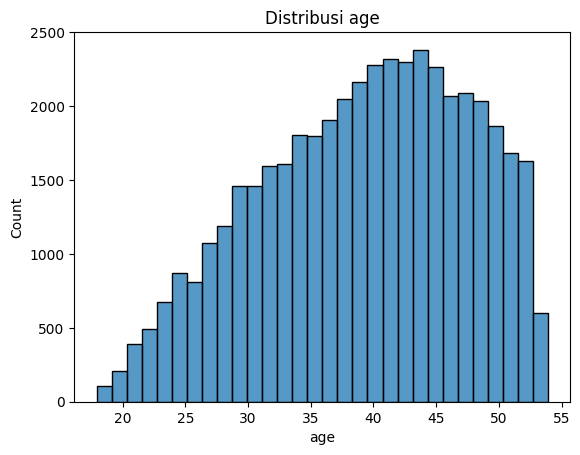

In [559]:
num_col = 'age'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [560]:
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age,,,,
"(20.769, 27.8]",4436,1091,24.5942,10.0200
"(27.8, 31.59]",4421,1095,24.7682,9.9900
"(31.59, 34.72]",4433,1046,23.5958,10.0200
"(34.72, 37.58]",4417,1101,24.9264,9.9800
"(37.58, 40.0]",4422,1089,24.6269,9.9900
"(40.0, 42.25]",4437,1082,24.3858,10.0300
"(42.25, 44.57]",4418,1053,23.8343,9.9800
"(44.57, 47.03]",4437,1053,23.7323,10.0300
"(47.03, 49.69]",4417,981,22.2096,9.9800


In [561]:
bin_1 = pd.cut(df_train['age'], bins=[-float('inf'),33,47,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['age'], bins=[-float('inf'),33,47,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
age_map_dict = {
    1: 'A1 (-inf,33]',
    2: 'A2 (33,47]',
    3: 'A3 (47,inf]'
}

df_train['age_group'] = bin_1.astype(int).map(age_map_dict)
df_test['age_group'] = bin_3.astype(int).map(age_map_dict)

In [562]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,age_group,total,bad_ratio,portion
0,"A1 (-inf,33]",11218,24.4200,24.8400
1,"A2 (33,47]",24584,24.2500,54.4400
2,"A3 (47,inf]",9352,23.3400,20.7100


### age_low and age_high

In [563]:
df_train['age_low'] = np.where(df_train['age'] <= 32, df_train['age'], 32)

df_train['age_high'] = np.where(df_train['age'] > 32, df_train['age'], 32)

df_test['age_low'] = np.where(df_test['age'] <= 32, df_test['age'], 32)

df_test['age_high'] = np.where(df_test['age'] > 32, df_test['age'], 32)

In [564]:
num_col = 'age_low'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_low,,,,
"(24.499, 29.33]",4298,1056,24.5696,10.0200
"(29.33, 32.0]",38602,9273,24.0221,89.9800


In [565]:
bin_1 = pd.cut(df_train['age_low'], bins=[-float('inf'),29.35,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['age_low'], bins=[-float('inf'),29.35,float('inf')], labels=[1,2])

# lalu pakai map untuk memberi label lebih deskriptif
age_low_map_dict = {
    1: 'A1L (-inf,29.35]',
    2: 'A2L (29.35, inf]'
}

df_train['age_low_group'] = bin_1.astype(int).map(age_low_map_dict)
df_test['age_low_group'] = bin_3.astype(int).map(age_low_map_dict)

In [566]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_low_group,total,bad_ratio,portion
0,"A1L (-inf,29.35]",6574,24.6000,14.5600
1,"A2L (29.35, inf]",38580,24.0200,85.4400


In [567]:
num_col = 'age_high'
low = df_train[num_col].quantile(0.05)
high = df_train[num_col].quantile(0.95)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
age_high,,,,
"(31.999, 34.14]",12881,3127,24.2761,30.0200
"(34.14, 36.96]",4289,1086,25.3206,10.0000
"(36.96, 39.41]",4285,1030,24.0373,9.9900
"(39.41, 41.69]",4297,1061,24.6916,10.0200
"(41.69, 43.937]",4279,1034,24.1645,9.9700
"(43.937, 46.13]",4297,1027,23.9004,10.0200
"(46.13, 48.71]",4296,950,22.1136,10.0100
"(48.71, 51.49]",4278,1024,23.9364,9.9700


In [568]:
bin_1 = pd.cut(df_train['age_high'], bins=[-float('inf'),36.9,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['age_high'], bins=[-float('inf'),36.9,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
age_high_map_dict = {
    1: 'A1H (-inf,36.9]',
    2: 'A2H (36.9,inf]'
}

df_train['age_high_group'] = bin_1.astype(int).map(age_high_map_dict)
df_test['age_high_group'] = bin_3.astype(int).map(age_high_map_dict)

In [569]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('age_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,age_high_group,total,bad_ratio,portion
0,"A1H (-inf,36.9]",17062,24.5400,37.7900
1,"A2H (36.9,inf]",28092,23.8400,62.2100


## Plafond

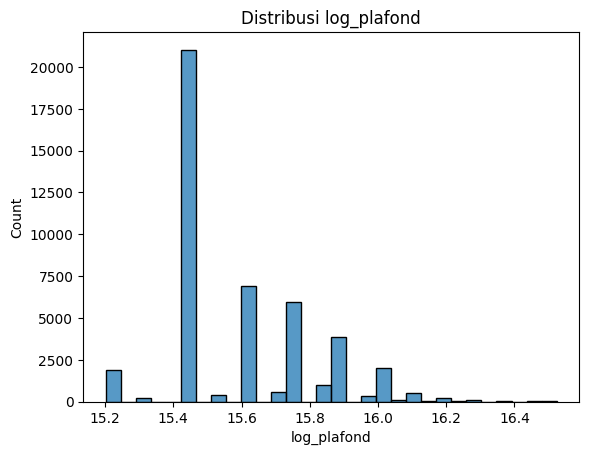

In [570]:
df_train['log_plafond'] = np.log1p(df_train['Plafond'])
df_test['log_plafond'] = np.log1p(df_test['Plafond'])

num_col = 'log_plafond'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [571]:
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafond,,,,
"(15.201, 15.425]",23117,5209,22.5332,51.6100
"(15.425, 15.607]",7344,1853,25.2315,16.4000
"(15.607, 15.761]",6521,1752,26.8670,14.5600
"(15.761, 15.895]",4848,1292,26.6502,10.8200
"(15.895, 16.118]",2960,688,23.2432,6.6100


In [572]:
bin_1 = pd.cut(df_train['log_plafond'], bins=[-float('inf'),15.425,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafond'], bins=[-float('inf'),15.425,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.425]',
    2: 'P2 (15.425,inf]'
}

df_train['log_plafond_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafond_group'] = bin_3.astype(int).map(tenure_map_dict)

In [573]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafond_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafond_group,total,bad_ratio,portion
0,"P1 (-inf,15.425]",23117,22.5300,51.2000
1,"P2 (15.425,inf]",22037,25.7500,48.8000


In [574]:
df_train['Plafond'].describe()

count       45,154.0000
mean     6,032,566.3286
std      1,444,913.9263
min      4,000,000.0000
25%      5,000,000.0000
50%      5,000,000.0000
75%      7,000,000.0000
max     15,000,000.0000
Name: Plafond, dtype: float64

### Plafond Low and High

In [575]:
df_train['log_plafon_low'] = np.log1p(
    np.where(df_train['Plafond'] <= 5_000_000, df_train['Plafond'], 5_000_000))
df_train['log_plafon_high'] = np.log1p(
    np.where(df_train['Plafond'] > 5_000_000, df_train['Plafond'], 5_000_000))

df_test['log_plafon_low'] = np.log1p(
    np.where(df_test['Plafond'] <= 5_000_000, df_test['Plafond'], 5_000_000))
df_test['log_plafon_high'] = np.log1p(
    np.where(df_test['Plafond'] > 5_000_000, df_test['Plafond'], 5_000_000))

In [576]:
num_col = 'log_plafon_low'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_low,,,,
"(15.201, 15.425]",45154,10884,24.1042,100.0000


In [577]:
bin_1 = pd.cut(df_train['log_plafon_low'], bins=[-float('inf'),15.3,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafon_low'], bins=[-float('inf'),15.3,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.3]',
    2: 'P2 (15.3,inf]'
}

df_train['log_plafon_low_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafon_low_group'] = bin_3.astype(int).map(tenure_map_dict)

In [578]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_low_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_low_group,total,bad_ratio,portion
0,"P1 (-inf,15.3]",1871,28.9200,4.1400
1,"P2 (15.3,inf]",43283,23.9000,95.8600


In [579]:
num_col = 'log_plafon_high'
low = df_train[num_col].quantile(0.01)
high = df_train[num_col].quantile(0.99)
df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train_no_outlier[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train_no_outlier.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
log_plafon_high,,,,
"(15.424000000000001, 15.607]",30461,7062,23.1837,68.0100
"(15.607, 15.761]",6521,1752,26.8670,14.5600
"(15.761, 15.895]",4848,1292,26.6502,10.8200
"(15.895, 16.118]",2960,688,23.2432,6.6100


In [580]:
bin_1 = pd.cut(df_train['log_plafon_high'], bins=[-float('inf'),15.607,float('inf')], labels=[1,2])
bin_3 = pd.cut(df_test['log_plafon_high'], bins=[-float('inf'),15.607,float('inf')], labels=[1,2])
# lalu pakai map untuk memberi label lebih deskriptif
tenure_map_dict = {
    1: 'P1 (-inf,15.607]',
    2: 'P2 (15.607,inf]'
}

df_train['log_plafon_high_group'] = bin_1.astype(int).map(tenure_map_dict)
df_test['log_plafon_high_group'] = bin_3.astype(int).map(tenure_map_dict)

In [581]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('log_plafon_high_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
bad_ratio_df

,log_plafon_high_group,total,bad_ratio,portion
0,"P1 (-inf,15.607]",23528,22.6800,52.1100
1,"P2 (15.607,inf]",21626,25.6500,47.8900


## max dpd L6M

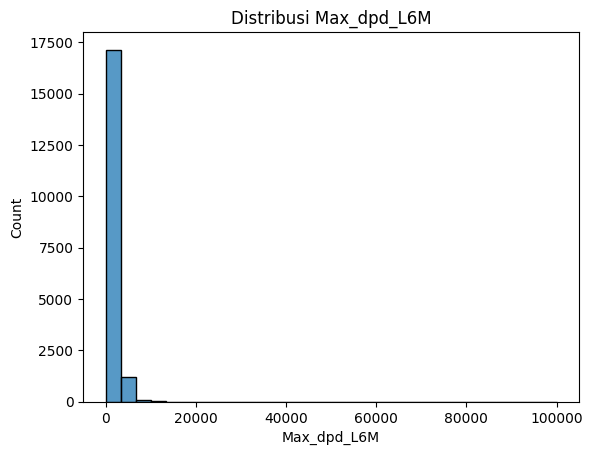

In [582]:
num_col = 'Max_dpd_L6M'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [583]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
Max_dpd_L6M,,,,
"(-0.001, 7.0]",7371,1568,21.2726,40.0600
"(7.0, 91.0]",1844,507,27.4946,10.0200
"(91.0, 212.0]",1831,602,32.8782,9.9500
"(212.0, 447.0]",1836,594,32.3529,9.9800
"(447.0, 1001.0]",1839,529,28.7656,9.9900
"(1001.0, 2401.0]",1841,530,28.7887,10.0100
"(2401.0, 99999.0]",1838,498,27.0947,9.9900


In [584]:
bin_1 = pd.cut(df_train['Max_dpd_L6M'], bins=[-float('inf'),0,15,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['Max_dpd_L6M'], bins=[-float('inf'),0,15,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'D1 (-inf,0]',
    2: 'D2 (0,15]',
    3: 'D3 (15,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['Max_dpd_L6M_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['Max_dpd_L6M_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [585]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Max_dpd_L6M_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,Max_dpd_L6M_group,total,bad_ratio,portion
0,"D1 (-inf,0]",7081,21.2500,15.6800
1,"D2 (0,15]",554,25.2700,1.2300
2,"D3 (15,inf]",10765,29.5700,23.8400
3,Missing,26754,22.6400,59.2500


## Frek_90_L6M

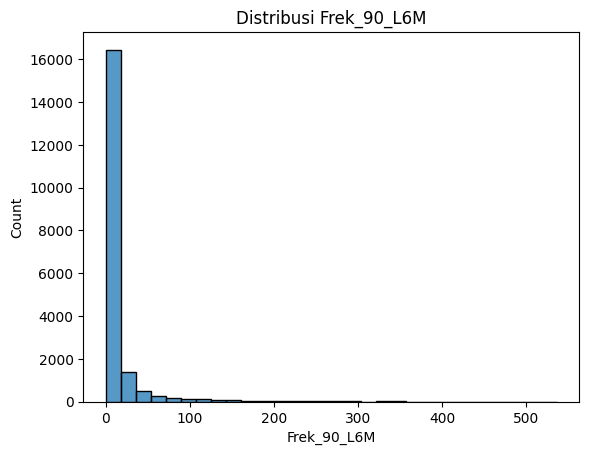

In [586]:
num_col = 'Frek_90_L6M'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [587]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
Frek_90_L6M,,,,
"(-0.001, 5.0]",12207,2848,23.3309,63.0800
"(5.0, 6.0]",1958,527,26.9152,10.1200
"(6.0, 12.0]",1740,569,32.7011,8.9900
"(12.0, 26.0]",1542,522,33.8521,7.9700
"(26.0, 536.0]",1906,514,26.9675,9.8500


In [588]:
bin_1 = pd.cut(df_train['Frek_90_L6M'], bins=[-float('inf'),0,6,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['Frek_90_L6M'], bins=[-float('inf'),0,6,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'F1 (-inf,0]',
    2: 'F2 (0,6]',
    3: 'F3 (6,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['Frek_90_L6M_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['Frek_90_L6M_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [589]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('Frek_90_L6M_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,Frek_90_L6M_group,total,bad_ratio,portion
0,"F1 (-inf,0]",10150,21.8800,22.4800
1,"F2 (0,6]",4015,28.7400,8.8900
2,"F3 (6,inf]",5188,30.9400,11.4900
3,Missing,25801,22.8800,57.1400


## total dpd last 24 months

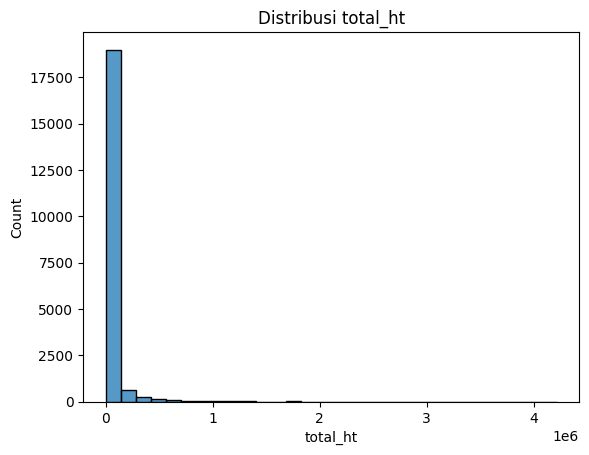

In [590]:
num_col = 'total_ht'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [591]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
total_ht,,,,
"(-0.001, 10.0]",6098,1216,19.9410,30.1000
"(10.0, 164.0]",2006,461,22.9811,9.9000
"(164.0, 968.5]",2025,544,26.8642,10.0000
"(968.5, 4192.4]",2026,585,28.8746,10.0000
"(4192.4, 10286.9]",2025,602,29.7284,10.0000
"(10286.9, 30311.4]",2026,621,30.6515,10.0000
"(30311.4, 87911.4]",2026,576,28.4304,10.0000
"(87911.4, 4215132.0]",2026,552,27.2458,10.0000


In [592]:
bin_1 = pd.cut(df_train['total_ht'], bins=[-float('inf'),10,180,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['total_ht'], bins=[-float('inf'),10,180,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'H1 (-inf,10]',
    2: 'H2 (10,180]',
    3: 'H3 (180,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['total_ht_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['total_ht_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [593]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('total_ht_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,total_ht_group,total,bad_ratio,portion
0,"H1 (-inf,10]",6098,19.9400,13.5000
1,"H2 (10,180]",2112,23.0600,4.6800
2,"H3 (180,inf]",12048,28.6700,26.6800
3,Missing,24896,23.0000,55.1400


## avg_kol_24

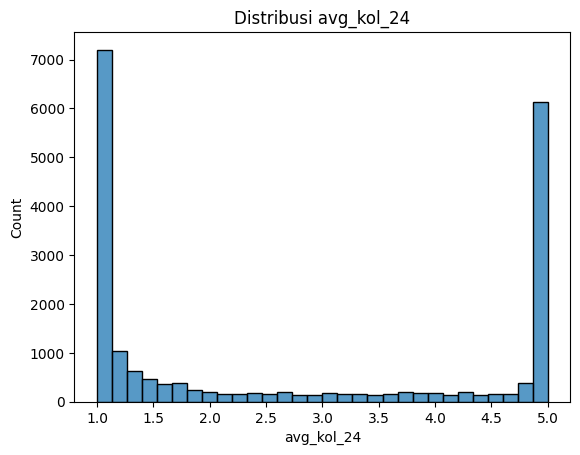

In [594]:
num_col = 'avg_kol_24'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [595]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
avg_kol_24,,,,
"(0.999, 1.042]",6071,1212,19.9638,30.0500
"(1.042, 1.25]",2149,475,22.1033,10.6400
"(1.25, 1.833]",1935,543,28.0620,9.5800
"(1.833, 3.417]",1973,560,28.3832,9.7600
"(3.417, 4.917]",2098,604,28.7893,10.3800
"(4.917, 5.0]",5980,1752,29.2977,29.6000


In [596]:
bin_1 = pd.cut(df_train['avg_kol_24'], bins=[-float('inf'),1.042,1.25,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['avg_kol_24'], bins=[-float('inf'),1.042,1.25,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'K1 (-inf,1.042]',
    2: 'K2 (1.042,1.25]',
    3: 'K3 (1.25,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['avg_kol_24_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['avg_kol_24_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [597]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('avg_kol_24_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,avg_kol_24_group,total,bad_ratio,portion
0,"K1 (-inf,1.042]",6071,19.9600,13.4500
1,"K2 (1.042,1.25]",2149,22.1000,4.7600
2,"K3 (1.25,inf]",11986,28.8600,26.5400
3,Missing,24948,23.0000,55.2500


## max kol L6M

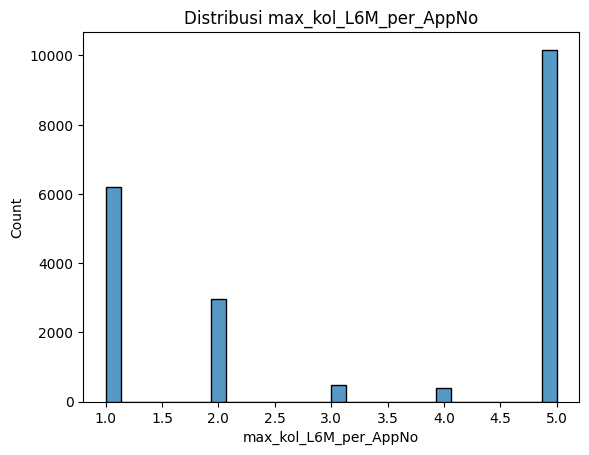

In [598]:
num_col = 'max_kol_L6M_per_AppNo'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [599]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
max_kol_L6M_per_AppNo,,,,
"(0.999, 2.0]",9169,1935,21.1037,45.3800
"(2.0, 5.0]",11037,3211,29.0931,54.6200


In [600]:
bin_1 = pd.cut(df_train['max_kol_L6M_per_AppNo'], bins=[-float('inf'),1,2,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['max_kol_L6M_per_AppNo'], bins=[-float('inf'),1,2,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'K1 (-inf,1]',
    2: 'K2 (1,2]',
    3: 'K3 (2,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['max_kol_L6M_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['max_kol_L6M_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [601]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('max_kol_L6M_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,max_kol_L6M_group,total,bad_ratio,portion
0,"K1 (-inf,1]",6208,19.8900,13.7500
1,"K2 (1,2]",2961,23.6400,6.5600
2,"K3 (2,inf]",11037,29.0900,24.4400
3,Missing,24948,23.0000,55.2500


## kol_trend

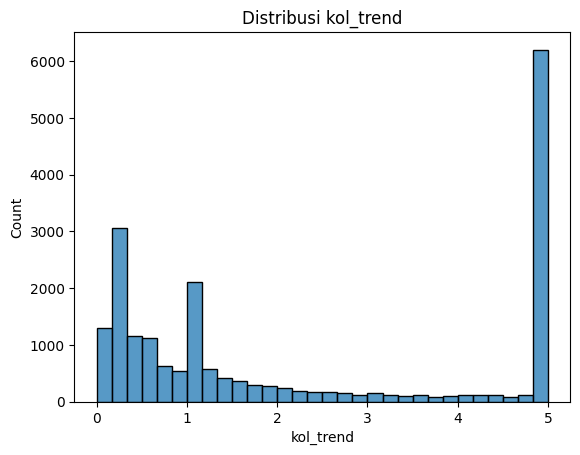

In [602]:
num_col = 'kol_trend'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [603]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
kol_trend,,,,
"(-0.001, 0.22]",2212,434,19.6203,10.9200
"(0.22, 0.303]",1887,400,21.1977,9.3100
"(0.303, 0.583]",1987,496,24.9623,9.8100
"(0.583, 1.0]",2536,561,22.1215,12.5200
"(1.0, 1.223]",1509,373,24.7184,7.4500
"(1.223, 2.257]",2024,535,26.4328,9.9900
"(2.257, 4.92]",2045,589,28.8020,10.0900
"(4.92, 5.0]",6058,1769,29.2011,29.9000


In [604]:
bin_1 = pd.cut(df_train['kol_trend'], bins=[-float('inf'),0.22,4.92,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['kol_trend'], bins=[-float('inf'),0.22,4.92,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'K1 (-inf,0.22]',
    2: 'K2 (0.22,4.92]',
    3: 'K3 (4.92,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['kol_trend_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['kol_trend_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [605]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('kol_trend_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,kol_trend_group,total,bad_ratio,portion
0,"K1 (-inf,0.22]",2212,19.6200,4.9000
1,"K2 (0.22,4.92]",11988,24.6400,26.5500
2,"K3 (4.92,inf]",6058,29.2000,13.4200
3,Missing,24896,23.0000,55.1400


## avg_sukuBunga

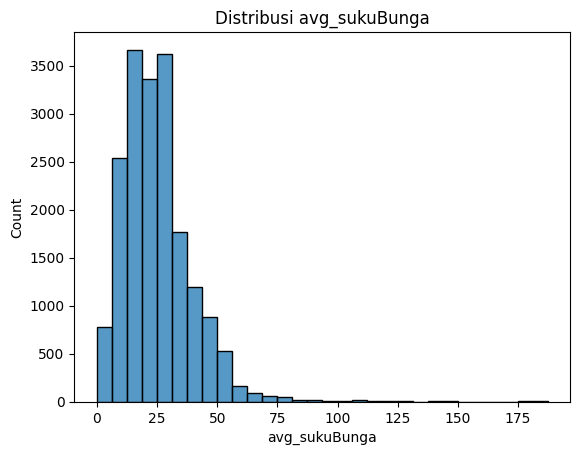

In [606]:
num_col = 'avg_sukuBunga'
sns.histplot(df_train[num_col], bins=30)
plt.title(f'Distribusi {num_col}')
plt.show()

In [607]:
#low = df_train[num_col].quantile(0.01)
#high = df_train[num_col].quantile(0.99)
#df_train_no_outlier = df_train[(df_train[num_col] >= low) & (df_train[num_col] <= high)]

bins = pd.qcut(df_train[num_col], q=10, duplicates='drop')
bad_ratio = (
    df_train.groupby(bins, observed=False)['flag_30_12MoB']
    .agg(['count', 'sum'])
    .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
)
bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
bad_ratio

,count,sum,bad_ratio,portion
avg_sukuBunga,,,,
"(-0.001, 10.0]",2058,420,20.4082,10.9700
"(10.0, 12.99]",1696,425,25.0590,9.0400
"(12.99, 15.256]",1876,411,21.9083,10.0000
"(15.256, 20.0]",2187,527,24.0969,11.6500
"(20.0, 22.88]",1567,410,26.1646,8.3500
"(22.88, 26.13]",1876,508,27.0789,10.0000
"(26.13, 30.0]",2331,670,28.7430,12.4200
"(30.0, 34.899]",1422,431,30.3094,7.5800
"(34.899, 43.455]",1877,575,30.6340,10.0000


In [608]:
bin_1 = pd.cut(df_train['avg_sukuBunga'], bins=[-float('inf'),10,30,float('inf')], labels=[1,2,3])
bin_3 = pd.cut(df_test['avg_sukuBunga'], bins=[-float('inf'),10,30,float('inf')], labels=[1,2,3])
# lalu pakai map untuk memberi label lebih deskriptif
map_dict = {
    1: 'K1 (-inf,10]',
    2: 'K2 (10,30]',
    3: 'K3 (30,inf]',
    np.nan: 'Missing'   # tambahkan label khusus untuk NaN
}

# Terapkan mapping langsung, pd.cut NaN akan tetap NaN
df_train['avg_sukuBunga_group'] = bin_1.map(lambda x: map_dict.get(x, 'Missing'))
df_test['avg_sukuBunga_group'] = bin_3.map(lambda x: map_dict.get(x, 'Missing'))

In [609]:
# df_train['flag_90'] sudah menjadi target
bad_ratio_df = (
    df_train.groupby('avg_sukuBunga_group', observed=True)['flag_30_12MoB']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'bad_ratio'})
    .reset_index()
)

bad_ratio_df['bad_ratio'] = (bad_ratio_df['bad_ratio'] * 100).round(2)
bad_ratio_df['portion'] = ((bad_ratio_df['total']/bad_ratio_df['total'].sum()) * 100).round(2)
#bad_ratio_df = bad_ratio_df.sort_values('tenure_buss_group', ascending=False)
bad_ratio_df

,avg_sukuBunga_group,total,bad_ratio,portion
0,"K1 (-inf,10]",2058,20.4100,4.5600
1,"K2 (10,30]",11533,25.5900,25.5400
2,"K3 (30,inf]",5176,29.4400,11.4600
3,Missing,26387,22.7000,58.4400


## WoE

In [611]:
df_train.columns

Index(['Debtor Marriage Status', 'age', 'Educational Status',
       'provinsi_domisili', 'Plafond', 'SektorEkonomi_Kategori',
       'range_revenue', 'flag_30_12MoB', 'tenor_days', 'account_age_days',
       'days_since_last_update', 'days_past_maturity',
       'days_since_last_restruktur', 'avg_sukuBunga', 'worst_dpd_24',
       'sum_dpd_24', 'count_dpd_gt30', 'count_dpd_gt90', 'worst_kol_24',
       'avg_kol_24', 'kol_volatility', 'kol_trend', 'total_ht', 'ht_last3',
       'jml_fasilitas_aktif_12bulan', 'jml_aktif_utilisasi_90',
       'jml_dpd3M_gt30', 'outstanding_per_fasilitas', 'max_kol_L6M_per_AppNo',
       'Max_dpd_L6M', 'Frek_90_L6M', 'sector_group', 'marital_group',
       'edu_group', 'provinsi_group', 'age_group', 'age_low', 'age_high',
       'age_low_group', 'age_high_group', 'log_plafond', 'log_plafond_group',
       'log_plafon_low', 'log_plafon_high', 'log_plafon_low_group',
       'log_plafon_high_group', 'Max_dpd_L6M_group', 'Frek_90_L6M_group',
       'total_ht_

In [612]:
df_train = df_train[['sector_group', 'marital_group',
       'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group', 'log_plafon_high_group',
                     'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group','kol_trend_group',
       'avg_sukuBunga_group',
                     'flag_30_12MoB']].copy()

df_test = df_test[['sector_group', 'marital_group',
       'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group', 'log_plafon_high_group',
                     'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group','kol_trend_group',
       'avg_sukuBunga_group', 
                   'flag_30_12MoB']].copy()

In [616]:
df_train.columns

Index(['sector_group', 'marital_group', 'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group',
       'log_plafon_high_group', 'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group', 'kol_trend_group', 'avg_sukuBunga_group',
       'flag_30_12MoB'],
      dtype='object')

In [617]:
categorical_cols = ['sector_group', 'marital_group', 'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group',
       'log_plafon_high_group', 'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group', 'kol_trend_group',
       'avg_sukuBunga_group']

df_train[categorical_cols] = df_train[categorical_cols].astype('category')
df_test[categorical_cols] = df_test[categorical_cols].astype('category')

In [618]:
# Pisahkan X dan y
X_train = df_train[['sector_group', 'marital_group', 'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group',
       'log_plafon_high_group', 'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group', 'kol_trend_group',
       'avg_sukuBunga_group']]
y_train = df_train['flag_30_12MoB']

X_test = df_test[['sector_group', 'marital_group', 'edu_group', 'age_group',
       'age_low_group', 'log_plafond_group', 'log_plafon_low_group',
       'log_plafon_high_group', 'provinsi_group', 'total_ht_group',
       'Max_dpd_L6M_group', 'Frek_90_L6M_group', 'avg_kol_24_group',
       'max_kol_L6M_group', 'kol_trend_group',
       'avg_sukuBunga_group']]
y_test = df_test['flag_30_12MoB']

In [619]:
def hitung_woe_iv(df, target='flag_30_12MoB'):
    """
    Hitung Weight of Evidence (WOE) dan Information Value (IV) untuk setiap bin dari setiap variabel kategorik.
    
    Parameters
    ----------
    df : DataFrame
        Data dengan kolom target dan variabel independen yang sudah di-binning.
    target : str
        Nama kolom target (1 = bad, 0 = good)
    
    Returns
    -------
    woe_df : DataFrame
        Tabel berisi variabel, kategori/bin, jumlah good, jumlah bad, distribusi, WOE, dan kontribusi IV.
    iv_summary : DataFrame
        Ringkasan IV per variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_list = []

    # total good dan bad keseluruhan
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum'])
        temp = temp.rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # distribusi
        temp['bad_dist'] = temp['bad'] / total_bad
        temp['good_dist'] = temp['good'] / total_good

        # WOE dengan perlindungan dari pembagian nol
        epsilon = 1e-6
        temp['woe'] = np.log((temp['good_dist'] + epsilon) / (temp['bad_dist'] + epsilon))

        # Kontribusi IV per bin
        temp['iv_contrib'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        # Simpan IV per variabel
        iv = temp['iv_contrib'].sum()
        iv_list.append({'variabel': col, 'IV': iv})

        # Tambahkan nama variabel dan kategori
        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

    # Gabungkan semua variabel
    woe_df = pd.concat(hasil, ignore_index=True)
    woe_df = woe_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_contrib']]

    # Ringkasan IV per variabel
    iv_summary = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

    return woe_df, iv_summary


In [620]:
# ada tambahan epsilon

def hitung_woe_iv_epsilon(df, target='flag_30_12MoB', epsilon=0.5):
    """
    Hitung WOE dan IV dengan smoothing untuk mengurangi efek target imbalance.
    
    Parameters
    ----------
    df : DataFrame
        Dataset dengan kolom target dan variabel independen (kategori/bin).
    target : str
        Nama kolom target (1=bad, 0=good)
    epsilon : float
        Nilai smoothing untuk mencegah divisi nol
    
    Returns
    -------
    iv_df : DataFrame
        Tabel WOE dan IV untuk tiap bin tiap variabel
    iv_summary : DataFrame
        Ringkasan IV tiap variabel
    """
    
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    hasil = []
    iv_summary = []

    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    for col in cat_cols:
        temp = df.groupby(col, observed=True)[target].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'bad'})
        temp['good'] = temp['total'] - temp['bad']

        # smoothing distribusi
        temp['good_dist'] = (temp['good'] + epsilon) / (total_good + epsilon * len(temp))
        temp['bad_dist'] = (temp['bad'] + epsilon) / (total_bad + epsilon * len(temp))

        # WOE
        temp['woe'] = np.log(temp['good_dist'] / temp['bad_dist'])

        # IV per bin
        temp['iv_bin'] = (temp['good_dist'] - temp['bad_dist']) * temp['woe']

        temp['variabel'] = col
        temp['kategori'] = temp.index.astype(str)
        hasil.append(temp.reset_index(drop=True))

        iv_summary.append({
            'variabel': col,
            'IV': temp['iv_bin'].sum()
        })

    iv_df = pd.concat(hasil, ignore_index=True)
    iv_df = iv_df[['variabel','kategori','total','good','bad','good_dist','bad_dist','woe','iv_bin']]

    iv_summary = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)

    return iv_df, iv_summary

In [621]:
woe_result, iv_summary = hitung_woe_iv(df_train)

# Lihat WOE tiap bin
woe_result

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_contrib
0,sector_group,S1,22835,16992,5843,0.4958,0.5368,-0.0795,0.0033
1,sector_group,S2,15279,11714,3565,0.3418,0.3275,0.0426,0.0006
2,sector_group,S3,7040,5564,1476,0.1624,0.1356,0.1800,0.0048
3,marital_group,M1,2135,1546,589,0.0451,0.0541,-0.1820,0.0016
4,marital_group,M2,43017,32722,10295,0.9548,0.9459,0.0094,0.0001
5,marital_group,M3,2,2,0,0.0001,0.0000,4.0836,0.0002
6,edu_group,E1,42331,32041,10290,0.9350,0.9454,-0.0111,0.0001
7,edu_group,E2,2823,2229,594,0.0650,0.0546,0.1754,0.0018
8,age_group,"A1 (-inf,33]",11218,8479,2739,0.2474,0.2517,-0.0170,0.0001
9,age_group,"A2 (33,47]",24584,18622,5962,0.5434,0.5478,-0.0080,0.0000


In [622]:
# Lihat IV per variabel
iv_summary

,variabel,IV
0,provinsi_group,0.1183
1,Max_dpd_L6M_group,0.0278
2,max_kol_L6M_group,0.0269
3,avg_kol_24_group,0.0269
4,Frek_90_L6M_group,0.0262
5,total_ht_group,0.0253
6,avg_sukuBunga_group,0.0163
7,kol_trend_group,0.0152
8,sector_group,0.0087
9,log_plafond_group,0.0077


In [623]:
woe_result_sm, iv_summary_sm = hitung_woe_iv_epsilon(df_train)

# Lihat WOE tiap bin
woe_result_sm

,variabel,kategori,total,good,bad,good_dist,bad_dist,woe,iv_bin
0,sector_group,S1,22835,16992,5843,0.4958,0.5368,-0.0794,0.0033
1,sector_group,S2,15279,11714,3565,0.3418,0.3275,0.0426,0.0006
2,sector_group,S3,7040,5564,1476,0.1624,0.1356,0.1799,0.0048
3,marital_group,M1,2135,1546,589,0.0451,0.0542,-0.1824,0.0016
4,marital_group,M2,43017,32722,10295,0.9548,0.9458,0.0095,0.0001
5,marital_group,M3,2,2,0,0.0001,0.0000,0.4626,0.0000
6,edu_group,E1,42331,32041,10290,0.9349,0.9454,-0.0111,0.0001
7,edu_group,E2,2823,2229,594,0.0651,0.0546,0.1749,0.0018
8,age_group,"A1 (-inf,33]",11218,8479,2739,0.2474,0.2517,-0.0170,0.0001
9,age_group,"A2 (33,47]",24584,18622,5962,0.5434,0.5477,-0.0080,0.0000


In [624]:
iv_summary_sm

,variabel,IV
0,provinsi_group,0.1183
1,Max_dpd_L6M_group,0.0278
2,max_kol_L6M_group,0.0269
3,avg_kol_24_group,0.0268
4,Frek_90_L6M_group,0.0262
5,total_ht_group,0.0253
6,avg_sukuBunga_group,0.0163
7,kol_trend_group,0.0152
8,sector_group,0.0087
9,log_plafond_group,0.0077


In [761]:
X_woe = X_train.copy()  # buat salinan agar aman

for col in X_train.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe[col] = X_train[col].map(woe_map)

X_woe_test = X_test.copy()

for col in X_test.columns:
    # ambil subset lookup untuk kolom tertentu
    woe_map = woe_result_sm[woe_result_sm['variabel'] == col].set_index('kategori')['woe'].to_dict()
    # map kategori ke WOE
    X_woe_test[col] = X_test[col].map(woe_map)

In [762]:
X_woe = X_woe.drop(columns=['total_ht_group','avg_kol_24_group','log_plafon_high_group',
                            'log_plafon_low_group',
                            'edu_group','marital_group','age_group','age_low_group'])
X_woe_test = X_woe_test.drop(columns=['total_ht_group','avg_kol_24_group','log_plafon_high_group',
                                      'log_plafon_low_group','edu_group','marital_group','age_group',
                                      'age_low_group'])

## Multikolinearitas (VIF) 

In [763]:
def hitung_vif(df_woe):
    """
    Menghitung Variance Inflation Factor (VIF) untuk dataset WOE.
    
    Parameters
    ----------
    df_woe : DataFrame
        DataFrame berisi variabel independen yang sudah diubah menjadi WOE.
    
    Returns
    -------
    DataFrame
        Tabel VIF untuk setiap variabel.
    """
    
    # tambah konstanta agar kompatibel
    X = df_woe.copy()
    #X = X.assign(const=1)

    vif_data = []
    
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append((X.columns[i], vif))
    
    vif_df = pd.DataFrame(vif_data, columns=['variabel', 'VIF'])

    return vif_df

In [764]:
vif_result = hitung_vif(X_woe)
vif_result

,variabel,VIF
0,sector_group,1.0031
1,log_plafond_group,1.0053
2,provinsi_group,1.0083
3,Max_dpd_L6M_group,4.7703
4,Frek_90_L6M_group,4.9061
5,max_kol_L6M_group,3.8459
6,kol_trend_group,2.3036
7,avg_sukuBunga_group,1.2830


## Training model

In [765]:
X_woe = X_woe.astype('float64')
X_woe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45154 entries, 46161 to 43703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sector_group         45154 non-null  float64
 1   log_plafond_group    45154 non-null  float64
 2   provinsi_group       45154 non-null  float64
 3   Max_dpd_L6M_group    45154 non-null  float64
 4   Frek_90_L6M_group    45154 non-null  float64
 5   max_kol_L6M_group    45154 non-null  float64
 6   kol_trend_group      45154 non-null  float64
 7   avg_sukuBunga_group  45154 non-null  float64
dtypes: float64(8)
memory usage: 3.1 MB


In [747]:
#X_res.info()

In [766]:
# Gabungkan X dan y untuk analisis korelasi
df_corr = X_woe.copy()
df_corr['target'] = y_train

# Hitung korelasi Pearson
corr_with_target = df_corr.corr()['target'].sort_values(ascending=False)

# Tampilkan hasilnya
print("Korelasi variabel independen terhadap target:")
print(corr_with_target)

# Jika ingin tanpa target itu sendiri
#corr_with_target = corr_with_target.drop('target')

Korelasi variabel independen terhadap target:
target                 1.0000
log_plafond_group     -0.0376
sector_group          -0.0395
kol_trend_group       -0.0533
avg_sukuBunga_group   -0.0553
max_kol_L6M_group     -0.0709
Frek_90_L6M_group     -0.0711
Max_dpd_L6M_group     -0.0727
provinsi_group        -0.1454
Name: target, dtype: float64


### Scikit learn

### tanpa smote

In [767]:
X_woe.head()

,sector_group,log_plafond_group,provinsi_group,Max_dpd_L6M_group,Frek_90_L6M_group,max_kol_L6M_group,kol_trend_group,avg_sukuBunga_group
46161,-0.0794,-0.0881,0.3208,-0.2790,-0.3439,-0.2561,-0.2614,-0.0794
58778,0.0426,-0.0881,0.3208,-0.2790,-0.3439,-0.2561,-0.2614,-0.0794
43895,-0.0794,-0.0881,-0.3254,0.1626,0.1256,0.2458,-0.0291,-0.2731
25245,0.1799,-0.0881,-0.3254,0.0821,0.0680,0.0614,0.0612,0.0786
31132,-0.0794,0.0879,0.2324,0.0821,0.0680,0.0614,0.0612,0.0786


In [750]:
# model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_woe, y_train)
# coef = model.coef_[0]      # koefisien tiap variabel
# intercept = model.intercept_[0]   # konstanta (intercept)

# coef_df = pd.DataFrame({
#     'Variable': X_woe.columns,
#     'Coefficient': coef
# })
# coef_df.loc[len(coef_df)] = ['Intercept', intercept]
# coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# coef_df

In [751]:
# y_prob_train = model.predict_proba(X_woe)[:,1]
# y_prob_test = model.predict_proba(X_woe_test)[:,1]
# df_train_slearn = pd.DataFrame({ 'proba': y_prob_train, 'y_res': y_train })
# df_test_slearn = pd.DataFrame({ 'proba': y_prob_test, 'y_res': y_test })

In [752]:
# num_col = 'proba'
# #low = df_train_slearn[num_col].quantile(0.05)
# #high = df_train_slearn[num_col].quantile(0.95)
# #df_train_no_outlier = df_train_slearn[(df_train_slearn[num_col] >= low) & (df_train_slearn[num_col] <= high)]

# bins = pd.qcut(df_train_slearn[num_col], q=10, duplicates='drop')
# bad_ratio = (
#     df_train_slearn.groupby(bins, observed=False)['y_res']
#     .agg(['count', 'sum'])
#     .assign(bad_ratio=lambda x: (x['sum'] / x['count']) * 100)
# )
# bad_ratio['portion'] = ((bad_ratio['count']/bad_ratio['count'].sum()) * 100).round(2)
# bad_ratio

### sklearn dengan p value

In [768]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm

def logistic_regression_with_pvalues(X, y):
    """
    Logistic Regression tanpa penalti (sklearn) + 
    perhitungan SE, z-score, dan p-value yang efisien 
    (tanpa membuat matriks diagonal besar).
    """

    # --- Fit logistic regression sklearn ---
    try:
        model = LogisticRegression(penalty='none', solver='lbfgs', max_iter=5000)
        model.fit(X, y)
    except:
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
        model.fit(X, y)

    # --- Prediksi probabilitas ---
    p = model.predict_proba(X)[:, 1]

    # --- Design matrix (dengan intercept) ---
    X_design = np.column_stack([np.ones(X.shape[0]), X])

    # --- Weight vector (bukan matriks!) ---
    w = p * (1 - p)          # shape (n,)

    # ---------------------------------------------
    # Fisher Information: Xᵀ W X
    #
    # Di Python:
    #     info = X_design.T @ (w * X_design)
    #
    # Ini setara dengan Xᵀ W X tanpa bikin W besar.
    # ---------------------------------------------
    info_mat = X_design.T @ (w[:, None] * X_design)

    # --- Variance-covariance matrix ---
    cov_mat = np.linalg.inv(info_mat)

    # --- Standard Error ---
    se = np.sqrt(np.diag(cov_mat))

    # --- Parameter (intercept + koef) ---
    params = np.concatenate([model.intercept_, model.coef_.flatten()])

    # --- z-score dan p-value ---
    z = params / se
    p_values = 2 * (1 - norm.cdf(np.abs(z)))

    # --- Pseudo R² McFadden ---
    eps = 1e-10
    ll_full = np.sum(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
    p_null = np.mean(y)
    ll_null = np.sum(y*np.log(p_null+eps) + (1-y)*np.log(1-p_null+eps))
    r_square = 1 - ll_full/ll_null

    # --- Susun output ---
    names = ["Intercept"] + list(X.columns)
    result = pd.DataFrame({
        "Coefficient": params,
        "Std Error": se,
        "z-score": z,
        "p-value": p_values
    }, index=names)

    return result, model, r_square


In [769]:
result, model, r_square = logistic_regression_with_pvalues(X_woe, y_train)

In [770]:
r_square

np.float64(0.0270692369890404)

In [771]:
print(result)

                     Coefficient  Std Error   z-score  p-value
Intercept                -1.1477     0.0112 -102.1578   0.0000
sector_group             -1.2629     0.1222  -10.3353   0.0000
log_plafond_group        -0.9166     0.1273   -7.2034   0.0000
provinsi_group           -0.9874     0.0329  -29.9768   0.0000
Max_dpd_L6M_group        -0.3986     0.1458   -2.7337   0.0063
Frek_90_L6M_group        -0.2441     0.1514   -1.6121   0.1069
max_kol_L6M_group        -0.3658     0.1346   -2.7177   0.0066
kol_trend_group           0.2273     0.1373    1.6550   0.0979
avg_sukuBunga_group      -0.4438     0.0992   -4.4749   0.0000


In [791]:
X_woe_2 = X_woe.drop(columns=['kol_trend_group'])
X_woe_test_2 = X_woe_test.drop(columns=['kol_trend_group'])

result_2, model_2, r_square_2 = logistic_regression_with_pvalues(X_woe_2, y_train)
print(result_2)

                     Coefficient  Std Error   z-score  p-value
Intercept                -1.1475     0.0112 -102.1570   0.0000
sector_group             -1.2448     0.1221  -10.1913   0.0000
log_plafond_group        -0.9084     0.1272   -7.1411   0.0000
provinsi_group           -0.9863     0.0329  -29.9458   0.0000
Max_dpd_L6M_group        -0.3577     0.1456   -2.4561   0.0140
Frek_90_L6M_group        -0.2048     0.1475   -1.3882   0.1651
max_kol_L6M_group        -0.3300     0.1298   -2.5419   0.0110
avg_sukuBunga_group      -0.4079     0.0972   -4.1976   0.0000


In [792]:
r_square_2

np.float64(0.026972330828776703)

In [774]:
# --- Probabilitas Training & Testing ---
y_prob_train = model.predict_proba(X_woe)[:, 1]
y_prob_test  = model.predict_proba(X_woe_test)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn = pd.DataFrame({
    'proba': y_prob_train,
    'y_res': y_train
})

df_test_slearn = pd.DataFrame({
    'proba': y_prob_test,
    'y_res': y_test
})


In [775]:
def make_decile_table(df, prob_col='proba', target_col='y_res', q=10):
    """
    Menghitung count, bad, bad_ratio (%), portion (%), KS value, ROC contribution, dan Gini.
    prob_col  : kolom probabilitas
    target_col: kolom target (1 = bad)
    q         : jumlah bins (default 10 = decile)
    """

    # Buat bins berdasarkan probabilitas
    bins = pd.qcut(df[prob_col], q=q, duplicates='drop')

    # Hitung count per bin
    tbl = (
        df.groupby(bins, observed=False)[target_col]
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'bad'})
    )

    tbl['good'] = tbl['count'] - tbl['bad']
    tbl['bad_ratio'] = (tbl['bad'] / tbl['count']) * 100
    tbl['portion'] = (tbl['count'] / tbl['count'].sum()) * 100

    # Hitung cumulative distribution
    tbl['cum_bad'] = tbl['bad'].cumsum() / tbl['bad'].sum()
    tbl['cum_good'] = tbl['good'].cumsum() / tbl['good'].sum()

    # KS Value per bin
    tbl['ks'] = (tbl['cum_bad'] - tbl['cum_good']).abs()

    # ROC AUC approximation (trapezoid)
    # FPR = cum_good, TPR = cum_bad
    tbl_shift = tbl.shift(1).fillna(0)

    tbl['roc_contrib'] = (
        (tbl['cum_good'] - tbl_shift['cum_good']) *
        (tbl['cum_bad'] + tbl_shift['cum_bad']) / 2
    )

    # Hitung AUC & Gini
    auc = tbl['roc_contrib'].sum()
    gini = 2 * auc - 1

    tbl = tbl.round({
        'bad_ratio': 2,
        'portion': 2,
        'ks': 4,
        'roc_contrib': 6
    })

    # Tambahkan nilai AUC & Gini untuk referensi
    tbl.attrs['AUC'] = auc
    tbl.attrs['Gini'] = gini

    return tbl


In [776]:
train_decile = make_decile_table(df_train_slearn, prob_col='proba', target_col='y_res', q=10)
print(train_decile)
print("AUC :", train_decile.attrs['AUC'])
print("Gini:", train_decile.attrs['Gini'])

                 count   bad  good  bad_ratio  portion  cum_bad  cum_good  \
proba                                                                       
(0.0798, 0.154]   5000   683  4317    13.6600  11.0700   0.0628    0.1260   
(0.154, 0.177]    5759   893  4866    15.5100  12.7500   0.1448    0.2680   
(0.177, 0.19]     3706   730  2976    19.7000   8.2100   0.2119    0.3548   
(0.19, 0.202]     4040   873  3167    21.6100   8.9500   0.2921    0.4472   
(0.202, 0.232]    4080   875  3205    21.4500   9.0400   0.3725    0.5407   
(0.232, 0.259]    4589  1100  3489    23.9700  10.1600   0.4735    0.6425   
(0.259, 0.289]    4879  1348  3531    27.6300  10.8100   0.5974    0.7456   
(0.289, 0.313]    4070  1222  2848    30.0200   9.0100   0.7097    0.8287   
(0.313, 0.337]    4536  1454  3082    32.0500  10.0500   0.8433    0.9186   
(0.337, 0.45]     4495  1706  2789    37.9500   9.9500   1.0000    1.0000   

                    ks  roc_contrib  
proba                                

In [793]:
# --- Probabilitas Training & Testing ---
y_prob_train_2 = model_2.predict_proba(X_woe_2)[:, 1]
y_prob_test_2  = model_2.predict_proba(X_woe_test_2)[:, 1]

# --- Buat dataframe evaluasi ---
df_train_slearn_2 = pd.DataFrame({
    'proba': y_prob_train_2,
    'y_res': y_train
})

df_test_slearn_2 = pd.DataFrame({
    'proba': y_prob_test_2,
    'y_res': y_test
})


In [ ]:
#df_train_slearn_2.to_excel('D:/Development/Hasil/proba channeling train sm pvalue.xlsx')
#df_test_slearn_2.to_excel('D:/Development/Hasil/proba channeling test sm pvalue.xlsx')

In [794]:
train_decile_2 = make_decile_table(df_train_slearn_2, prob_col='proba', target_col='y_res', q=10)
print(train_decile_2)
print("AUC :", train_decile_2.attrs['AUC'])
print("Gini:", train_decile_2.attrs['Gini'])

                 count   bad  good  bad_ratio  portion  cum_bad  cum_good  \
proba                                                                       
(0.0828, 0.154]   4982   680  4302    13.6500  11.0300   0.0625    0.1255   
(0.154, 0.176]    5961   937  5024    15.7200  13.2000   0.1486    0.2721   
(0.176, 0.189]    3544   684  2860    19.3000   7.8500   0.2114    0.3556   
(0.189, 0.201]    4009   877  3132    21.8800   8.8800   0.2920    0.4470   
(0.201, 0.232]    4713  1023  3690    21.7100  10.4400   0.3860    0.5547   
(0.232, 0.258]    4124   997  3127    24.1800   9.1300   0.4776    0.6459   
(0.258, 0.288]    4678  1285  3393    27.4700  10.3600   0.5956    0.7449   
(0.288, 0.314]    4232  1283  2949    30.3200   9.3700   0.7135    0.8310   
(0.314, 0.338]    4430  1417  3013    31.9900   9.8100   0.8437    0.9189   
(0.338, 0.437]    4481  1701  2780    37.9600   9.9200   1.0000    1.0000   

                    ks  roc_contrib  
proba                                

## Konversi ke Skor

In [811]:
result_2_reset = result_2.reset_index()
result_2_reset

,index,Coefficient,Std Error,z-score,p-value
0,Intercept,-1.1475,0.0112,-102.1570,0.0000
1,sector_group,-1.2448,0.1221,-10.1913,0.0000
2,log_plafond_group,-0.9084,0.1272,-7.1411,0.0000
3,provinsi_group,-0.9863,0.0329,-29.9458,0.0000
4,Max_dpd_L6M_group,-0.3577,0.1456,-2.4561,0.0140
5,Frek_90_L6M_group,-0.2048,0.1475,-1.3882,0.1651
6,max_kol_L6M_group,-0.3300,0.1298,-2.5419,0.0110
7,avg_sukuBunga_group,-0.4079,0.0972,-4.1976,0.0000


In [812]:
# Skor param
BaseScore = 600
PDO = 20

Factor = PDO / np.log(2)
Offset = BaseScore - Factor * result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values

# Merge WOE dan Coef
df_score = woe_result_sm.merge(result_2_reset, left_on='variabel', right_on='index', how="left")

# Hitung skor tiap kategori
df_score['Score_raw'] = -1 * df_score['Coefficient'] * df_score['woe'] * Factor
df_score = df_score[df_score['Score_raw'].notna()]
df_score = df_score[['variabel','kategori','woe','iv_bin','Coefficient','Score_raw']]

# Cari skor minimum
score_min = df_score['Score_raw'].min()

# Tambahkan offset agar semua positif
BaseOffset = 10
df_score['Score'] = df_score['Score_raw'] - score_min + BaseOffset

# Skor intercept ikut disesuaikan
Score_intercept = Offset - score_min + BaseOffset

print('Score intercept:', Score_intercept)
df_score

Score intercept: [653.23175627]


,variabel,kategori,woe,iv_bin,Coefficient,Score_raw,Score
0,sector_group,S1,-0.0794,0.0033,-1.2448,-2.8534,17.2676
1,sector_group,S2,0.0426,0.0006,-1.2448,1.5316,21.6526
2,sector_group,S3,0.1799,0.0048,-1.2448,6.4599,26.5809
13,log_plafond_group,"P1 (-inf,15.425]",0.0879,0.0039,-0.9084,2.3034,22.4245
14,log_plafond_group,"P2 (15.425,inf]",-0.0881,0.0039,-0.9084,-2.3088,17.8122
19,provinsi_group,P1,0.6985,0.0219,-0.9863,19.8790,40.0001
20,provinsi_group,P2,0.3208,0.0320,-0.9863,9.1287,29.2497
21,provinsi_group,P3,0.2324,0.0080,-0.9863,6.6135,26.7346
22,provinsi_group,P4,-0.3556,0.0301,-0.9863,-10.1210,10.0000
23,provinsi_group,P5,-0.3254,0.0263,-0.9863,-9.2616,10.8594


In [813]:
# sector -> tren bad turun
# log plafond -> tren bad naik
# provinsi -> tren bad naik
# max dpd l6m -> tren bad naik
# frek 90 l6m -> tren bad naik
# max kol l6m -> tren bad naik
# kol trend -> tren bad naik
# avg suku bunga -> tren bad naik

In [814]:
# Hitung minimum dan maksimum per variabel
score_range = df_score.groupby('variabel')['Score'].agg(['min','max'])

# Hitung total minimum dan maksimum
total_min = Score_intercept + score_range['min'].sum()
total_max = Score_intercept + score_range['max'].sum()

print("Skor Minimum Model:", total_min)
print("Skor Maximum Model:", total_max)

Skor Minimum Model: [768.23138953]
Skor Maximum Model: [829.99148834]


In [815]:
X_train_skor = X_woe[X_woe.columns]
X_test_skor = X_test[X_woe_test.columns]

In [816]:
def get_score(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('kategori')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score

def get_score_from_woe(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('woe')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score


In [817]:
df_result_train = get_score_from_woe(X_train_skor, df_score, Score_intercept)
df_result_test = get_score(X_test_skor, df_score, Score_intercept)

In [818]:
df_train_slearn = pd.DataFrame({ 'skor': df_result_train['Score_total'], 'y_res': y_train })
df_test_slearn = pd.DataFrame({ 'skor': df_result_test['Score_total'], 'y_res': y_test })

In [ ]:
# df_train_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling train sm pvalue.xlsx')
# df_test_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling test sm pvalue.xlsx')

## Model tuning (menggunakan platt scaling di scikit learn)

In [701]:
# calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
# calibrated_model.fit(X_woe_test, y_test)

# y_calibrated = calibrated_model.predict_proba(X_woe_test)[:, 1]

In [702]:
# df_test_cal = pd.DataFrame({ 'proba': y_calibrated, 'y_res': y_test })

In [703]:
# cal = calibrated_model.calibrated_classifiers_[0].calibrators[0]
# print("Slope (A):", cal.a_)
# print("Intercept (B):", cal.b_)

In [704]:
# prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
# prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)

# plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
# plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='After calibration')
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.legend()
# plt.xlabel('Predicted PD')
# plt.ylabel('Actual default rate')
# plt.show()

In [705]:
# brier_before = brier_score_loss(y_test, y_prob_test)
# brier_after = brier_score_loss(y_test, y_calibrated)

# print("Brier score before:", brier_before)
# print("Brier score after:", brier_after)

## Model Tuning (regresi logistik lagi)

In [706]:
logit_test_2 = np.log(y_prob_test_2/(1-y_prob_test_2))
logit_test_2 = pd.DataFrame(logit_test_2)

result_tun, model_tun, r_square_tun = logistic_regression_with_pvalues(logit_test_2, y_test)

In [707]:
result_tun

,Coefficient,Std Error,z-score,p-value
Intercept,-0.0433,0.0499,-0.8685,0.3851
0,0.9668,0.0426,22.7093,0.0000


In [708]:
y_prob_test_tun  = model_tun.predict_proba(logit_test_2)[:, 1]

# --- Buat dataframe evaluasi ---

df_test_slearn_tun = pd.DataFrame({
    'proba': y_prob_test_tun,
    'y_res': y_test
})


In [709]:
#df_test_slearn_tun.to_excel('D:/Development/Hasil/proba individual sme test sm cal pvalue.xlsx')

In [711]:
test_decile_tun = make_decile_table(df_test_slearn_tun, prob_col='proba', target_col='y_res', q=10)
print(test_decile_tun)
print("AUC :", test_decile_tun.attrs['AUC'])
print("Gini:", test_decile_tun.attrs['Gini'])

                 count  bad  good  bad_ratio  portion  cum_bad  cum_good  \
proba                                                                      
(0.0858, 0.156]   2051  287  1764    13.9900  10.6000   0.0615    0.1201   
(0.156, 0.177]    2523  395  2128    15.6600  13.0400   0.1462    0.2650   
(0.177, 0.19]     1473  270  1203    18.3300   7.6100   0.2041    0.3469   
(0.19, 0.201]     1695  366  1329    21.5900   8.7600   0.2826    0.4374   
(0.201, 0.231]    2050  449  1601    21.9000  10.5900   0.3789    0.5464   
(0.231, 0.258]    1820  476  1344    26.1500   9.4000   0.4809    0.6379   
(0.258, 0.286]    2018  535  1483    26.5100  10.4300   0.5956    0.7388   
(0.286, 0.314]    1851  566  1285    30.5800   9.5600   0.7170    0.8263   
(0.314, 0.334]    1938  597  1341    30.8000  10.0100   0.8450    0.9176   
(0.334, 0.429]    1933  723  1210    37.4000   9.9900   1.0000    1.0000   

                    ks  roc_contrib  
proba                                
(0.0858, 0.

In [712]:
brier_before = brier_score_loss(y_test, y_prob_test_2)
brier_after = brier_score_loss(y_test, y_prob_test_tun)

print("Brier score before:", brier_before)
print("Brier score after:", brier_after)

Brier score before: 0.1779275880662699
Brier score after: 0.17791582238937048


## Persamaan akhir (pakai plat scaling)

In [ ]:
# result_2_reset = result_2.reset_index()

In [ ]:
# # intercept dan slope Platt
# intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
# platt_slope = cal.a_
# platt_intercept = cal.b_

# # hitung intercept & slope akhir
# intercept_final = platt_slope * intercept_raw + platt_intercept
# coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
# coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * platt_slope

# print('Intercept akhir:', intercept_final)
# coef_df_final

## Persamaan akhir (pakai regresi logistik lagi)

In [ ]:
#result_2_reset = result_2.reset_index()

In [713]:
# intercept dan slope calibration
intercept_raw = result_2_reset[result_2_reset['index'] == 'Intercept']['Coefficient'].values
cal_slope = result_tun['Coefficient'][0]
cal_intercept = result_tun['Coefficient']['Intercept']

# hitung intercept & slope akhir
intercept_final = cal_slope * intercept_raw + cal_intercept
coef_df_final = result_2_reset[result_2_reset['index'] != 'Intercept'].copy()
coef_df_final['Coefficient_final'] = coef_df_final['Coefficient'] * cal_slope

print('Intercept akhir:', intercept_final)
coef_df_final

Intercept akhir: [-1.15281021]


,index,Coefficient,Std Error,z-score,p-value,Coefficient_final
1,sector_group,-1.2456,0.1222,-10.1970,0.0000,-1.2043
2,log_plafond_group,-0.9080,0.1272,-7.1371,0.0000,-0.8778
3,provinsi_group,-0.9869,0.0329,-29.9691,0.0000,-0.9542
4,total_ht_group,-0.2985,0.1254,-2.3804,0.0173,-0.2886
5,Max_dpd_L6M_group,-0.3514,0.1514,-2.3212,0.0203,-0.3398
6,Frek_90_L6M_group,-0.2572,0.1387,-1.8548,0.0636,-0.2487
7,avg_sukuBunga_group,-0.4039,0.0971,-4.1573,0.0000,-0.3905


## Konversi ke Skor Akhir

In [714]:
# Skor param
BaseScore = 600
PDO = 20

Factor = PDO / np.log(2)
Offset = BaseScore - Factor * intercept_final

# Merge WOE dan Coef
df_score = woe_result_sm.merge(coef_df_final, left_on='variabel', right_on='index', how="left")

# Hitung skor tiap kategori
df_score['Score_raw'] = df_score['Coefficient_final'] * df_score['woe'] * Factor
df_score = df_score[df_score['Score_raw'].notna()]
df_score = df_score[['variabel','kategori','woe','iv_bin','Coefficient_final','Score_raw']]

# Cari skor minimum
score_min = df_score['Score_raw'].min()

# Tambahkan offset agar semua positif
BaseOffset = 10
df_score['Score'] = df_score['Score_raw'] - score_min + BaseOffset

# Skor intercept ikut disesuaikan
Score_intercept = Offset - score_min + BaseOffset

print('Score intercept:', Score_intercept)
df_score

Score intercept: [662.49553876]


,variabel,kategori,woe,iv_bin,Coefficient_final,Score_raw,Score
0,sector_group,S1,-0.0794,0.0033,-1.2043,2.7604,31.9929
1,sector_group,S2,0.0426,0.0006,-1.2043,-1.4817,27.7508
2,sector_group,S3,0.1799,0.0048,-1.2043,-6.2495,22.9829
13,log_plafond_group,"P1 (-inf,15.425]",0.0879,0.0039,-0.8778,-2.2259,27.0066
14,log_plafond_group,"P2 (15.425,inf]",-0.0881,0.0039,-0.8778,2.2310,31.4635
19,provinsi_group,P1,0.6985,0.0219,-0.9542,-19.2325,10.0000
20,provinsi_group,P2,0.3208,0.0320,-0.9542,-8.8318,20.4007
21,provinsi_group,P3,0.2324,0.0080,-0.9542,-6.3984,22.8340
22,provinsi_group,P4,-0.3556,0.0301,-0.9542,9.7918,39.0243
23,provinsi_group,P5,-0.3254,0.0263,-0.9542,8.9604,38.1928


In [715]:
X_test_skor = X_test[X_woe_test.columns]

In [716]:
def get_score(df_test, df_scorecard, intercept):
    """
    df_test      : dataframe data test, kolom = variable names
    df_scorecard : dataframe scorecard, kolom = ['Variable','Kategori','Score']
    intercept    : float, skor intercept
    
    return       : dataframe df_test dengan kolom 'Score_total'
    """
    df_score = df_test.copy()
    
    # Untuk setiap variable dalam scorecard
    for var in df_scorecard['variabel'].unique():
        # buat mapping Kategori -> Score
        score_map = df_scorecard[df_scorecard['variabel']==var].set_index('kategori')['Score']
        # buat kolom baru dengan skor kategori
        df_score[var+'_Score'] = df_score[var].map(score_map)
    
    # total skor = jumlah semua kolom skor kategori + intercept
    score_cols = [col for col in df_score.columns if col.endswith('_Score')]
    df_score['Score_total'] = df_score[score_cols].sum(axis=1) + intercept
    
    return df_score


In [717]:
df_result_test = get_score(X_test_skor, df_score, Score_intercept)

In [718]:
df_test_slearn = pd.DataFrame({ 'skor': df_result_test['Score_total'], 'y_res': y_test })

In [ ]:
#df_valid_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling validation sm cal.xlsx')
#df_test_slearn.to_excel('D:/Development/Hasil/skor individual sme channeling test sm cal.xlsx')

# 5. Company SME with SLIK

In [3]:
import glob
import os

def read_and_combine_csv(folder_path):
    # cari semua file CSV di folder
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if not files:
        print("Tidak ada file CSV ditemukan.")
        return pd.DataFrame()
    
    # read semua file
    df_list = [pd.read_csv(f) for f in files]
    
    # gabungkan
    df_combined = pd.concat(df_list, ignore_index=True)
    
    return df_combined


In [4]:
folder = r"D:\Development\SLIK"
df_all = read_and_combine_csv(folder)


In [7]:
df_all.head()

,AppNo,CreatedDate,CIFNo,CustTypeId,DroppingDate,LoanAccountId,LimitNo,isDisburse,ChannelDesc,SLIKCompleteDate,CLIKCompleteDate,CreditBiro,Max_dpd_terakhir,Max_dpd_terakhir_Non_CC,Max_dpd_terakhir_Non_KTA,Max_dpd_terakhir_Non_CC_KTA,Max_dpd_L3M,Max_dpd_L6M,Max_dpd_L12M,Max_dpd_L24M,Max_dpd_L3M_Non_CC,Max_dpd_L6M_Non_CC,Max_dpd_L12M_Non_CC,Max_dpd_L24M_Non_CC,Max_dpd_L3M_Non_KTA,Max_dpd_L6M_Non_KTA,Max_dpd_L12M_Non_KTA,Max_dpd_L24M_Non_KTA,Max_dpd_L3M_Non_CC_KTA,Max_dpd_L6M_Non_CC_KTA,Max_dpd_L12M_Non_CC_KTA,Max_dpd_L24M_Non_CC_KTA,Frek_30_L3M,Frek_60_L3M,Frek_90_L3M,Frek_30_L6M,Frek_60_L6M,Frek_90_L6M,Frek_30_L12M,Frek_60_L12M,Frek_90_L12M,Frek_30_L24M,Frek_60_L24M,Frek_90_L24M,Frek_30_L3M_Non_CC,Frek_60_L3M_Non_CC,Frek_90_L3M_Non_CC,Frek_30_L6M_Non_CC,Frek_60_L6M_Non_CC,Frek_90_L6M_Non_CC,Frek_30_L12M_Non_CC,Frek_60_L12M_Non_CC,Frek_90_L12M_Non_CC,Frek_30_L24M_Non_CC,Frek_60_L24M_Non_CC,Frek_90_L24M_Non_CC,Frek_30_L3M_Non_KTA,Frek_60_L3M_Non_KTA,Frek_90_L3M_Non_KTA,Frek_30_L6M_Non_KTA,Frek_60_L6M_Non_KTA,Frek_90_L6M_Non_KTA,Frek_30_L12M_Non_KTA,Frek_60_L12M_Non_KTA,Frek_90_L12M_Non_KTA,Frek_30_L24M_Non_KTA,Frek_60_L24M_Non_KTA,Frek_90_L24M_Non_KTA,Frek_30_L3M_Non_CC_KTA,Frek_60_L3M_Non_CC_KTA,Frek_90_L3M_Non_CC_KTA,Frek_30_L6M_Non_CC_KTA,Frek_60_L6M_Non_CC_KTA,Frek_90_L6M_Non_CC_KTA,Frek_30_L12M_Non_CC_KTA,Frek_60_L12M_Non_CC_KTA,Frek_90_L12M_Non_CC_KTA,Frek_30_L24M_Non_CC_KTA,Frek_60_L24M_Non_CC_KTA,Frek_90_L24M_Non_CC_KTA
0,202408052456924,2024-08-05 14:00:00.530,60115672,A,2024-08-06,LD2421987313,60115672.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000
1,202408052456926,2024-08-05 14:00:00.533,60115673,A,2024-08-06,LD2421949802,60115673.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,202408052456928,2024-08-05 14:00:00.540,60115675,A,2024-08-06,LD2421978519,60115675.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,202408052456929,2024-08-05 14:00:00.543,60115676,A,2024-08-06,LD2421945169,60115676.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202408052456930,2024-08-05 14:00:00.543,60115678,A,2024-08-06,LD2421954438,60115678.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,2.0000,1.0000,0.0000,2.0000,1.0

In [8]:
df_all['DroppingDate'] = pd.to_datetime(df_all['DroppingDate'], errors='coerce')

In [13]:
df = pd.read_csv('dataset company (dengan cif).csv')
df = df.drop(columns=['Unnamed: 0'])

In [14]:
df.head()

,index,IDLimit,CIF,Segmen,LoanType,TglMulai,Plafond,Golongan Debitur,provinsi_domisili,peng_id,badan_hukum,SektorEkonomi_Kategori,tenure_business,range_revenue,flag_30_12MoB,Segmen_2,number_of_owner
0,9,10100054.0008110.02,10100054,INVESTASI,PAB01,2022-11-17,"2,000,000,000.0000",BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA,DKI Jakarta,3172021206600005^3172024312590009^317202470688...,PERSERO / PT,Perdagangan Besar dan Eceran,33.4200,> 600 JUTA s/d 6 MILIAR,0,SME,3
1,10,10100054.0008110.03,10100054,INVESTASI,PAB01,2023-04-05,"300,000,000.0000",BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA,DKI Jakarta,3172021206600005^3172024312590009^317202470688...,PERSERO / PT,Perdagangan Besar dan Eceran,33.8000,> 600 JUTA s/d 6 MILIAR,0,SME,3
2,11,10100054.0008110.04,10100054,INVESTASI,PAB01,2024-01-16,"400,000,000.0000",BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA,DKI Jakarta,3172021206600005^3172024312590009^317202470688...,PERSERO / PT,Perdagangan Besar dan Eceran,34.5800,> 600 JUTA s/d 6 MILIAR,0,SME,3
3,12,10100054.0008110.05,10100054,INVESTASI,PAB01,2024-04-05,"175,000,000.0000",BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA,DKI Jakarta,3172021206600005^3172024312590009^317202470688...,PERSERO / PT,Perdagangan Besar dan Eceran,34.8000,> 600 JUTA s/d 6 MILIAR,0,SME,3
4,13,10100054.0008110.06,10100054,INVESTASI,PAB01,2024-05-08,"200,000,000.0000",BUKAN LEMBAGA KEUANGAN-SWASTA-PERUSAHAAN LAINNYA,DKI Jakarta,3172021206600005^3172024312590009^317202470688...,PERSERO / PT,Perdagangan Besar dan Eceran,34.8900,> 600 JUTA s/d 6 MILIAR,0,SME,3


In [18]:
df['TglMulai'] = pd.to_datetime(df['TglMulai'], errors='coerce')

In [19]:
df_company = df[['IDLimit','CIF', 'TglMulai','SektorEkonomi_Kategori', 
                 'badan_hukum', 'provinsi_domisili', 'range_revenue', 
                 'Golongan Debitur', 'tenure_business', 'number_of_owner', 
                 'Plafond','flag_30_12MoB']]

In [20]:
df_merge = df_company.merge(df_all, left_on=["CIF","TglMulai"], right_on=["CIFNo","DroppingDate"], how="inner")

In [21]:
df_merge.head()

,IDLimit,CIF,TglMulai,SektorEkonomi_Kategori,badan_hukum,provinsi_domisili,range_revenue,Golongan Debitur,tenure_business,number_of_owner,Plafond,flag_30_12MoB,AppNo,CreatedDate,CIFNo,CustTypeId,DroppingDate,LoanAccountId,LimitNo,isDisburse,ChannelDesc,SLIKCompleteDate,CLIKCompleteDate,CreditBiro,Max_dpd_terakhir,Max_dpd_terakhir_Non_CC,Max_dpd_terakhir_Non_KTA,Max_dpd_terakhir_Non_CC_KTA,Max_dpd_L3M,Max_dpd_L6M,Max_dpd_L12M,Max_dpd_L24M,Max_dpd_L3M_Non_CC,Max_dpd_L6M_Non_CC,Max_dpd_L12M_Non_CC,Max_dpd_L24M_Non_CC,Max_dpd_L3M_Non_KTA,Max_dpd_L6M_Non_KTA,Max_dpd_L12M_Non_KTA,Max_dpd_L24M_Non_KTA,Max_dpd_L3M_Non_CC_KTA,Max_dpd_L6M_Non_CC_KTA,Max_dpd_L12M_Non_CC_KTA,Max_dpd_L24M_Non_CC_KTA,Frek_30_L3M,Frek_60_L3M,Frek_90_L3M,Frek_30_L6M,Frek_60_L6M,Frek_90_L6M,Frek_30_L12M,Frek_60_L12M,Frek_90_L12M,Frek_30_L24M,Frek_60_L24M,Frek_90_L24M,Frek_30_L3M_Non_CC,Frek_60_L3M_Non_CC,Frek_90_L3M_Non_CC,Frek_30_L6M_Non_CC,Frek_60_L6M_Non_CC,Frek_90_L6M_Non_CC,Frek_30_L12M_Non_CC,Frek_60_L12M_Non_CC,Frek_90_L12M_Non_CC,Frek_30_L24M_Non_CC,Frek_60_L24M_Non_CC,Frek_90_L24M_Non_CC,Frek_30_L3M_Non_KTA,Frek_60_L3M_Non_KTA,Frek_90_L3M_Non_KTA,Frek_30_L6M_Non_KTA,Frek_60_L6M_Non_KTA,Frek_90_L6M_Non_KTA,Frek_30_L12M_Non_KTA,Frek_60_L12M_Non_KTA,Frek_90_L12M_Non_KTA,Frek_30_L24M_Non_KTA,Frek_60_L24M_Non_KTA,Frek_90_L24M_Non_KTA,Frek_30_L3M_Non_CC_KTA,Frek_60_L3M_Non_CC_KTA,Frek_90_L3M_Non_CC_KTA,Frek_30_L6M_Non_CC_KTA,Frek_60_L6M_Non_CC_KTA,Frek_90_L6M_Non_CC_KTA,Frek_30_L12M_Non_CC_KTA,Frek_60_L12M_Non_CC_KTA,Frek_90_L12M_Non_CC_KTA,Frek_30_L24M_Non_CC_KTA,Frek_60_L24M_Non_CC_KTA,Frek_90_L24M_Non_CC_KTA


# 6. Individual SME with SLIK

In [22]:
import glob
import os

def read_and_combine_csv(folder_path):
    # cari semua file CSV di folder
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if not files:
        print("Tidak ada file CSV ditemukan.")
        return pd.DataFrame()
    
    # read semua file
    df_list = [pd.read_csv(f) for f in files]
    
    # gabungkan
    df_combined = pd.concat(df_list, ignore_index=True)
    
    return df_combined


In [23]:
folder = r"D:\Development\SLIK"
df_all = read_and_combine_csv(folder)


In [24]:
df_all.head()

,AppNo,CreatedDate,CIFNo,CustTypeId,DroppingDate,LoanAccountId,LimitNo,isDisburse,ChannelDesc,SLIKCompleteDate,CLIKCompleteDate,CreditBiro,Max_dpd_terakhir,Max_dpd_terakhir_Non_CC,Max_dpd_terakhir_Non_KTA,Max_dpd_terakhir_Non_CC_KTA,Max_dpd_L3M,Max_dpd_L6M,Max_dpd_L12M,Max_dpd_L24M,Max_dpd_L3M_Non_CC,Max_dpd_L6M_Non_CC,Max_dpd_L12M_Non_CC,Max_dpd_L24M_Non_CC,Max_dpd_L3M_Non_KTA,Max_dpd_L6M_Non_KTA,Max_dpd_L12M_Non_KTA,Max_dpd_L24M_Non_KTA,Max_dpd_L3M_Non_CC_KTA,Max_dpd_L6M_Non_CC_KTA,Max_dpd_L12M_Non_CC_KTA,Max_dpd_L24M_Non_CC_KTA,Frek_30_L3M,Frek_60_L3M,Frek_90_L3M,Frek_30_L6M,Frek_60_L6M,Frek_90_L6M,Frek_30_L12M,Frek_60_L12M,Frek_90_L12M,Frek_30_L24M,Frek_60_L24M,Frek_90_L24M,Frek_30_L3M_Non_CC,Frek_60_L3M_Non_CC,Frek_90_L3M_Non_CC,Frek_30_L6M_Non_CC,Frek_60_L6M_Non_CC,Frek_90_L6M_Non_CC,Frek_30_L12M_Non_CC,Frek_60_L12M_Non_CC,Frek_90_L12M_Non_CC,Frek_30_L24M_Non_CC,Frek_60_L24M_Non_CC,Frek_90_L24M_Non_CC,Frek_30_L3M_Non_KTA,Frek_60_L3M_Non_KTA,Frek_90_L3M_Non_KTA,Frek_30_L6M_Non_KTA,Frek_60_L6M_Non_KTA,Frek_90_L6M_Non_KTA,Frek_30_L12M_Non_KTA,Frek_60_L12M_Non_KTA,Frek_90_L12M_Non_KTA,Frek_30_L24M_Non_KTA,Frek_60_L24M_Non_KTA,Frek_90_L24M_Non_KTA,Frek_30_L3M_Non_CC_KTA,Frek_60_L3M_Non_CC_KTA,Frek_90_L3M_Non_CC_KTA,Frek_30_L6M_Non_CC_KTA,Frek_60_L6M_Non_CC_KTA,Frek_90_L6M_Non_CC_KTA,Frek_30_L12M_Non_CC_KTA,Frek_60_L12M_Non_CC_KTA,Frek_90_L12M_Non_CC_KTA,Frek_30_L24M_Non_CC_KTA,Frek_60_L24M_Non_CC_KTA,Frek_90_L24M_Non_CC_KTA
0,202408052456924,2024-08-05 14:00:00.530,60115672,A,2024-08-06,LD2421987313,60115672.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,195.0000,195.0000,195.0000,211.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,11.0000,11.0000,11.0000,23.0000,23.0000,23.0000
1,202408052456926,2024-08-05 14:00:00.533,60115673,A,2024-08-06,LD2421949802,60115673.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,202408052456928,2024-08-05 14:00:00.540,60115675,A,2024-08-06,LD2421978519,60115675.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,202408052456929,2024-08-05 14:00:00.543,60115676,A,2024-08-06,LD2421945169,60115676.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202408052456930,2024-08-05 14:00:00.543,60115678,A,2024-08-06,LD2421954438,60115678.0008100.01,1,PT. Amartha Mikro Fintek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,2.0000,1.0000,0.0000,2.0000,1.0

In [25]:
df_all['DroppingDate'] = pd.to_datetime(df_all['DroppingDate'], errors='coerce')

In [37]:
df = pd.read_csv('dataset individual sme.csv')
df = df.drop(columns=['Unnamed: 0', 'index'])

In [38]:
df.head()

,IDLimit,CIF,NamaDebitur,Segmen,LoanType,TglMulai,TglJatuhTempo,Plafond,Gender,source_income,OccupationName,Segmen Pekerjaan,Debtor Marriage Status,Educational Status,Golongan Debitur,provinsi_domisili,City,SektorEkonomi_Kategori,age,range_revenue,flag_30_12MoB,flag_30_6MoB,flag_30_2MoB,Segmen_2
0,10038.0008110.01,10038,ROMAN SOENTADJAJA,INVESTASI,PAB01,2023-12-29,2024-12-29,"300,000,000.0000",MALE,GAJI,PEGAWAI SWASTA,MANUFAKTUR,MENIKAH,DIPLOMA III (D3)/AKADEMI,PERSEORANGAN,Jawa Barat,KOTA BEKASI,Industri Pengolahan,62.5000,> 50 JUTA s/d 100 JUTA,0,0,0,SME
1,10100143.0008020.01,10100143,SUSIANIK,MODAL KERJA,PRK,2024-07-05,2025-06-07,"100,000,000.0000",FEMALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Pengangkutan dan Pergudangan,65.0600,s/d 50 JUTA,0,0,0,SME
2,10101685.0008010.01,10101685,TEDDI PRATAMA,MODAL KERJA,PB001,2023-11-22,2024-11-25,"1,000,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,MANUFAKTUR,MENIKAH,UNIVERSITAS / S-1,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Industri Pengolahan,60.1600,> 100 JUTA s/d 200 JUTA,1,0,0,SME
3,10400071.0008020.01,10400071,LAI KOK LIANG,MODAL KERJA,PRK,2024-08-14,2025-08-30,"500,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PERDAGANGAN ECERAN,MENIKAH,SMA / SLTA,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA UTARA,Tidak Terdefinisi,62.9200,s/d 50 JUTA,0,0,0,SME
4,10400897.0008020.01,10400897,HENDRIK,MODAL KERJA,PRK,2022-08-29,2023-07-03,"5,000,000,000.0000",MALE,HASIL USAHA,PENGUSAHA/WIRASWASTA,PROPERTI DAN KONSTRUKSI,MENIKAH,UNIVERSITAS / S-1,PERSEORANGAN,DKI Jakarta,KOTA JAKARTA SELATAN,Perdagangan Besar dan Eceran,73.3000,> 200 JUTA,0,0,0,SME


In [39]:
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('Tidak Terdefinisi', '')

In [40]:
df[df['SektorEkonomi_Kategori'] == '']['Segmen Pekerjaan'].unique()

array(['PERDAGANGAN ECERAN', 'PERDAGANGAN BESAR', 'FASHION',
       'TRANSPORTASI', 'PERHIASAN DAN LOGAM MULIA', 'MANUFAKTUR'],
      dtype=object)

In [41]:
# Definisikan mapping dictionary
SektorEkonomi_Kategori_map = {
    'PERDAGANGAN ECERAN': 'Perdagangan Besar dan Eceran',
    'PERDAGANGAN BESAR': 'Perdagangan Besar dan Eceran',
    'FASHION': 'Industri Pengolahan',
    'TRANSPORTASI': 'Pengangkutan dan Pergudangan',
    'PERHIASAN DAN LOGAM MULIA': 'Perdagangan Besar dan Eceran',
    'MANUFAKTUR': 'Industri Pengolahan'
}

df['SektorEkonomi_Kategori'] = df.apply(
    lambda x: SektorEkonomi_Kategori_map.get(x['Segmen Pekerjaan'], x['SektorEkonomi_Kategori'])
    if pd.isna(x['SektorEkonomi_Kategori']) or x['SektorEkonomi_Kategori'] == ''
    else x['SektorEkonomi_Kategori'],
    axis=1
)
df['SektorEkonomi_Kategori'] = df['SektorEkonomi_Kategori'].replace('', 'Lainnya')

In [42]:
df['TglMulai'] = pd.to_datetime(df['TglMulai'], errors='coerce')

In [46]:
df.columns

Index(['IDLimit', 'CIF', 'NamaDebitur', 'Segmen', 'LoanType', 'TglMulai',
       'TglJatuhTempo', 'Plafond', 'Gender', 'source_income', 'OccupationName',
       'Segmen Pekerjaan', 'Debtor Marriage Status', 'Educational Status',
       'Golongan Debitur', 'provinsi_domisili', 'City',
       'SektorEkonomi_Kategori', 'age', 'range_revenue', 'flag_30_12MoB',
       'flag_30_6MoB', 'flag_30_2MoB', 'Segmen_2'],
      dtype='object')

In [47]:
df_individual = df[['IDLimit','CIF', 'TglMulai', 'LoanType','SektorEkonomi_Kategori', 
                    'Debtor Marriage Status', 'Educational Status', 
                    'provinsi_domisili', 'range_revenue',
                    'Gender', 'age', 'Plafond','flag_30_12MoB']]

In [48]:
df_merge = df_individual.merge(df_all, left_on=["CIF","TglMulai"], right_on=["CIFNo","DroppingDate"], how="inner")

In [50]:
df_merge['LoanType'].unique()

array(['PAB05'], dtype=object)